# 7. Dynamic Hedge Ratios and Residual Trading

**Main parts of this project:**

- build hedge relationships where one target asset is explained by one hedge or a basket of hedges,
- estimate static, rolling, ridge, and Kalman-filter hedge ratios,
- evaluate hedged books using volatility reduction, expected shortfall reduction, drawdown change, beta reduction, turnover, and cost drag,
- test residual spreads with ADF, Engle-Granger, half-life, z-score rules, and trading gates,
- transfer the same workflow to international ETFs, where currency, country beta, commodities, dollar pressure, and regional equity structure create much richer economic interpretations.

## Dynamic hedging as a moving economic relationship

The main object in this project is the **hedge ratio**. A hedge ratio answers a very practical question: if we hold one asset, how much of another asset, or how much of a hedge basket, do we need to short to remove the part of the risk we don't want?

In the simplest one-hedge case, the statistical model is:

$$
y_t = \alpha + \beta x_t + \varepsilon_t
$$

where:

- $y_t$ is the target return at time $t$,
- $x_t$ is the hedge return at time $t$,
- $\alpha$ is the average return that isn't explained by the hedge,
- $\beta$ is the hedge ratio,
- $\varepsilon_t$ is the residual, meaning the part of the target move that the hedge didn't explain.

If $\beta = 1.2$, the interpretation is direct: a 1% move in the hedge asset is associated with about a 1.2% move in the target. A hedged book then holds the target and shorts $1.2$ units of the hedge:

$$
r^{hedged}_t = y_t - \beta x_t
$$

That residual return is important. In pure hedging, we want $r^{hedged}_t$ to be less volatile than $y_t$. In residual trading, we ask for something stronger: we want the residual to behave like a **mean-reverting spread**. This is why the project naturally splits into two layers.

The first layer is **risk reduction**:

> Can we remove the target's systematic exposure without creating too much turnover?

The second layer is **econometric trading**:

> After hedging, does the leftover spread mean-revert enough to trade?

Those two questions aren't the same. A hedge can be excellent for risk reduction and still useless as a trading signal. A relationship can have high correlation and still fail a stationarity test. This project is useful because it keeps those ideas separate instead of pretending every hedgeable relationship is automatically a tradable pair.

## 1) Setup and project constants

We start by loading the risk, return, plotting, data, and hedging tools used throughout the project. The important part isn't the import list. The important part is the workflow we prepare:

1. **Return construction**, because hedge ratios are estimated on return series in the first half of the project.
2. **Regression estimation**, because the hedge ratio is a regression coefficient.
3. **Risk reporting**, because a hedge ratio isn't useful unless it lowers volatility, tail risk, or unwanted beta.
4. **Trading simulation**, because changing the hedge ratio creates turnover and costs.
5. **Residual testing**, because a spread must pass econometric tests before we treat it as tradable.

The constants also define the research design. We use daily data from 2015 to 2026, but most decisions require a warm-up history:

$$
L_{train}=504 \quad \text{trading days} \approx 2 \text{ years}
$$

$$
L_{roll}=252 \quad \text{trading days} \approx 1 \text{ year}
$$

We use weekly rebalancing on Fridays. That matters because hedge ratios estimated every day can be too noisy to trade directly. Weekly rebalancing is a compromise between responsiveness and implementation realism.

The no-trade band is:

$$
b = 0.05
$$

So if the desired hedge ratio changes by less than 5 percentage points, we don't update the traded hedge. This small detail becomes important later: it turns a smooth statistical beta path into a more realistic trading path.

In [2]:
from pathlib import Path
from dataclasses import dataclass
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display

from quantfinlab.risk import (
    nav_series, performance_table, rolling_volatility, drawdown_series,
    drawdown_summary_table, historical_es, hist_var_es, var_es_table,
    rolling_corr, rolling_beta, capm_ols, stress_table, total_return, max_drawdown)
from quantfinlab.portfolio.universe import prices_to_returns
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.hedging.metrics import residual_trade_table

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2", "#800080", "#FF8072"]
colors = palette
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7})


In [3]:
start = "2015-01-01"
end = "2026-01-01"
ann = 252
n_train = 504
win = 252
alpha = 10.0
freq = "w-fri"
band = 0.05
cost_bps = 5.0
z_win = 126
z_in = 2.0
z_out = 0.5
z_stop = 3.5
z_cool = 5

The constants create a clean out-of-sample setup. We don't estimate a hedge ratio on the full sample and then pretend it was available historically. We require an initial two-year training window, then we let the hedge evolve using only information available up to each date.

The cost assumption is also explicit:

$$
\text{cost}_t = \text{turnover}_t \times \frac{5}{10000}
$$

where turnover is the absolute change in hedge weights. If a strategy improves volatility but needs constant rebalancing, this cost line will reveal it. This is why the project evaluates both statistical quality and trading quality. A hedge ratio can look perfect in a regression and still be a weak trading object if it changes too often.

### 1.1 Hedge ratio as a minimum-variance problem

The regression coefficient has a trading meaning. In the one-hedge case, we can derive the optimal hedge ratio by minimizing the variance of the residual book:

$$
\min_{\beta} \; \text{Var}(y_t - \beta x_t)
$$

Expanding the variance:

$$
\text{Var}(y_t - \beta x_t) = \sigma_y^2 - 2\beta\sigma_{xy} + \beta^2\sigma_x^2
$$

Taking the derivative with respect to $\beta$ and setting it to zero gives:

$$
\frac{\partial}{\partial \beta}\left(\sigma_y^2 - 2\beta\sigma_{xy} + \beta^2\sigma_x^2\right)= -2\sigma_{xy}+2\beta\sigma_x^2 = 0
$$

So the minimum-variance hedge ratio is:

$$
\beta^* = \frac{\text{Cov}(y_t,x_t)}{\text{Var}(x_t)}
$$

This is the same slope coefficient we get from OLS when there's one hedge variable. So OLS isn't just a statistical convenience. It's directly estimating the hedge ratio that minimizes residual variance inside the sample.

For multiple hedge assets, the same idea becomes:

$$
\boldsymbol{\beta}^* = \Sigma_{xx}^{-1}\boldsymbol{\sigma}_{xy}
$$

where $\Sigma_{xx}$ is the covariance matrix of hedge returns and $\boldsymbol{\sigma}_{xy}$ is the vector of covariances between each hedge and the target. This formula also shows why multicollinearity matters. If hedge assets are highly correlated, $\Sigma_{xx}$ becomes harder to invert, and the estimated beta vector can become unstable.

### 1.2 What a good hedge ratio is allowed to do

A good hedge ratio doesn't need to make the residual return positive. That's a separate alpha question. In the hedge-ratio part of the project, we mainly want the residual to have less unwanted systematic risk than the target.

The cleanest hedge outcome looks like this:

$$
\text{Vol}(r^{hedged}) < \text{Vol}(y)
$$

$$
ES_{5\%}(r^{hedged}) \text{ is less negative than } ES_{5\%}(y)
$$

$$
|\beta(r^{hedged}, x)| < |\beta(y,x)|
$$

But there's no guarantee that all three improve together. A hedge can reduce volatility while increasing drawdown if the hedge fails during the wrong regime. A hedge can reduce beta while leaving a large idiosyncratic tail. A hedge can look great before costs and weak after costs.

This is why the project doesn't rank models only by $R^2$ or residual variance. We use a broader set of trading diagnostics because the hedge is meant to be implemented, not just estimated.

## 2) Data construction

We combine ETF panels and stock panels from the repository's data reproducibility layer. The code reads already-generated local files from the `../data/` directory, but in the public repository those files are reproduced through source folders, not by linking directly to final CSV/parquet files.

For reproduction, check these folders inside the data directory:

- [core_cross_asset_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs), for broad cross-asset ETF data,
- [sector_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/sector_etfs), for SPDR sector ETF data,
- [stooq_nasdaq](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/stooq_nasdaq), for the NASDAQ stock panel used to create the local stock close/volume parquet,
- [international_hedging_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/international_hedging_etfs), for the international ETF transfer section.

Each folder contains the reproducibility material for that data source, usually a README plus a download/build script. So the correct way to describe the data isn't “open this exact CSV on GitHub.” The correct description is: the local notebook reads generated files, and the repo data folders explain how to regenerate those files.

The first application mixes ETFs and single stocks. That gives us three different hedge problems:

| Relationship type | Example | What the hedge is trying to remove |
|-|-|-|
| Close ETF proxy | QQQ vs SPY, TLT vs IEF, AGG vs BND | broad common exposure such as equity beta, duration, or aggregate bond risk |
| Macro/factor proxy | HYG vs LQD/TLT/SPY, GDX vs GLD/SPY | credit, rates, equity beta, gold, and commodity-linked risk |
| Stock versus sector/factor basket | NVDA vs SMH/QQQ, AMZN vs XLY/QQQ | market, sector, and style exposure so the residual is closer to stock-specific behavior |

We build both log returns and simple returns:

$$
r^{log}_t = \log(P_t) - \log(P_{t-1})
$$

$$
r^{simple}_t = \frac{P_t}{P_{t-1}} - 1
$$

Here $P_t$ is the adjusted close price at time $t$. Log returns are convenient for regression and statistical testing because they add cleanly across time. Simple returns are more natural for portfolio simulation because the hedged book's profit and loss is calculated from actual percentage returns.

So the workflow isn't random: we estimate relationships in a statistically cleaner return space, then evaluate the hedge in the same return space an investor would actually experience.

In [4]:
etf_path = [Path("../data/core_cross_asset_etfs.csv"), Path("../data/sector_etfs.csv")]
nasdaq_path = Path("../data/nasdaq_close_volume.parquet")

etf_px = load_yfinance_panel(etf_path, fields=("close",), start=start, end=end, lowercase=True)["close"]
stock_px = load_yfinance_panel(nasdaq_path, fields=("close",), start=start, end=end, lowercase=True)["close"]

px = pd.concat([stock_px, etf_px], axis=1)
px = px.loc[:, ~px.columns.duplicated(keep="last")]
px = px.loc[(px.index >= start) & (px.index <= end)].sort_index()

ret_m = prices_to_returns(px, kind="log")
ret_b = prices_to_returns(px, kind="simple")

print(f"etf close panel: {etf_px.shape}")
print(f"stock close panel: {stock_px.shape}")
print(f"combined price panel from {start} to {end}: {px.shape}")


etf close panel: (2766, 32)
stock close panel: (2766, 4382)
combined price panel from 2015-01-01 to 2026-01-01: (2766, 4414)


The loaded panels are large enough for a serious test: **2766 daily ETF observations**, **4382 stock columns**, and **4414 combined price columns** from 2015 to the start of 2026. The important point is that we aren't building this only on a few carefully selected pairs. We have enough stock and ETF history to test both clean ETF relationships and messier single-name relationships.

The 2015 start date also gives the sample several very different regimes:

- the low-rate expansion before 2020,
- the COVID crash and recovery,
- the inflation/rate shock of 2022,
- the AI and mega-cap growth rebound after 2023.

A static hedge ratio that works across all of these regimes is impressive, but unlikely for many relationships. This is exactly why we compare static, rolling, ridge, and Kalman versions instead of trusting one regression estimate.

### 2.1 Why this universe is useful for econometrics

This universe is better than a random set of tickers because many relationships have a real structural reason to exist. Econometric tests are much more meaningful when the pair or hedge basket has economic content.

For example, AGG and BND are both broad US aggregate bond ETFs. If their residual fails stationarity tests, that would tell us something is wrong with the method or data. QQQ and SPY are both equity beta, but QQQ has more growth and technology exposure, so the residual should be a real growth tilt, not pure noise. TLT and IEF are both Treasury duration exposure, so the beta should mostly reflect duration scaling. HYG and LQD are both corporate credit, but HYG has more default and equity-cycle sensitivity.

For single stocks, the logic is weaker but still useful. Hedging NVDA with SMH and QQQ removes broad semiconductor and Nasdaq growth exposure. The remaining residual is closer to NVDA-specific information. It still won't be pure alpha, but it's less contaminated by market and sector factors.

So the data design supports both econometric learning and financial interpretation. We aren't only asking whether a regression has a high $R^2$. We're asking whether the residual makes economic sense after the hedge is applied.

## 3) Target and hedge relationships

We define each hedge problem as a **relationship** with one target and one or more hedge assets. In a one-hedge case, the model is:

$$
y_t = \alpha + \beta x_t + \varepsilon_t
$$

In a multi-hedge case, it becomes:

$$
y_t = \alpha + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \cdots + \beta_K x_{K,t} + \varepsilon_t
$$

or in vector notation:

$$
y_t = \alpha + \mathbf{x}_t^\top \boldsymbol{\beta} + \varepsilon_t
$$

The hedge-book return is then:

$$
r^{hedged}_t = y_t - \sum_{j=1}^{K}\beta_{j,t-1}x_{j,t}
$$

The lag on $\beta_{t-1}$ is critical. It means we trade using yesterday's available hedge ratio, not today's hindsight hedge ratio.

The relationships are economically different:

- **QQQ versus SPY** measures growth-heavy Nasdaq exposure relative to broad US equity beta.
- **TLT versus IEF** measures long-duration exposure relative to intermediate-duration Treasuries.
- **AGG versus BND** is almost a replication problem between two broad aggregate bond ETFs.
- **HYG versus LQD/TLT/SPY** tries to isolate high-yield credit after investment-grade credit, rates, and equity beta.
- **GDX versus GLD/SPY** separates gold miners from gold price and equity market components.
- **Single-stock relationships** hedge mega-cap or high-beta stocks with sector ETFs and QQQ, trying to remove market/sector beta and leave idiosyncratic residual behavior.

In [5]:
@dataclass(frozen=True)
class rel:
    name: str
    target: str
    hedges: list[str]
    pair: tuple[str, str] | None = None

    def __post_init__(self):
        object.__setattr__(self, "name", self.name.lower())
        object.__setattr__(self, "target", self.target.lower())
        object.__setattr__(self, "hedges", [h.lower() for h in self.hedges])
        if self.pair is not None:
            object.__setattr__(self, "pair", tuple(x.lower() for x in self.pair))

    @property
    def assets(self):
        return [self.target, *self.hedges]

    @property
    def hedge_label(self):
        return "+".join(self.hedges)


def rel_tickers(rels):
    out = []
    for r in rels:
        for t in r.assets:
            if t not in out:
                out.append(t)
    return out


def filter_rels(rels, columns):
    available = set(map(str.lower, columns))
    kept, missing = [], {}
    for r in rels:
        miss = [t for t in r.assets if t not in available]
        if miss:
            missing[r.name] = miss
        else:
            kept.append(r)
    return kept, missing


def rel_table(rels, columns):
    available = set(map(str.lower, columns))
    rows = []
    for r in rels:
        rows.append({"relationship": r.name, "target": r.target, "hedges": ", ".join(r.hedges),
                     "residual_pair": "" if r.pair is None else " / ".join(r.pair),
                     "included": all(t in available for t in r.assets)})
    return pd.DataFrame(rows)


In [6]:
rel_main = [
    rel("qqq_spy", "qqq", ["spy"], pair=("qqq", "spy")),
    rel("tlt_ief", "tlt", ["ief"], pair=("tlt", "ief")),
    rel("agg_bnd", "agg", ["bnd"], pair=("agg", "bnd")),
    rel("hyg_credit", "hyg", ["lqd", "tlt", "spy"], pair=("hyg", "lqd")),
    rel("gdx_gold", "gdx", ["gld", "spy"], pair=("gdx", "gld")),
    rel("nvda_semi", "nvda", ["smh", "qqq"]),
    rel("amd_semi", "amd", ["smh", "qqq"]),
    rel("aapl_tech", "aapl", ["xlk", "qqq"]),
    rel("msft_tech", "msft", ["xlk", "qqq"]),
    rel("amzn_disc", "amzn", ["xly", "qqq"]),
    rel("tsla_disc", "tsla", ["xly", "qqq"]),
    rel("cost_def", "cost", ["xlp", "qqq"])]

rel_view = rel_table(rel_main, px.columns)
rel_main, missing_main = filter_rels(rel_main, px.columns)
tickers_main = rel_tickers(rel_main)

if missing_main:
    display(pd.Series({k: ", ".join(v) for k, v in missing_main.items()}, name="missing_tickers").to_frame())
else:
    print("missing main relationship tickers: none")

display(rel_view)

px_main = px[tickers_main]
ret_m_main = ret_m[tickers_main]
ret_b_main = ret_b[tickers_main]


missing main relationship tickers: none


,relationship,target,hedges,residual_pair,included
0,qqq_spy,qqq,spy,qqq / spy,True
1,tlt_ief,tlt,ief,tlt / ief,True
2,agg_bnd,agg,bnd,agg / bnd,True
3,hyg_credit,hyg,"lqd, tlt, spy",hyg / lqd,True
4,gdx_gold,gdx,"gld, spy",gdx / gld,True
5,nvda_semi,nvda,"smh, qqq",,True
6,amd_semi,amd,"smh, qqq",,True
7,aapl_tech,aapl,"xlk, qqq",,True
8,msft_tech,msft,"xlk, qqq",,True
9,amzn_disc,amzn,"xly, qqq",,True


All relationships are available with no missing tickers. That matters because a missing hedge asset would break the interpretation of the target residual. If NVDA is hedged with SMH and QQQ, we need both the semiconductor ETF and Nasdaq growth factor to exist over the whole sample. If one hedge disappears halfway through, the residual would change definition through time.

The list also makes clear that we aren't using the same hedge logic for every target. Some relationships are near-replication pairs, like AGG and BND. Others are only partial explanatory models, like TSLA versus XLY and QQQ. We should expect the same hedge estimator to behave differently across these cases.

## 4) Coverage and first diagnostics

Before estimating hedge ratios, we inspect basic coverage and relationship quality. For each target and hedge proxy, we calculate:

$$
\sigma_y = \sqrt{252}\,\text{std}(y_t)
$$

$$
\sigma_x = \sqrt{252}\,\text{std}(x_t)
$$

$$
\rho_{yx} = \text{corr}(y_t, x_t)
$$

For a one-factor regression, the coefficient of determination is:

$$
R^2 = 1 - \frac{\sum_t \hat{\varepsilon}_t^2}{\sum_t (y_t - \bar{y})^2}
$$

A high $R^2$ means the hedge proxy explains a large share of the target's return variance. A low $R^2$ means the target has a large residual component, so hedging will be incomplete.

We also compute a rolling beta interquartile range:

$$
\text{IQR}(\beta) = Q_{0.75}(\beta_t) - Q_{0.25}(\beta_t)
$$

This is a compact way to measure beta instability. A high correlation with a high beta IQR means the relationship is real, but the hedge ratio changes a lot over time. That's exactly where dynamic hedge models can add value.

,relationship,target,hedges,start,end,obs,missing_pct,included
0,qqq_spy,qqq,spy,2015-01-02,2025-12-31,2766,0.0,True
1,tlt_ief,tlt,ief,2015-01-02,2025-12-31,2766,0.0,True
2,agg_bnd,agg,bnd,2015-01-02,2025-12-31,2766,0.0,True
3,hyg_credit,hyg,"lqd, tlt, spy",2015-01-02,2025-12-31,2766,0.0,True
4,gdx_gold,gdx,"gld, spy",2015-01-02,2025-12-31,2766,0.0,True
5,nvda_semi,nvda,"smh, qqq",2015-01-02,2025-12-31,2766,0.0,True
6,amd_semi,amd,"smh, qqq",2015-01-02,2025-12-31,2766,0.0,True
7,aapl_tech,aapl,"xlk, qqq",2015-01-02,2025-12-31,2766,0.0,True
8,msft_tech,msft,"xlk, qqq",2015-01-02,2025-12-31,2766,0.0,True
9,amzn_disc,amzn,"xly, qqq",2015-01-02,2025-12-31,2766,0.0,True


,relationship,target_vol,hedge_vol,corr,r2,beta_iqr,obs
0,qqq_spy,0.2201,0.1783,0.9338,0.8720,0.1542,2765
1,tlt_ief,0.1504,0.0663,0.9163,0.8396,0.2781,2765
2,agg_bnd,0.0526,0.0537,0.9591,0.9198,0.0771,2765
3,hyg_credit,0.0831,0.0928,0.6638,0.4406,0.2101,2765
4,gdx_gold,0.3822,0.1182,0.6194,0.3837,0.8500,2765
5,nvda_semi,0.4836,0.2585,0.8094,0.6551,0.3215,2765
6,amd_semi,0.5782,0.2585,0.6392,0.4086,0.4010,2765
7,aapl_tech,0.2881,0.2273,0.8134,0.6617,0.1668,2765
8,msft_tech,0.2686,0.2273,0.8596,0.7388,0.1301,2765
9,amzn_disc,0.3280,0.2117,0.7675,0.5891,0.1925,2765


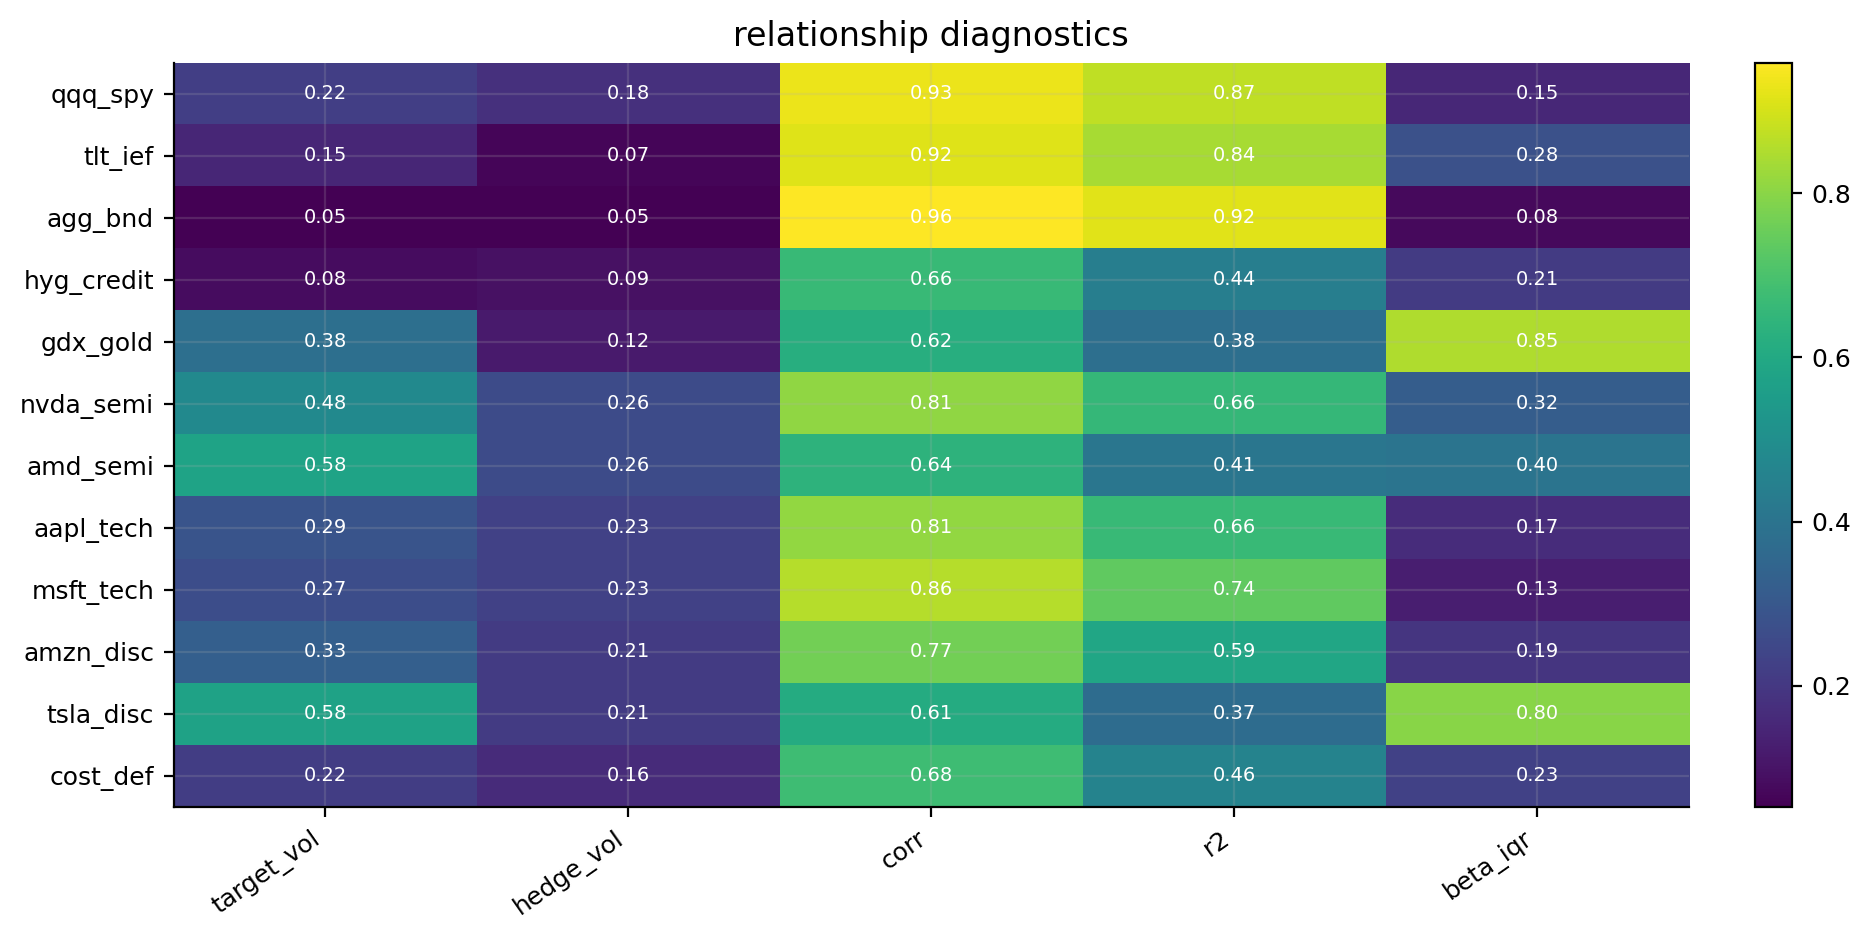

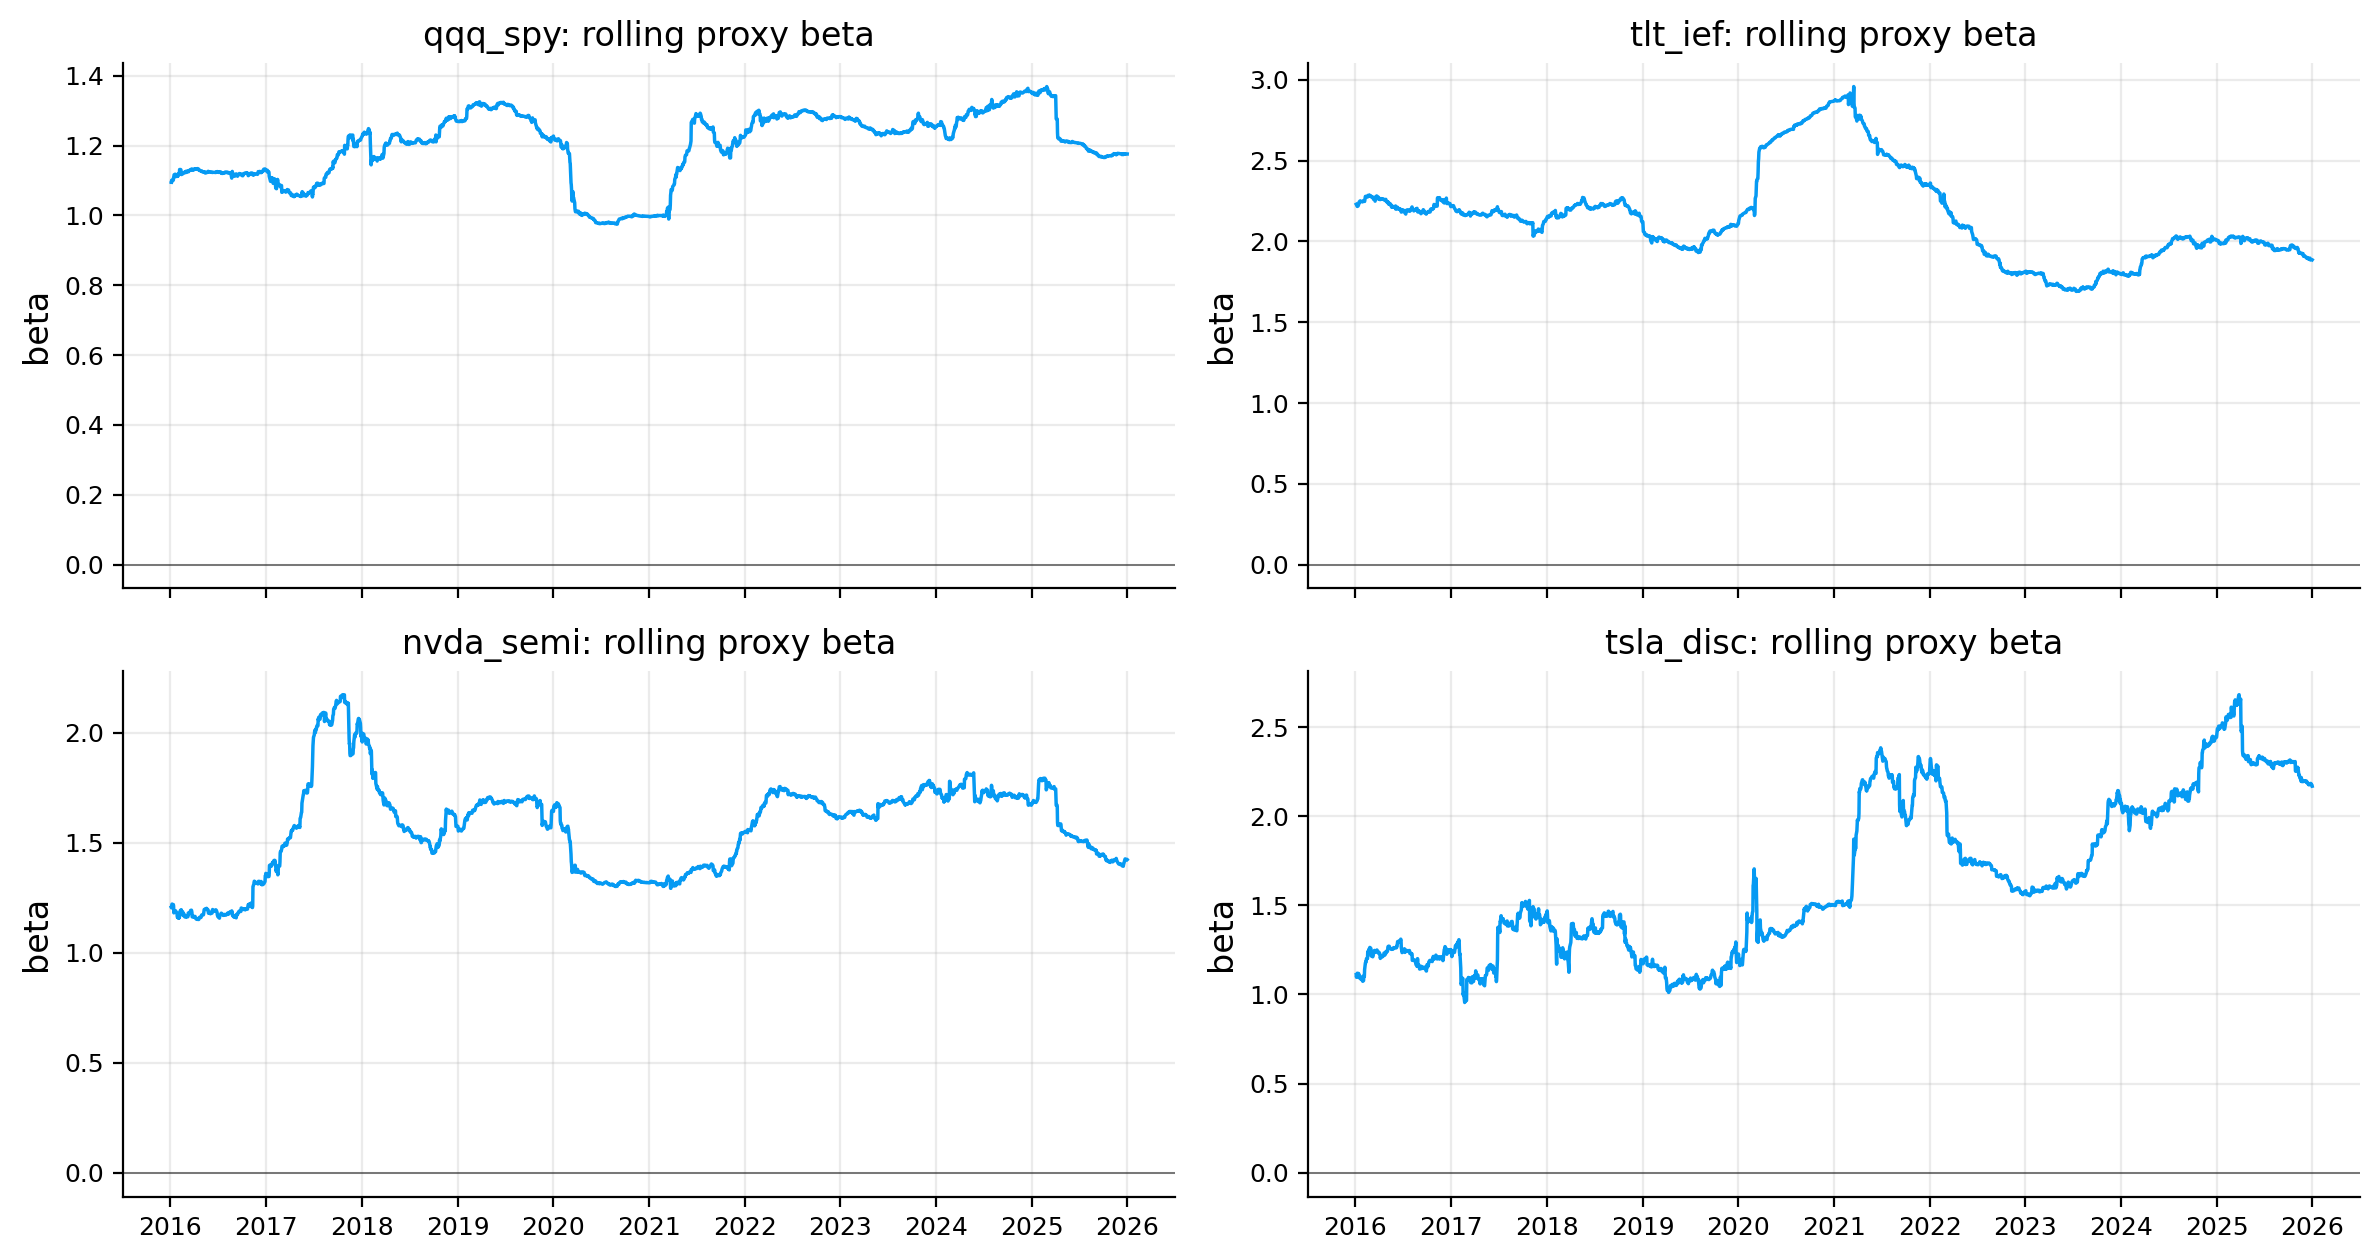

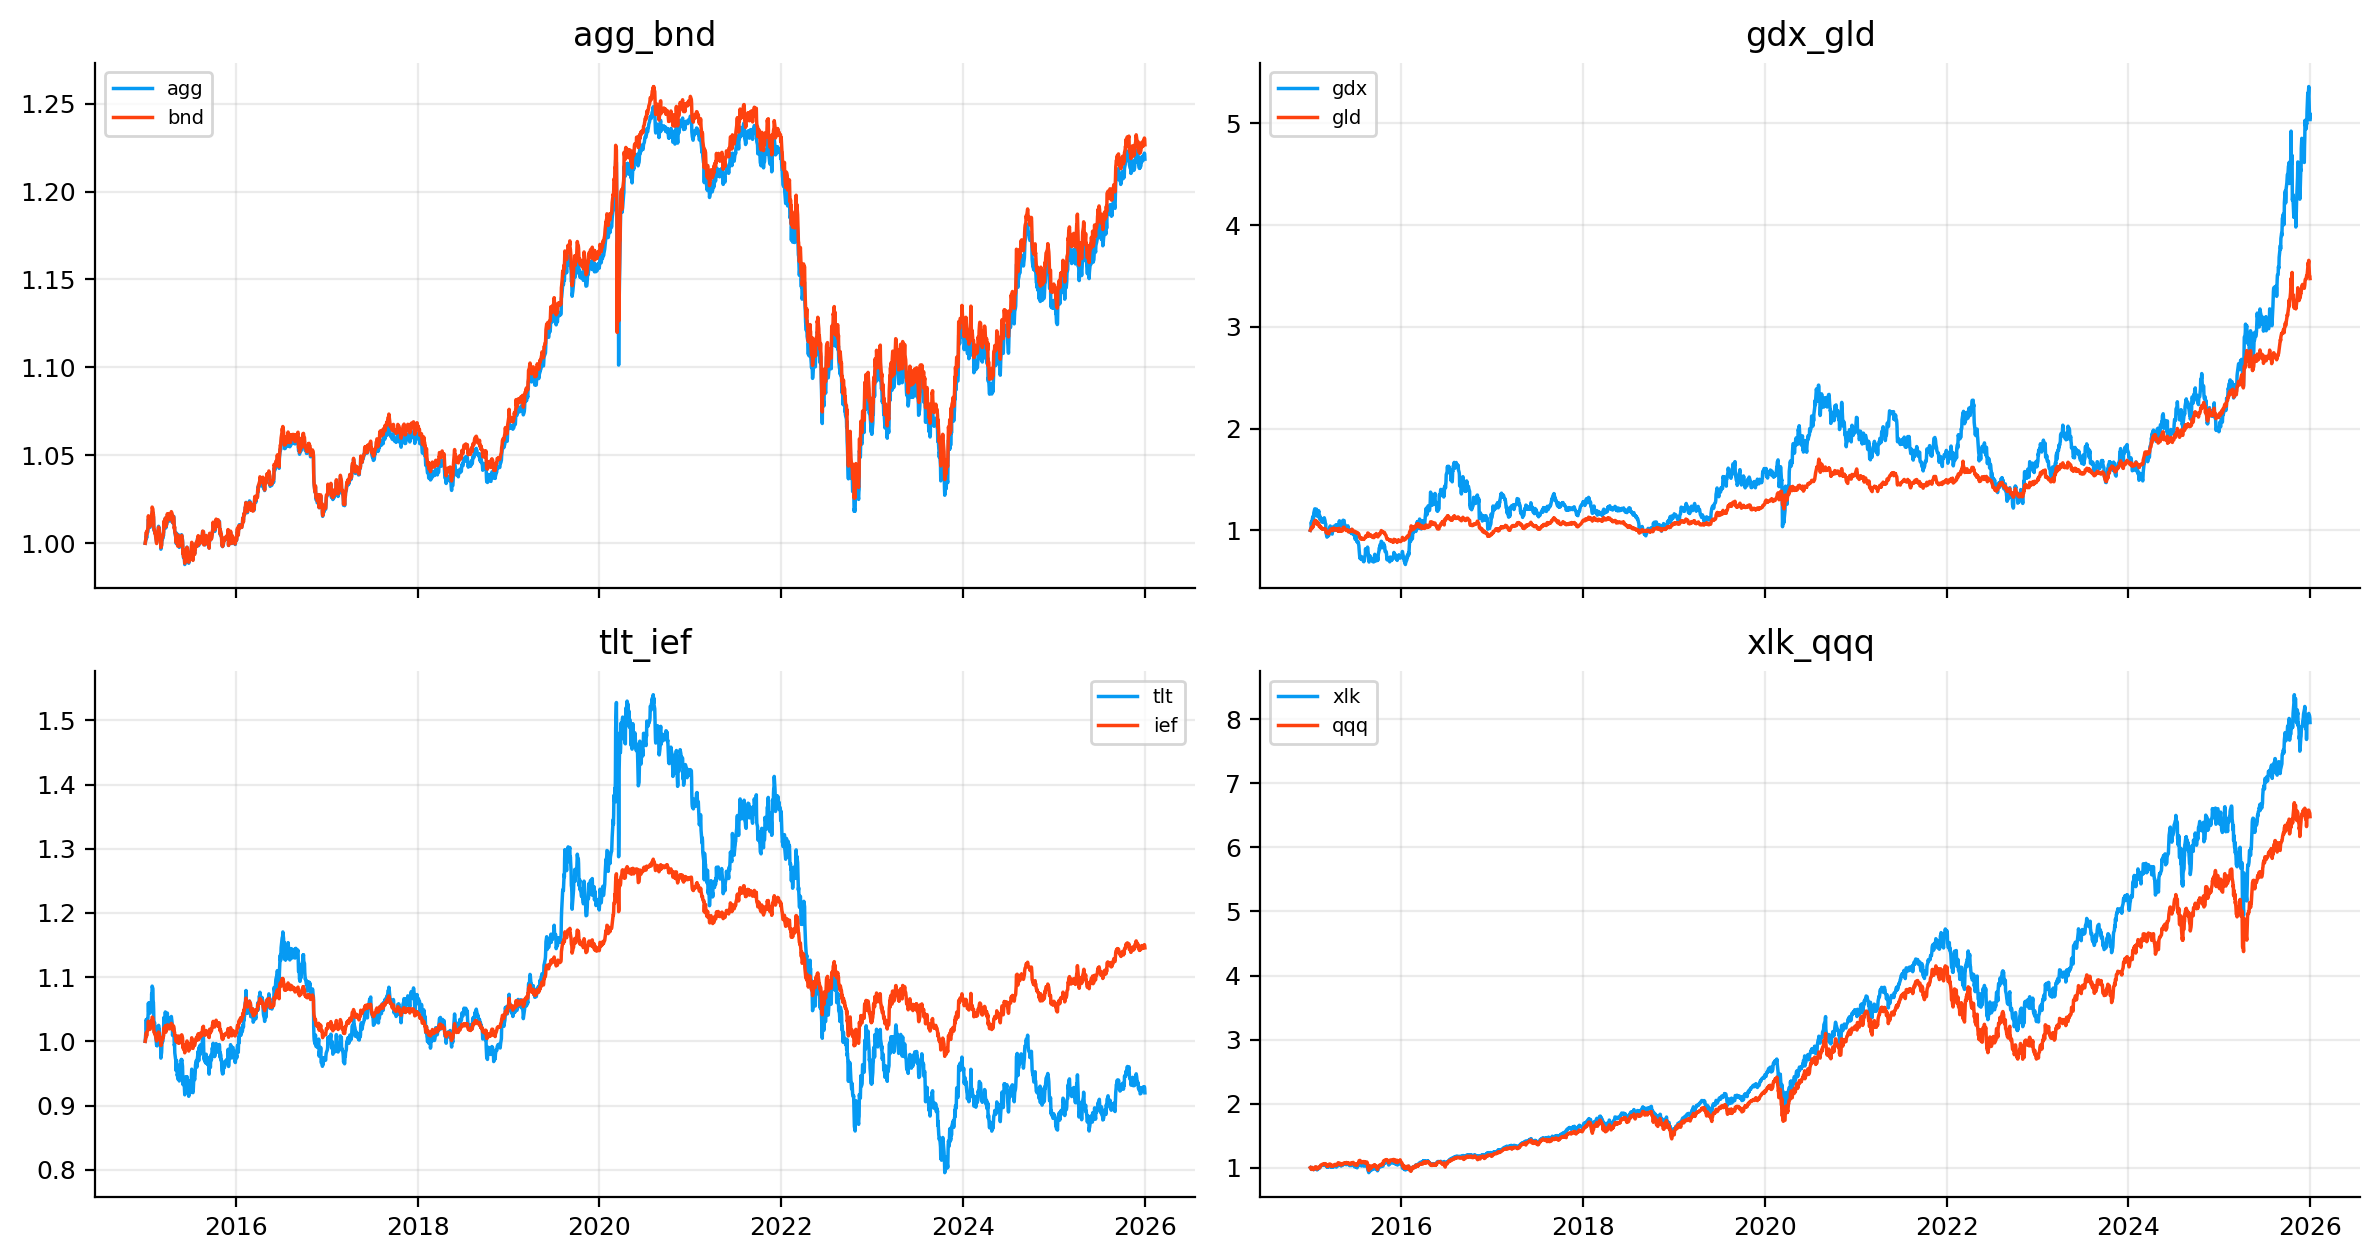

In [7]:
def hedge_proxy_ret(ret, r):
    return ret[r.hedges].mean(axis=1).rename(f"{r.name}_proxy")


def coverage_table(frame, rels):
    rows = []
    for r in rels:
        sub = frame[r.assets]
        valid = sub.dropna(how="any")
        rows.append({"relationship": r.name, "target": r.target, "hedges": ", ".join(r.hedges),
                     "start": valid.index.min() if len(valid) else pd.NaT,
                     "end": valid.index.max() if len(valid) else pd.NaT,
                     "obs": len(valid), "missing_pct": sub.isna().mean().mean(), "included": len(valid) > 0})
    return pd.DataFrame(rows)


def diag_table(ret, rels):
    rows = []
    for r in rels:
        y = ret[r.target]
        proxy = hedge_proxy_ret(ret, r)
        z = pd.concat([y, proxy], axis=1).dropna()
        z.columns = ["target", "proxy"]
        _, _, r2 = capm_ols(z["target"], z["proxy"])
        b = rolling_beta(z["target"], z["proxy"], window=min(win, max(len(z) // 2, 20)))
        rows.append({"relationship": r.name, "target_vol": z["target"].std() * np.sqrt(ann),
                     "hedge_vol": z["proxy"].std() * np.sqrt(ann), "corr": z["target"].corr(z["proxy"]),
                     "r2": r2, "beta_iqr": b.quantile(0.75) - b.quantile(0.25), "obs": len(z)})
    return pd.DataFrame(rows)


tab_cov = coverage_table(px_main, rel_main)
tab_diag = diag_table(ret_m_main, rel_main)
display(tab_cov.round(4))
display(tab_diag.round(4))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
diag_cols = ["target_vol", "hedge_vol", "corr", "r2", "beta_iqr"]
mat = tab_diag.set_index("relationship")[diag_cols]
vals = mat.to_numpy(dtype=float)
im = ax.imshow(vals, aspect="auto", cmap="viridis")
ax.set_xticks(range(mat.shape[1]), mat.columns, rotation=35, ha="right")
ax.set_yticks(range(mat.shape[0]), mat.index)
ax.set_title("relationship diagnostics")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if np.isfinite(vals[i, j]):
            ax.text(j, i, f"{vals[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, name in zip(axes.ravel(), ["qqq_spy", "tlt_ief", "nvda_semi", "tsla_disc"]):
    r = next((x for x in rel_main if x.name == name), None)
    if r is None:
        ax.axis("off")
        continue
    b = rolling_beta(ret_m_main[r.target], hedge_proxy_ret(ret_m_main, r), window=win).dropna()
    ax.plot(b.index, b.values, lw=1.25)
    ax.axhline(0, color="black", lw=0.7, alpha=0.5)
    ax.set_title(f"{name}: rolling proxy beta")
    ax.set_ylabel("beta")
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

price_examples = [("agg_bnd", "agg", "bnd"), ("gdx_gld", "gdx", "gld"),
                  ("tlt_ief", "tlt", "ief"), ("xlk_qqq", "xlk", "qqq")]
price_examples = [(name, a, b) for name, a, b in price_examples if a in px.columns and b in px.columns]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, item in zip(axes.ravel(), price_examples):
    name, a, b = item
    sub = px[[a, b]].dropna()
    if len(sub):
        norm = sub / sub.iloc[0]
        ax.plot(norm.index, norm[a], lw=1.25, label=a, color=colors[0])
        ax.plot(norm.index, norm[b], lw=1.25, label=b, color=colors[1])
    ax.set_title(name)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)
for ax in axes.ravel()[len(price_examples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


From the coverage table we can see that every main relationship has the full sample from **2015-01-02 to 2025-12-31**, with **2766 price observations** and **0% missing values**. So any later difference across models is coming from the estimation method, not from unequal data coverage.

The diagnostic table already separates the easy hedge problems from the hard ones:

- **AGG/BND** has correlation around **0.959** and $R^2$ around **0.920**. This is the cleanest relationship in the main sample. It's almost a replication hedge.
- **QQQ/SPY** has correlation around **0.934** and $R^2$ around **0.872**. SPY explains most Nasdaq movement, but the residual still contains a growth/tech component.
- **TLT/IEF** has correlation around **0.916** and $R^2$ around **0.840**. This is a duration hedge problem. The two ETFs move together, but TLT has much higher duration sensitivity.
- **GDX/GLD** has only moderate correlation around **0.619** and $R^2$ around **0.384**, with a very large beta IQR around **0.850**. Gold miners aren't just leveraged gold. They also contain equity beta, mining margin risk, and company-level stress.
- **TSLA/XLY+QQQ** and **AMD/SMH+QQQ** have low-to-moderate explanatory power relative to their target volatility. Those names have major idiosyncratic components.

The diagnostic heatmap makes this visible: bond pairs are bright in correlation and $R^2$, while GDX and high-volatility stocks stand out with higher target volatility and less stable betas.

### 4.1 Rolling beta and normalized price behavior

The rolling beta plots give a first visual sense of why a static hedge can be too rigid. The rolling beta for **QQQ/SPY** stays mostly around the 1.1 to 1.3 zone, but it still shifts across regimes. During periods when growth stocks dominate, QQQ needs a higher SPY hedge to remove market beta. During stress or rotation periods, the beta compresses.

For **TLT/IEF**, the beta is much higher because TLT has longer duration. If IEF is a medium-duration Treasury ETF and TLT is long duration, then one dollar of IEF doesn't offset one dollar of TLT. The hedge ratio has to scale up with duration exposure.

For **NVDA/SMH+QQQ** and **TSLA/XLY+QQQ**, the rolling paths are less stable. That instability is economically reasonable. These stocks aren't just sector exposures. NVDA has AI, semiconductor, and company-specific earnings repricing. TSLA has consumer discretionary beta, growth beta, rate sensitivity, and company-specific volatility. A hedge ratio can remove broad exposure, but it can't turn these stocks into clean ETF spreads.

The normalized price plots show the same point from a price-level perspective. AGG and BND track very closely. TLT and IEF track directionally but with large divergence because their durations differ. GDX and GLD diverge sharply in some periods, especially when miner margins or equity risk dominate gold itself. XLK and QQQ are close but not identical, since QQQ is a Nasdaq index and XLK is a technology sector ETF.

### 4.2 Residual variance and $R^2$ intuition

The diagnostic $R^2$ is useful because it tells us how much of the target's return variance can be explained by the hedge proxy. In a one-factor regression with intercept:

$$
R^2 = \rho_{yx}^2
$$

So if QQQ and SPY have correlation around $0.934$, then $R^2$ is about:

$$
0.934^2 \approx 0.872
$$

That matches the table. It means about 87% of QQQ's daily return variance is explained by SPY in the full sample. The remaining 13% is the residual growth/technology component.

For a hedge book, the residual variance is:

$$
\sigma^2_{res} = \sigma_y^2(1-R^2)
$$

in the simple one-factor static case. This explains why high-correlation relationships are easier to hedge. If $R^2$ is high, the residual variance has to be much lower than target variance. If $R^2$ is low, even the optimal hedge can only remove part of the target risk.

That's why GDX is hard. Its relationship with GLD and SPY is real, but not dominant. A large part of GDX movement remains outside those hedges.

## 5) Hedge-book mechanics and static OLS

Now we build the actual hedge-book logic. A hedge estimator gives a beta path. The trading book converts that path into returns, turnover, costs, and NAV.

For a target $y_t$ and hedge vector $\mathbf{x}_t$, the gross hedged return is:

$$
r^{gross}_t = y_t - \boldsymbol{\beta}_{t-1}^\top \mathbf{x}_t
$$

The cost-adjusted return is:

$$
r^{net}_t = r^{gross}_t - c_t
$$

where:

$$
c_t = \frac{\text{cost bps}}{10000}\sum_{j=1}^{K}|\beta_{j,t}-\beta_{j,t-1}|
$$

This is important because a dynamic hedge isn't free. If a beta estimator jumps around every week, it can look better before costs and worse after costs. The hedge-book metrics track:

- **volatility reduction**: how much annualized volatility falls relative to the unhedged target,
- **expected shortfall reduction**: how much the left-tail loss improves,
- **maximum drawdown difference**: whether the hedge reduces peak-to-trough pain,
- **beta reduction**: how much residual exposure to the hedge proxy remains,
- **turnover and cost drag**: whether the model is implementable.

Static OLS is the first benchmark. We estimate one fixed beta from the first 504 observations:

$$
\hat{\boldsymbol{\beta}}_{OLS} = (X^\top X)^{-1}X^\top y
$$

Then we hold that hedge ratio through the rest of the sample, with weekly book evaluation. Static OLS is simple and low-turnover, but it assumes the relationship is stable after the training period.

In [8]:
def ols_fit(y, x):
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    y = np.asarray(y, dtype=float).reshape(-1)
    xmat = np.column_stack([np.ones(len(y)), x])
    coef = np.linalg.lstsq(xmat, y, rcond=None)[0]
    return float(coef[0]), np.asarray(coef[1:], dtype=float)


def ols_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    if len(z) < n_train:
        return out
    _, b = ols_fit(z[r.target].iloc[:n_train], z[r.hedges].iloc[:n_train])
    out.loc[z.index[n_train - 1]:, r.hedges] = b
    return out


def rebalance_beta(beta, index):
    idx = pd.DatetimeIndex(index).sort_values()
    daily = beta.reindex(idx.union(beta.index)).sort_index().ffill().reindex(idx)
    dates = pd.Series(idx, index=idx).groupby(pd.Grouper(freq=freq.upper())).last().dropna()
    return daily.loc[pd.DatetimeIndex(dates.values)].dropna(how="all") if len(dates) else pd.DataFrame(columns=beta.columns)


def zero_beta(index, r):
    return pd.DataFrame(0.0, index=pd.DatetimeIndex(index)[:1], columns=r.hedges)


def hedge_book(ret, r, beta, cost_bps=cost_bps):
    panel = ret[r.assets].dropna()
    b = beta.reindex(panel.index.union(beta.index)).sort_index().ffill().reindex(panel.index)
    b = b.shift(1).dropna(how="any")
    panel = panel.reindex(b.index).dropna(how="any")
    b = b.reindex(panel.index)
    gross = panel[r.target] - (b[r.hedges] * panel[r.hedges]).sum(axis=1)
    turnover = b.diff().abs().sum(axis=1)
    if len(turnover):
        turnover.iloc[0] = b.iloc[0].abs().sum()
    cost = turnover * cost_bps / 10000.0
    net = gross - cost
    return {
        "target_return": panel[r.target],
        "gross_return": gross,
        "net_return": net,
        "turnover": turnover,
        "cost": cost,
        "beta": b,
        "gross_values": (1 + gross).cumprod(),
        "net_values": (1 + net).cumprod(),
        "target_values": (1 + panel[r.target]).cumprod(),
    }


class book_result:
    def __init__(self, d):
        self.__dict__.update(d)
        self.net_returns = d["net_return"]
        self.gross_returns = d["gross_return"]



def model_table(bt, rels, ret):
    rows = []
    for r in rels:
        base_name = f"{r.name} | target"
        base = bt[base_name].net_returns
        proxy = hedge_proxy_ret(ret, r)
        zbase = pd.concat([base, proxy], axis=1).dropna()
        _, beta_base, _ = capm_ols(zbase.iloc[:, 0], zbase.iloc[:, 1]) if len(zbase) >= 3 else (np.nan, np.nan, np.nan)
        for name, res in bt.items():
            if not name.startswith(f"{r.name} | ") or name == base_name:
                continue
            model = name.split(" | ", 1)[1]
            z = pd.concat([base.rename("base"), res.net_returns.rename("model")], axis=1).dropna()
            if len(z) < 5:
                continue
            vol_base = z["base"].std() * np.sqrt(ann)
            vol_model = z["model"].std() * np.sqrt(ann)
            es_base = historical_es(z["base"], alpha=0.05)
            es_model = historical_es(z["model"], alpha=0.05)
            zbeta = pd.concat([res.net_returns, proxy], axis=1).dropna()
            _, beta_model, _ = capm_ols(zbeta.iloc[:, 0], zbeta.iloc[:, 1]) if len(zbeta) >= 3 else (np.nan, np.nan, np.nan)
            bpath = res.beta[r.hedges] if hasattr(res, "beta") and not res.beta.empty else pd.DataFrame()
            b_iqr = bpath.quantile(0.75).sub(bpath.quantile(0.25)).mean() if not bpath.empty else np.nan
            b_jump = bpath.diff().abs().mean().mean() if not bpath.empty else np.nan
            cost_s = pd.Series(getattr(res, "cost", pd.Series(dtype=float)), dtype=float)
            rows.append({"relationship": r.name, "model": model,
                         "vol_red": 1 - vol_model / vol_base if vol_base > 1e-12 else np.nan,
                         "es_red": 1 - abs(es_model) / abs(es_base) if abs(es_base) > 1e-12 else np.nan,
                         "maxdd_diff": abs(max_drawdown(z["base"], input_kind="returns")) - abs(max_drawdown(z["model"], input_kind="returns")),
                         "beta_red": 1 - abs(beta_model) / abs(beta_base) if abs(beta_base) > 1e-12 else np.nan,
                         "turnover": res.turnover.mean() if len(res.turnover) else 0.0,
                         "turnover_ann": res.turnover.mean() * ann if len(res.turnover) else 0.0,
                         "cost_drag": max(total_return(res.gross_values) - total_return(res.net_values), 0.0),
                         "cost_drag_ann": cost_s.mean() * ann if len(cost_s) else 0.0,
                         "beta_iqr": b_iqr, "beta_jump": b_jump,
                         "beta_stability": 1 / (1 + b_iqr + 5 * b_jump) if np.isfinite(b_iqr) and np.isfinite(b_jump) else np.nan,
                         "rebalance_count": int((res.turnover.abs() > 1e-12).sum()) if len(res.turnover) else 0})
    return pd.DataFrame(rows)

### 5.1 Reading the hedge metrics

The risk-reduction metrics have specific meanings. Volatility reduction is:

$$
\text{vol\_red} = 1 - \frac{\sigma_{hedged}}{\sigma_{target}}
$$

Expected-shortfall reduction is:

$$
\text{es\_red} = 1 - \frac{|ES_{hedged}|}{|ES_{target}|}
$$

where $ES$ is the average loss inside the left tail. If $ES_{hedged}$ is much smaller in absolute value, the hedge improves tail risk.

The drawdown metric is reported as an improvement in absolute drawdown:

$$
\text{maxdd\_diff} = |MDD_{target}| - |MDD_{hedged}|
$$

Positive values mean the hedge reduced maximum drawdown. Negative values mean the hedged book had a worse drawdown than the original target.

Beta reduction is:

$$
\text{beta\_red} = 1 - \frac{|\beta_{hedged}|}{|\beta_{target}|}
$$

This asks whether the residual book really removed exposure to the hedge proxy. If beta reduction is high but drawdown improvement is bad, the hedge removed the intended factor but introduced or exposed another source of risk.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6417,0.6509,0.1496,0.9547,0.1236,0.0001
1,tlt_ief,0.5837,0.5382,0.1944,0.9163,0.2484,0.0001
2,agg_bnd,0.7153,0.8112,0.1456,0.9857,0.1061,0.0001
3,hyg_credit,0.4197,0.4741,0.0097,0.8018,0.1523,0.0001
4,gdx_gold,0.2050,0.2059,-0.4645,0.3172,0.3950,0.0002
5,nvda_semi,0.4428,0.4700,0.1705,0.8676,0.1256,0.0001
6,amd_semi,0.2853,0.2980,-0.0520,0.9804,0.2119,0.0001
7,aapl_tech,0.3972,0.4234,-0.0960,0.8054,0.2021,0.0001
8,msft_tech,0.4482,0.4510,-0.0930,0.7224,0.1370,0.0001
9,amzn_disc,0.3862,0.4278,0.0531,0.9345,0.1405,0.0001


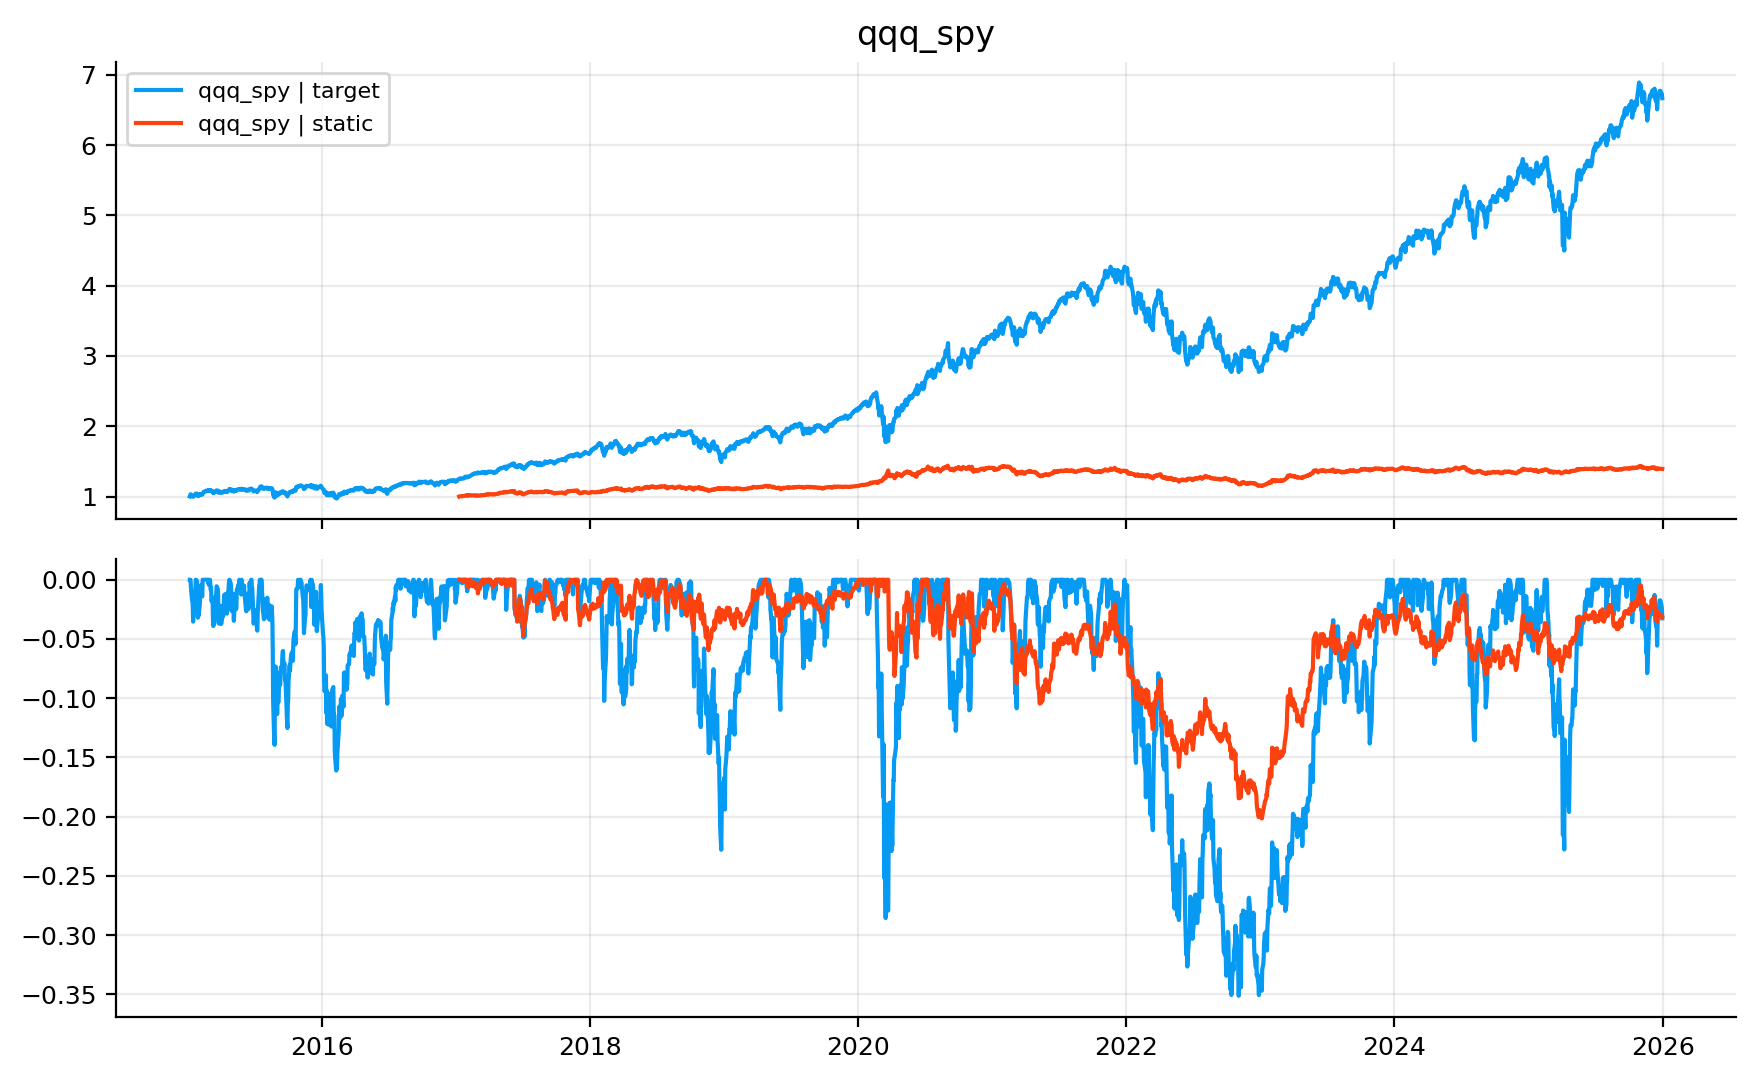

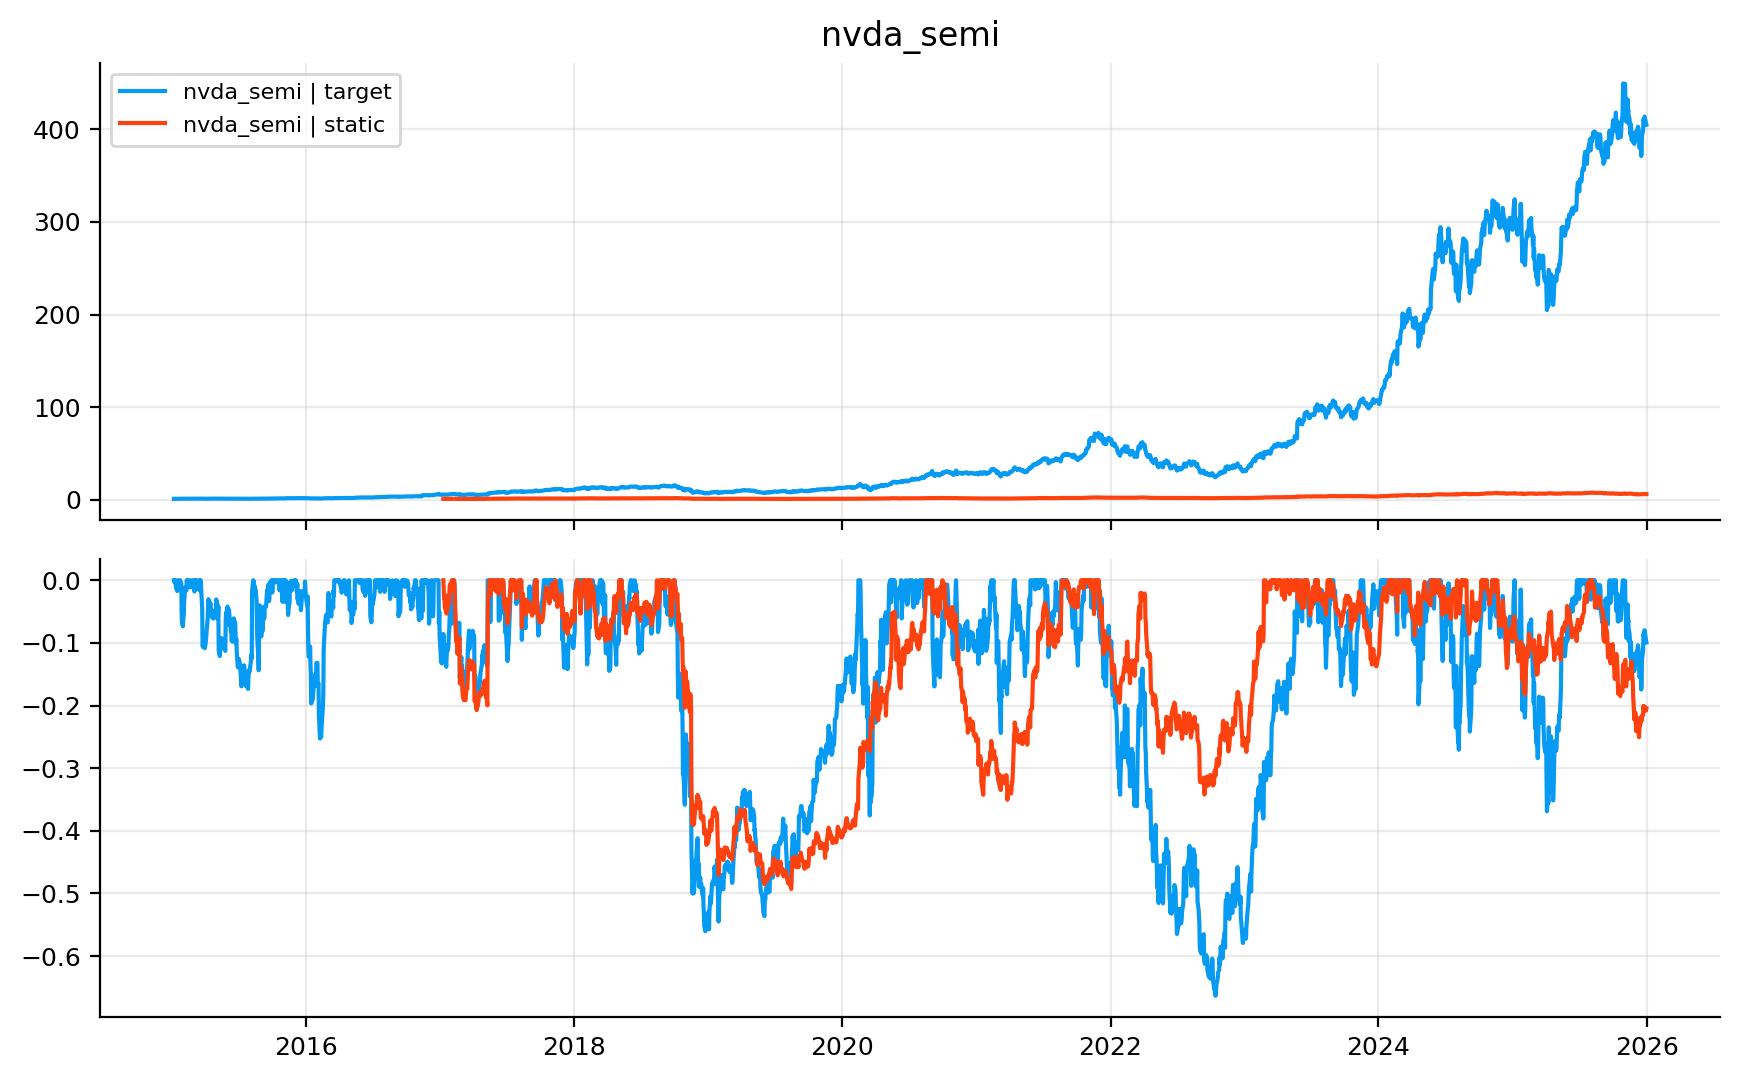

In [9]:
books_target = {f"{r.name} | target": book_result(hedge_book(ret_b_main, r, zero_beta(ret_b_main.index, r))) for r in rel_main}
books_static, blog, beta_daily = {}, {}, {}

for r in rel_main:
    b0 = ols_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index).ffill()
    books_static[f"{r.name} | static"] = book_result(hedge_book(ret_b_main, r, b1))
    blog[f"{r.name} | static"] = {"rel": r.name, "model": "static", "desired": b0, "traded": b1}

bt_static = {**books_target, **books_static}
tab_static = model_table(bt_static, rel_main, ret_m_main)
model_cols = ["relationship", "vol_red", "es_red", "maxdd_diff", "beta_red", "turnover_ann", "cost_drag_ann"]
display(tab_static[model_cols].round(4))

for name in ["qqq_spy", "nvda_semi"]:
    if f"{name} | static" in bt_static:
        fig, axes = plt.subplots(2, 1, figsize=(8.8, 5.5), sharex=True)
        for key in [f"{name} | target", f"{name} | static"]:
            nav = bt_static[key].net_values / bt_static[key].net_values.iloc[0]
            axes[0].plot(nav.index, nav, label=key)
            axes[1].plot(nav.index, drawdown_series(nav, input_kind="nav"), label=key)
        axes[0].set_title(name)
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.25)
        axes[1].grid(True, alpha=0.25)
        plt.tight_layout()
plt.show()

From the static OLS table, the first result is strong: a fixed hedge ratio already removes a lot of risk in many relationships.

The cleanest case is **AGG/BND**, with about **71.5% volatility reduction** and **81.1% expected-shortfall reduction**. That makes sense because AGG and BND are both broad aggregate bond ETFs. A static hedge works because the relationship is structurally stable.

**QQQ/SPY** also works very well, with about **64.2% volatility reduction** and **65.1% ES reduction**. This doesn't mean QQQ becomes risk-free. It means most of QQQ's movement is still broad equity beta, and SPY can remove a large part of it. The remaining residual is the growth/technology tilt.

**TLT/IEF** gives about **58.4% volatility reduction** and a very strong drawdown improvement around **19.4 percentage points**. That's a duration-scaling hedge. IEF doesn't perfectly offset TLT, but it captures much of the Treasury-rate factor.

The weak warning sign is **GDX/GLD**, where static hedging reduces volatility only about **20.5%** and makes the maximum drawdown difference **negative by about 46 percentage points**. This is exactly why GDX is a hard hedge target. Gold miners can sell off with equities even when gold behaves defensively. A static GLD/SPY mix doesn't fully capture that regime-switching behavior.

For the single stocks, static hedging lowers volatility meaningfully, especially NVDA, AAPL, MSFT, and AMZN. But drawdown improvement isn't universal. AMD, AAPL, and MSFT show negative max-drawdown differences under static hedging, which means the hedge reduced day-to-day volatility but didn't necessarily protect the worst path. This is a useful distinction: lower variance doesn't always mean better drawdown control.

The NAV and drawdown plots for **QQQ/SPY** and **NVDA/SMH+QQQ** help explain the difference between hedging and investing.

For QQQ/SPY, the static hedged book is much flatter than the target. That's exactly the point. We aren't trying to beat QQQ with the hedge book. We're trying to strip away the SPY beta and isolate the relative return of QQQ over broad market exposure. The drawdown panel shows a much smaller drawdown profile than unhedged QQQ, especially around 2020 and 2022.

For NVDA, the target NAV explodes after 2023 because NVDA had a huge idiosyncratic and AI-related rally. A hedged book removes some semiconductor and Nasdaq beta, but it also removes part of the exposure that helped NVDA compound. This is a common practical tradeoff:

> A hedge that removes systematic downside also removes systematic upside. The residual book is cleaner, but it won't behave like the original target asset.

So the correct evaluation depends on the goal. If the goal is pure exposure to NVDA, hedging looks like giving up upside. If the goal is isolating NVDA-specific alpha after sector and growth exposure, hedging is the right tool.

## 6) Rolling OLS hedge ratios

Static OLS assumes one relationship for the whole out-of-sample period. Rolling OLS relaxes that assumption. At each date $t$, we estimate beta from the previous 252 trading days:

$$
\hat{\boldsymbol{\beta}}_t = \arg\min_{\boldsymbol{\beta}}\sum_{s=t-L+1}^{t}\left(y_s - \alpha_t - \mathbf{x}_s^\top\boldsymbol{\beta}_t\right)^2
$$

with $L=252$. This lets the hedge ratio adapt to regime changes.

Rolling OLS is useful when the true relationship drifts. But it has two statistical weaknesses:

1. **Sampling noise.** A 252-day window can be noisy, especially with multiple hedges.
2. **Window cliffs.** When one old observation drops out and one new observation enters, the beta can jump even if the economic relation hasn't changed much.

That's why we apply the no-trade band after rebalancing:

$$
\beta^{trade}_t =
\begin{cases}
\beta^{trade}_{t-1}, & |\beta^{desired}_t - \beta^{trade}_{t-1}| \le b \\
\beta^{desired}_t, & |\beta^{desired}_t - \beta^{trade}_{t-1}| > b
\end{cases}
$$

The band turns a noisy desired beta into a tradable beta path.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6488,0.6592,0.1628,0.9773,0.2895,0.0001
1,tlt_ief,0.6078,0.5837,0.2272,0.9963,0.6379,0.0003
2,agg_bnd,0.7013,0.8079,0.1379,0.9974,0.1774,0.0001
3,hyg_credit,0.4942,0.5236,0.0720,0.9729,0.8388,0.0004
4,gdx_gold,0.3674,0.3913,-0.2852,0.9591,1.4500,0.0007
5,nvda_semi,0.4610,0.4825,0.1683,0.9792,2.2263,0.0011
6,amd_semi,0.2941,0.3182,-0.0136,0.9933,3.3270,0.0017
7,aapl_tech,0.4416,0.4681,0.0333,0.9964,3.4614,0.0017
8,msft_tech,0.5259,0.5430,0.1728,0.9811,2.1224,0.0011
9,amzn_disc,0.4059,0.4538,0.1401,0.9926,1.8225,0.0009


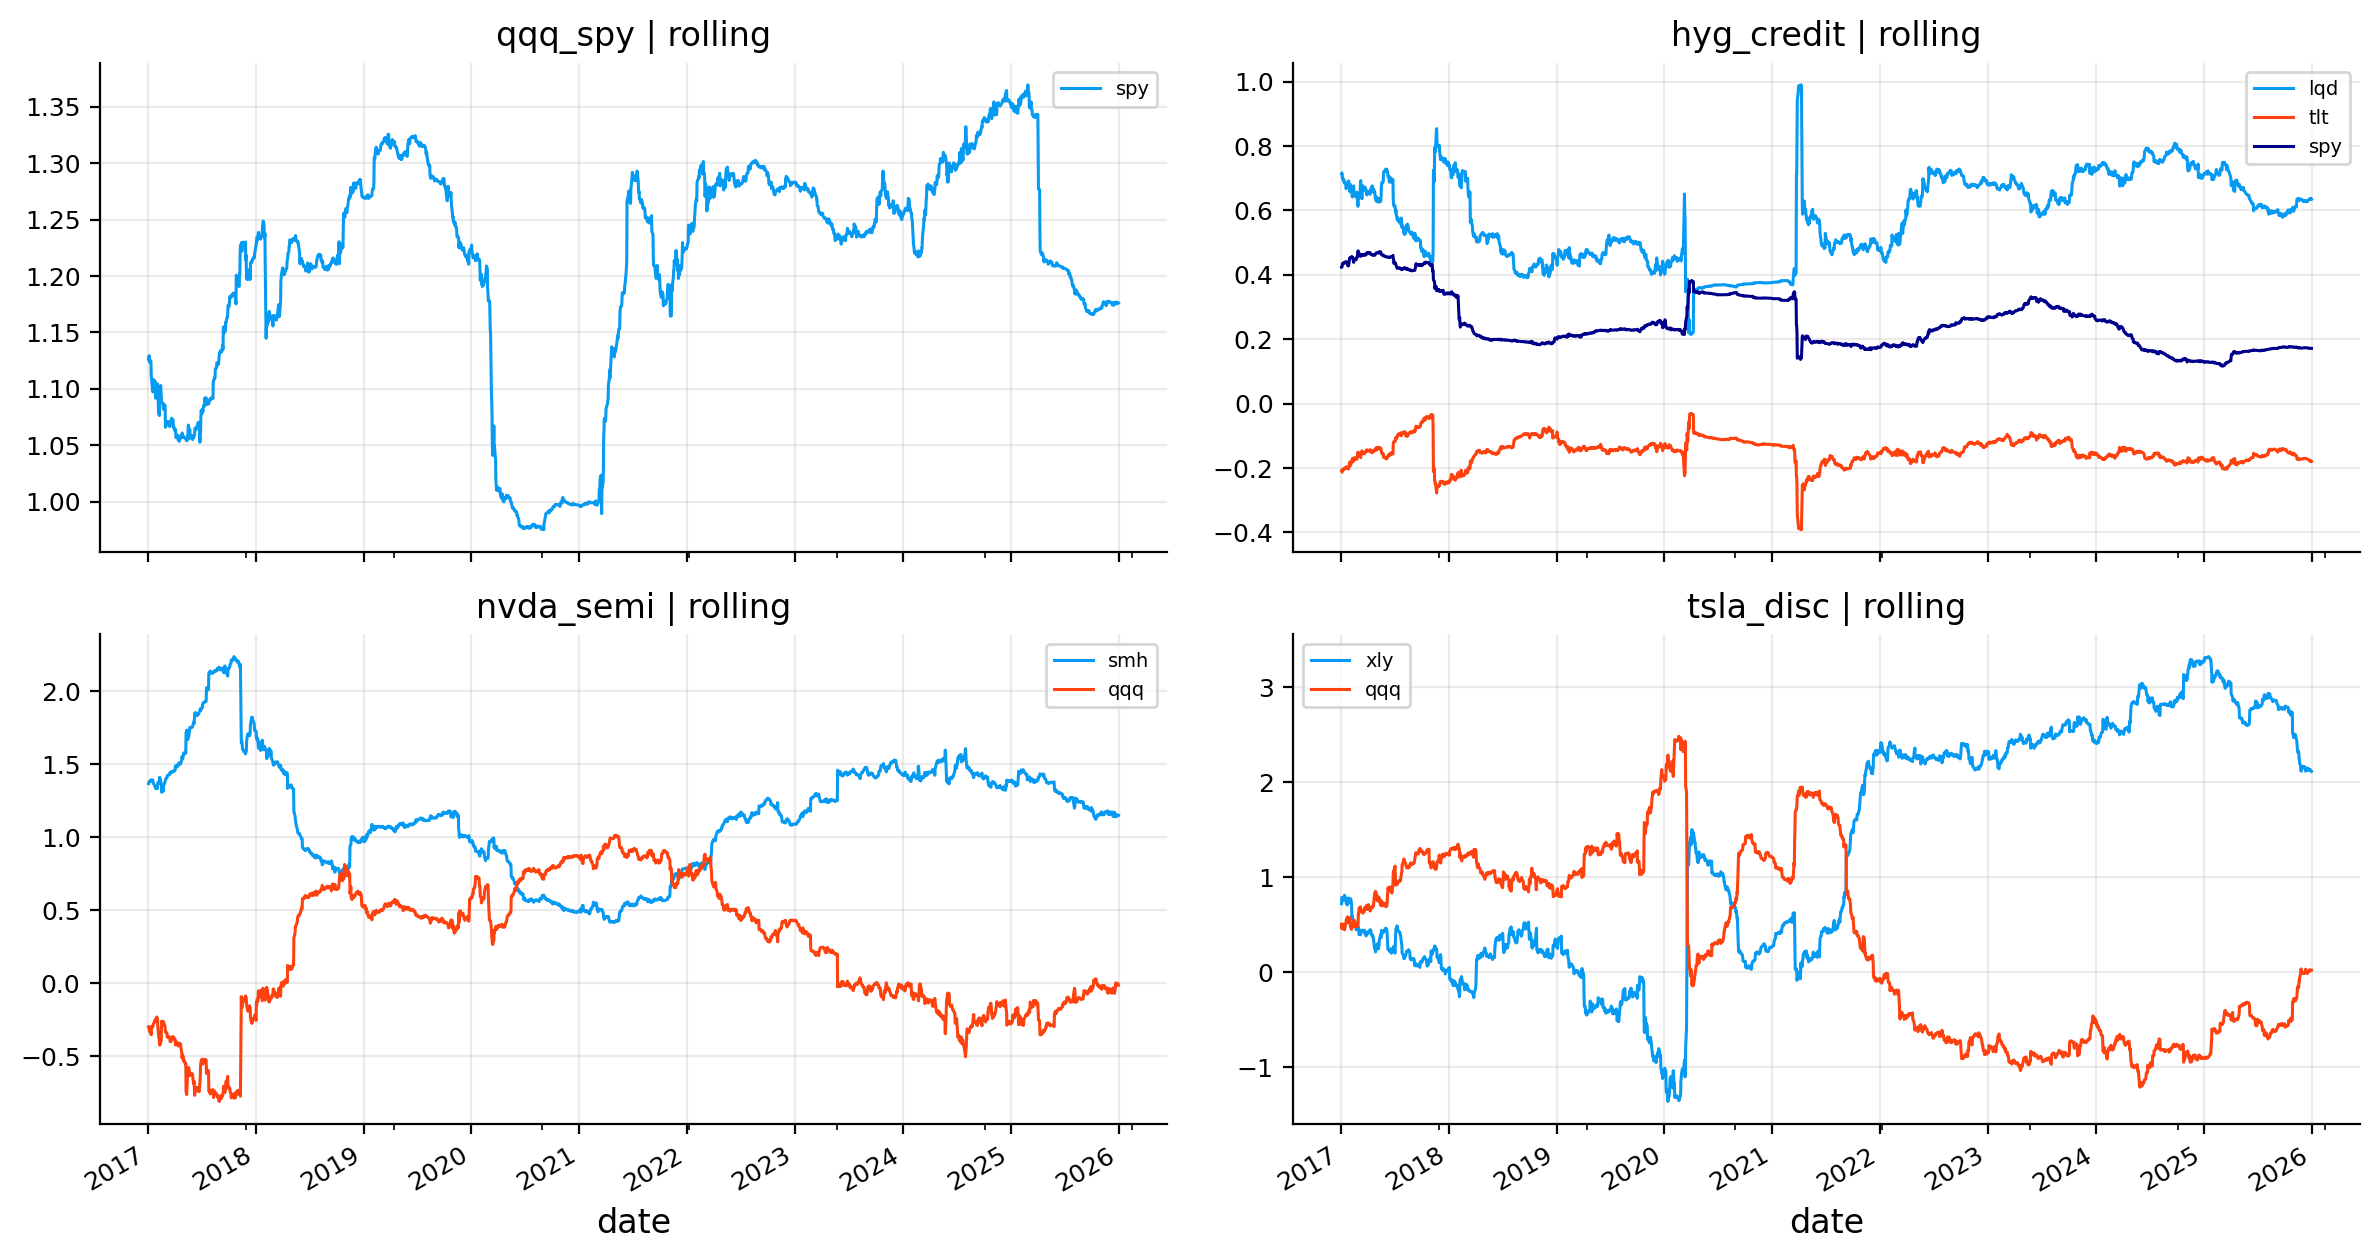

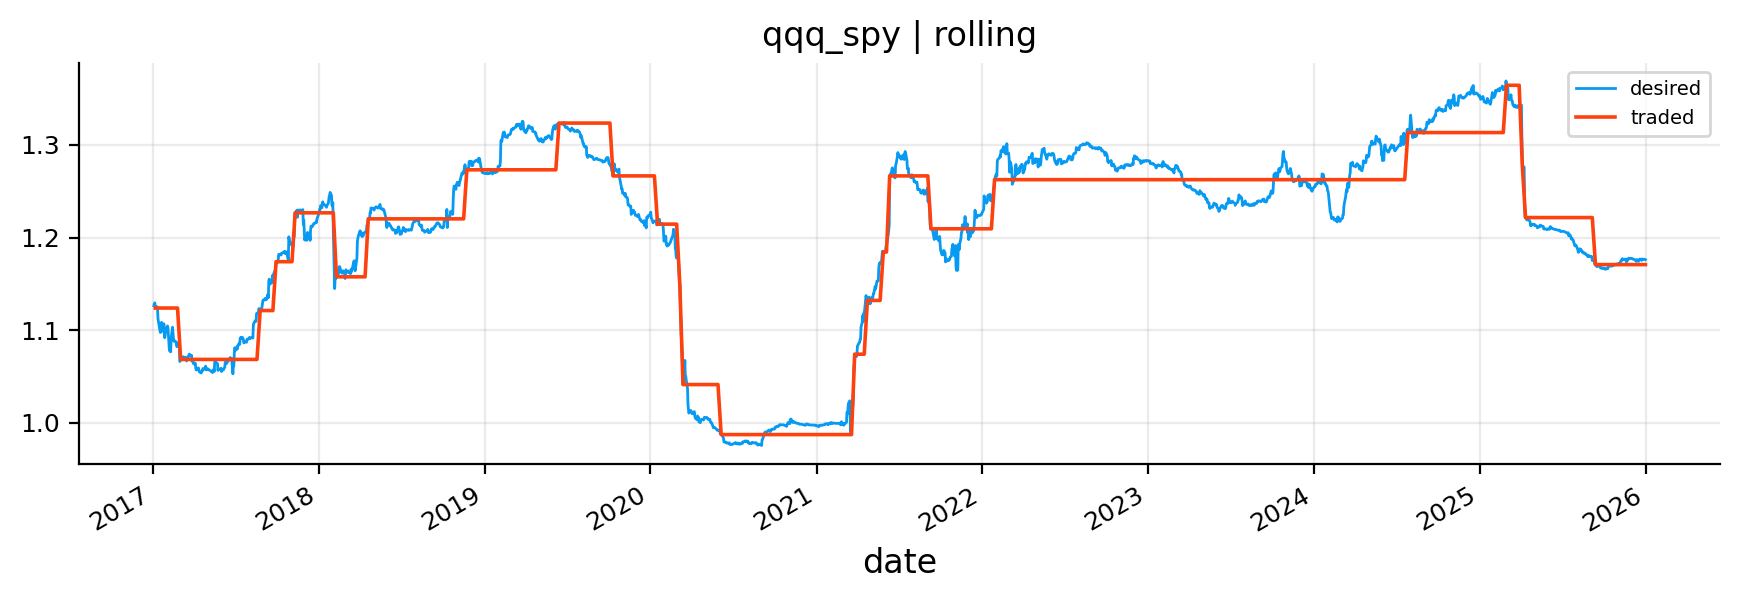

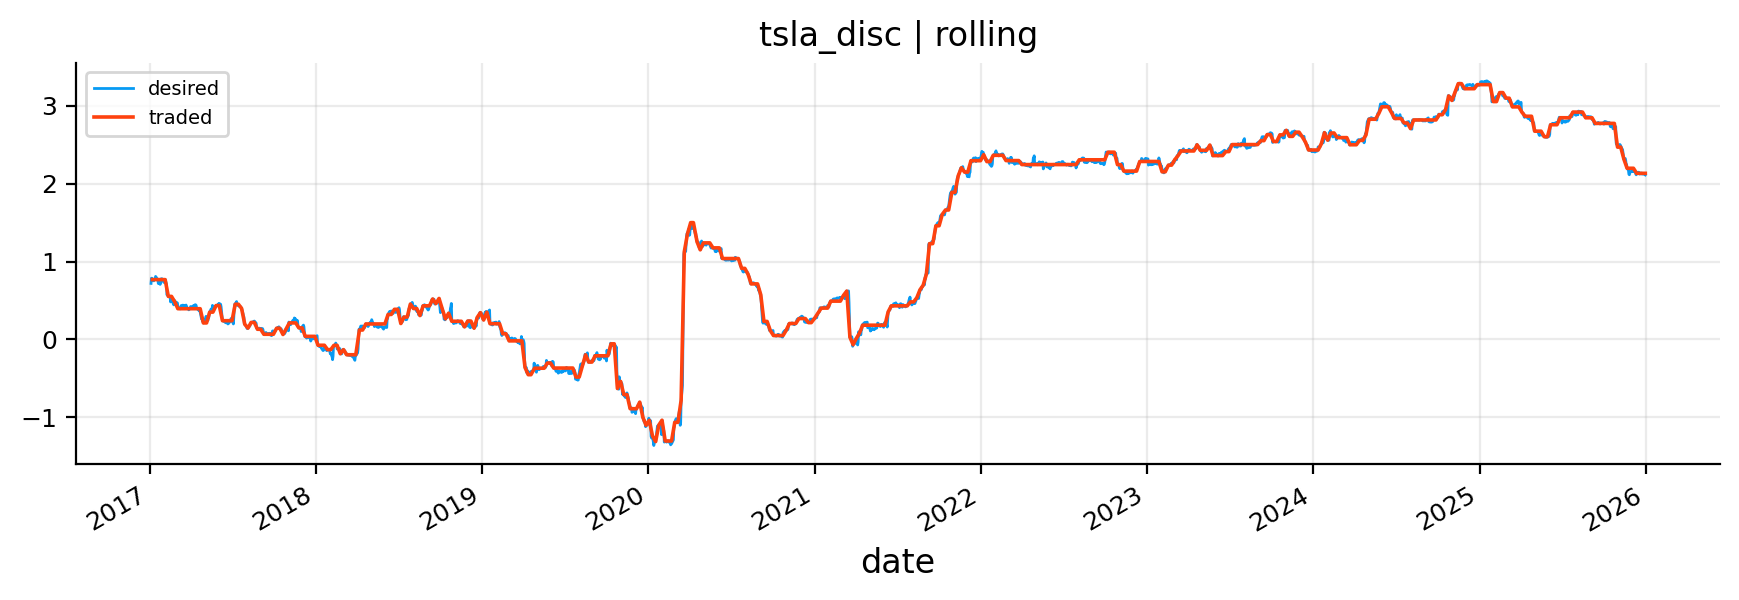

In [10]:
def roll_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    for i in range(max(win, n_train) - 1, len(z)):
        sample = z.iloc[i - win + 1:i + 1]
        _, b = ols_fit(sample[r.target], sample[r.hedges])
        out.loc[z.index[i], r.hedges] = b
    return out


def band_beta(beta, band=band):
    out = pd.DataFrame(np.nan, index=beta.index, columns=beta.columns)
    prev = pd.Series(np.nan, index=beta.columns)
    for dt, row in beta.iterrows():
        if row.notna().sum() == 0:
            out.loc[dt] = prev
            continue
        if prev.notna().sum() == 0:
            prev = row.astype(float)
        else:
            upd = (row - prev).abs() > band
            prev.loc[upd & row.notna()] = row.loc[upd & row.notna()]
        out.loc[dt] = prev
    return out


books_roll = {}
for r in rel_main:
    b0 = roll_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index)
    b2 = band_beta(b1, band=band)
    beta_daily[(r.name, "rolling")] = b0
    books_roll[f"{r.name} | rolling"] = book_result(hedge_book(ret_b_main, r, b2))
    blog[f"{r.name} | rolling"] = {"rel": r.name, "model": "rolling", "desired": b0, "traded": b2}

bt_roll = {**books_target, **books_roll}
tab_roll = model_table(bt_roll, rel_main, ret_m_main)
display(tab_roll[model_cols].round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, name in zip(axes.ravel(), ["qqq_spy", "hyg_credit", "nvda_semi", "tsla_disc"]):
    key = f"{name} | rolling"
    if key in blog:
        blog[key]["desired"].dropna(how="all").plot(ax=ax, lw=1.1)
        ax.set_title(key)
        ax.grid(True, alpha=0.25)
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

for key in ["qqq_spy | rolling", "tsla_disc | rolling"]:
    if key in blog:
        h = blog[key]["desired"].columns[0]
        fig, ax = plt.subplots(figsize=(8.8, 3.1))
        blog[key]["desired"][h].dropna().plot(ax=ax, label="desired", lw=1.0)
        blog[key]["traded"][h].dropna().plot(ax=ax, label="traded", lw=1.3)
        ax.set_title(key)
        ax.legend()
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
plt.show()

Rolling OLS improves many risk metrics relative to static OLS, but it also raises turnover.

The strongest improvements appear where the relationship genuinely changes through time. **HYG credit** improves from about **42.0%** to **49.4% volatility reduction**, and ES reduction rises from **47.4%** to **52.4%**. That makes sense because HYG's exposure to LQD, TLT, and SPY changes across credit regimes. In calm markets, HYG behaves more like carry and equity beta. In stress, it becomes more credit-loss sensitive.

**GDX/gold** also improves from **20.5%** to **36.7% volatility reduction**, although drawdown is still bad. Dynamic beta helps, but GDX remains a difficult spread because gold miners have nonlinear exposure to gold, rates, equity stress, and operational leverage.

The tradeoff appears in turnover. For stock relationships, rolling OLS can become expensive in trading terms. **TSLA/XLY+QQQ** reaches annualized turnover above **5.19**, and **AAPL** and **AMD** are also above **3**. Even with only 5 bps cost, this starts to matter. With higher real-world costs or less liquid implementation, rolling OLS could be too active.

The rolling beta plots show why. For QQQ/SPY, the desired beta is fairly smooth, and the traded beta only updates occasionally. For TSLA, the desired beta path shifts much more aggressively. The no-trade band helps, but it can't fully remove the instability when the relationship itself is unstable.

## 7) Ridge regression for hedge ratios

Ridge regression is the next improvement. It doesn't make beta time-varying by itself; in this project we still estimate it on rolling windows. The difference is that ridge penalizes large and unstable coefficients.

The ridge objective is:

$$
\hat{\boldsymbol{\beta}}_{ridge,t} = \arg\min_{\boldsymbol{\beta}} \left[\sum_{s=t-L+1}^{t}\left(y_s - \alpha_t - \mathbf{x}_s^\top\boldsymbol{\beta}\right)^2 + \alpha \sum_{j=1}^{K}\beta_j^2 \right]
$$

For standardized data, the closed-form solution is:

$$
\hat{\boldsymbol{\beta}}_{ridge} = (X_z^\top X_z + \alpha I)^{-1}X_z^\top y_z
$$

Then we convert the standardized coefficients back to return units:

$$
\hat{\beta}_{j} = \hat{\beta}^{(z)}_{j}\frac{\sigma_y}{\sigma_{x_j}}
$$

Ridge is especially useful in multi-hedge relationships where hedge assets are correlated with each other. For example, SMH and QQQ both contain growth/technology exposure. XLY and QQQ both contain mega-cap growth components. LQD, TLT, and SPY can all explain parts of HYG during different regimes. In those settings, pure OLS can assign extreme coefficients because it tries to separate correlated explanatory variables too aggressively.

Ridge shrinks the solution toward smaller coefficients. It accepts a little bias in exchange for lower variance and better stability.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6491,0.6586,0.1652,0.9835,0.2597,0.0001
1,tlt_ief,0.6066,0.5834,0.2291,0.9657,0.6048,0.0003
2,agg_bnd,0.6910,0.7960,0.1365,0.9694,0.1652,0.0001
3,hyg_credit,0.4870,0.5163,0.0798,0.9339,0.6489,0.0003
4,gdx_gold,0.3689,0.3923,-0.2580,0.9972,1.3368,0.0007
5,nvda_semi,0.4613,0.4859,0.1700,0.9976,1.5870,0.0008
6,amd_semi,0.2955,0.3219,0.0050,0.9871,2.4303,0.0012
7,aapl_tech,0.4397,0.4676,0.0575,0.9754,1.1579,0.0006
8,msft_tech,0.5268,0.5473,0.1770,0.9921,0.6577,0.0003
9,amzn_disc,0.4048,0.4525,0.1300,0.9723,1.3917,0.0007


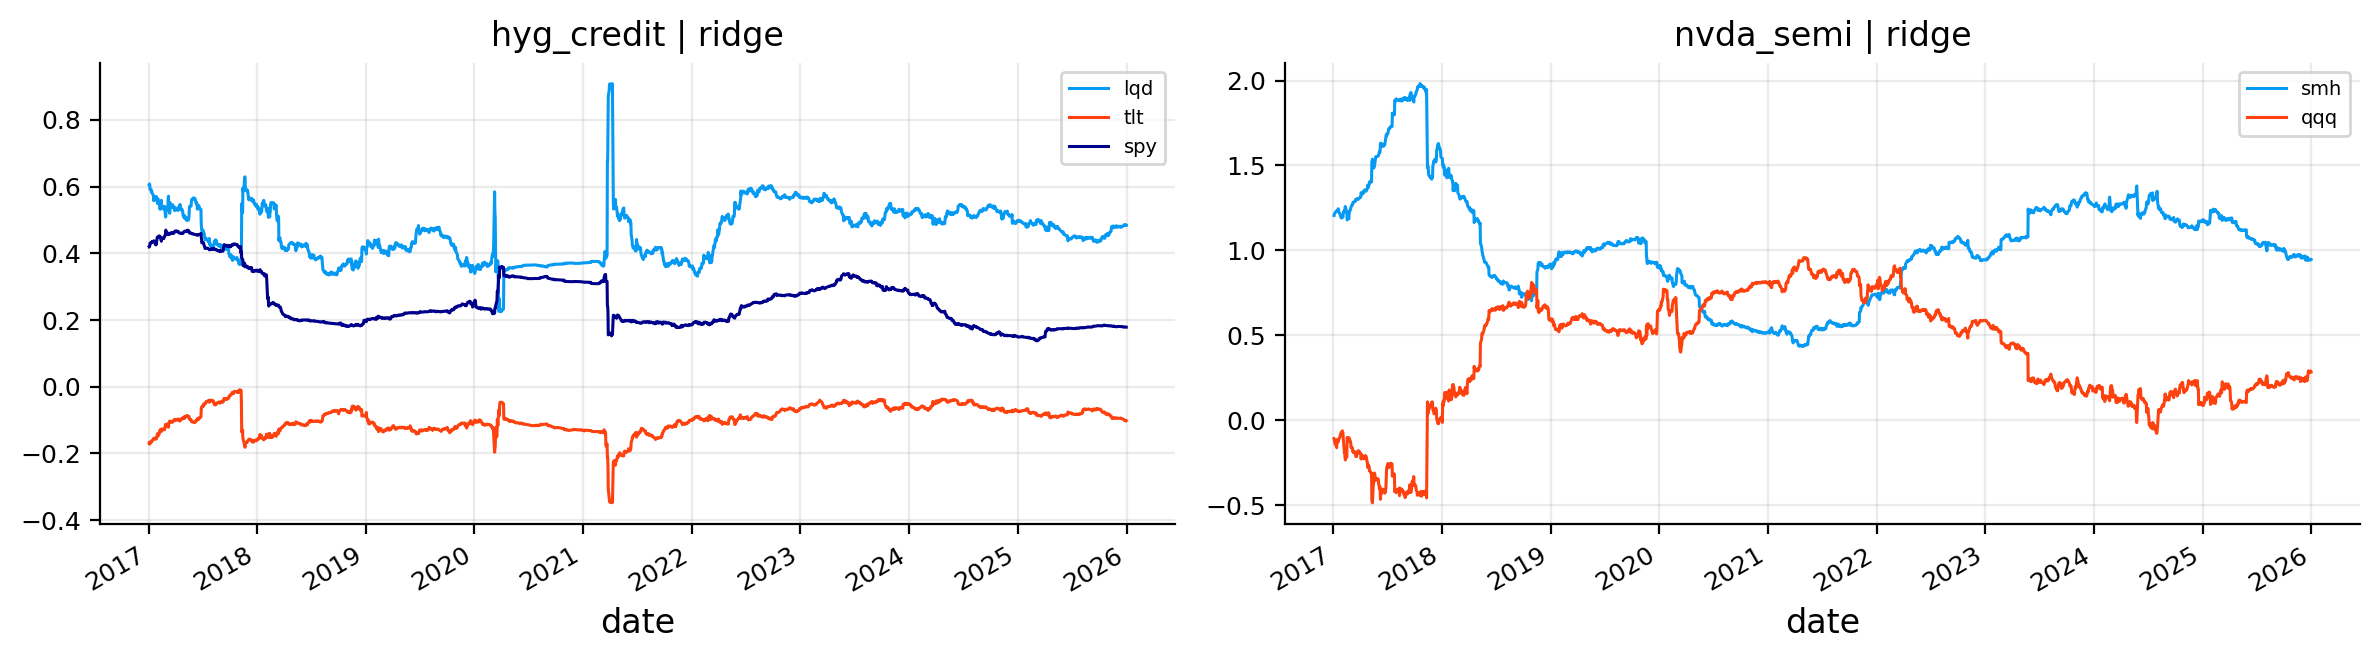

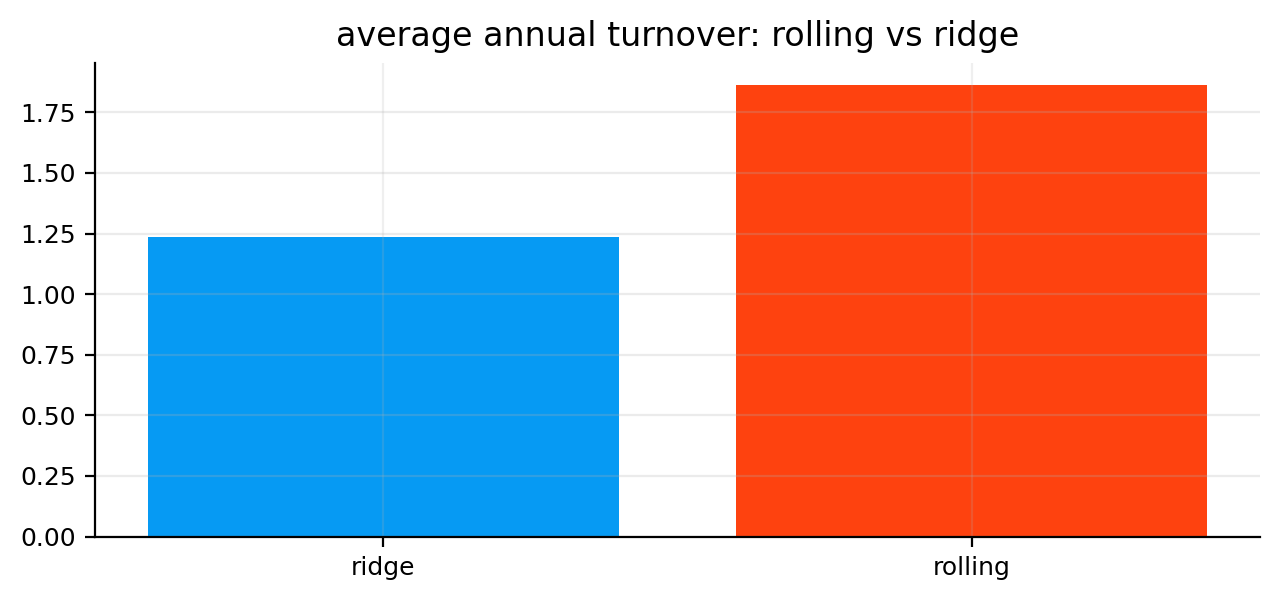

In [11]:
def ridge_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    for i in range(max(win, n_train) - 1, len(z)):
        sample = z.iloc[i - win + 1:i + 1]
        x = sample[r.hedges].to_numpy(float)
        y = sample[r.target].to_numpy(float)
        xm = x.mean(axis=0, keepdims=True)
        ym = y.mean()
        xs = np.where(x.std(axis=0, ddof=1) > 1e-12, x.std(axis=0, ddof=1), 1.0)
        ys = y.std(ddof=1)
        if ys <= 1e-12 or not np.isfinite(ys):
            continue
        xz = (x - xm) / xs
        yz = (y - ym) / ys
        b_std = np.linalg.pinv(xz.T @ xz + alpha * np.eye(xz.shape[1])) @ (xz.T @ yz)
        out.loc[z.index[i], r.hedges] = b_std * ys / xs
    return out


books_ridge = {}
for r in rel_main:
    b0 = ridge_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index)
    b2 = band_beta(b1, band=band)
    beta_daily[(r.name, "ridge")] = b0
    books_ridge[f"{r.name} | ridge"] = book_result(hedge_book(ret_b_main, r, b2))
    blog[f"{r.name} | ridge"] = {"rel": r.name, "model": "ridge", "desired": b0, "traded": b2}

bt_ridge = {**books_target, **books_ridge}
tab_ridge = model_table(bt_ridge, rel_main, ret_m_main)
display(tab_ridge[model_cols].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for ax, name in zip(axes, ["hyg_credit", "nvda_semi"]):
    key = f"{name} | ridge"
    blog[key]["desired"].dropna(how="all").plot(ax=ax, lw=1.1)
    ax.set_title(key)
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

turn_bar = pd.concat([tab_roll.assign(model="rolling"), tab_ridge.assign(model="ridge")]).groupby("model")["turnover_ann"].mean()
fig, ax = plt.subplots(figsize=(6.5, 3.1))
ax.bar(turn_bar.index, turn_bar.values, color=colors[:len(turn_bar)])
ax.set_title("average annual turnover: rolling vs ridge")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

The ridge results are close to rolling OLS on volatility and ES reduction, but turnover is much lower.

This is visible in the comparison bar: average annual turnover falls from about **1.86** for rolling OLS at the 5% band to about **1.24** for ridge. The difference is more important than it looks. The risk reduction is nearly the same, but the ridge path trades less.

A few relationship-level details stand out:

- **QQQ/SPY** gets about **64.9% volatility reduction**, almost identical to rolling OLS, with slightly lower turnover.
- **TLT/IEF** keeps the strong hedge quality, with around **60.7% volatility reduction** and the best drawdown improvement in that block.
- **GDX/gold** improves a lot relative to static OLS, but the drawdown problem remains. Ridge can't remove economic model risk. It only stabilizes coefficients.
- **NVDA/SMH+QQQ** and **MSFT/XLK+QQQ** are strong examples where ridge keeps high risk reduction while controlling turnover relative to rolling OLS.

This is a useful practical lesson. The best hedge estimator isn't always the most flexible one. A slightly biased estimator can be better if it avoids unstable coefficient paths.

### 7.1 Bias-variance tradeoff in hedge estimation

The difference between rolling OLS and ridge is a classic bias-variance tradeoff.

Rolling OLS is unbiased under the usual regression assumptions, but it can have high variance when hedge variables overlap. Ridge adds shrinkage, so the coefficients are biased toward zero, but the estimator becomes more stable:

$$
\text{MSE}(\hat{\beta}) = \text{Bias}(\hat{\beta})^2 + \text{Var}(\hat{\beta})
$$

A hedge ratio is a trading input, so lower estimator variance can be more valuable than zero bias. A slightly biased hedge that trades smoothly can be better than a theoretically unbiased hedge that jumps around and creates cost.

This is especially true in multi-hedge single-stock models. If SMH and QQQ both explain NVDA, OLS may fight over which hedge gets credit. Ridge softens that fight. It doesn't remove the economic overlap, but it prevents the regression from translating that overlap into extreme coefficient changes.

## 8) Kalman filter hedge ratios

The Kalman filter is the most important econometric model in this project. Static OLS says the hedge ratio is one number. Rolling OLS says the hedge ratio can change, but only by re-estimating a regression on a fixed window. The Kalman filter uses a different idea: the hedge ratio is a **hidden state** that moves through time and is only observed indirectly through returns.

That language sounds abstract, but the finance idea is simple. The true beta between two assets is never directly visible. We only see daily target returns and hedge returns. From those observations, we infer the beta. When the relationship changes slowly, we want beta to drift. When today's return is just noise, we don't want beta to overreact.

So the Kalman filter is built for exactly this problem:

- it keeps a current belief about the hedge ratio,
- it predicts what today's target return should be given that belief,
- it measures the surprise between the predicted and realized target return,
- it updates the hedge ratio only as much as the surprise deserves.

This makes it more structured than rolling OLS. Rolling OLS has a hard memory cutoff. The Kalman filter has a soft memory: old information fades because uncertainty accumulates, but it isn't suddenly dropped from the model.

### 8.1 The state-space model

The Kalman filter starts by writing the hedge problem as a **state-space model**. There are two equations.

The first equation connects the hidden hedge ratio to the observed target return. This is the **observation equation**:

$$
y_t = \alpha_t + \mathbf{x}_t^\top\boldsymbol{\beta}_t + \varepsilon_t
$$

where:

- $y_t$ is the target return, for example NVDA's daily return,
- $\mathbf{x}_t$ is the vector of hedge returns, for example SMH and QQQ returns,
- $\boldsymbol{\beta}_t$ is the vector of hedge ratios at time $t$,
- $\alpha_t$ is the time-varying intercept,
- $\varepsilon_t$ is the return shock the hedge basket didn't explain.

We assume the unexplained return shock is Gaussian noise:

$$
\varepsilon_t \sim \mathcal{N}(0, R)
$$

The scalar $R$ is **observation noise**. If $R$ is large, daily returns are very noisy relative to the regression relationship. In that case, one bad prediction doesn't prove beta changed. If $R$ is small, a forecast error is more informative, so beta can update more.

The second equation describes how the hidden state moves. We collect the intercept and all hedge ratios into one vector:

$$
\boldsymbol{\theta}_t = \begin{bmatrix} \alpha_t & \beta_{1,t} & \cdots & \beta_{K,t} \end{bmatrix}^\top
$$

Then we let it follow a random walk:

$$
\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} + \boldsymbol{\eta}_t
$$

with:

$$
\boldsymbol{\eta}_t \sim \mathcal{N}(0, Q)
$$

The matrix $Q$ is **process noise**. It controls how much the hedge ratios are allowed to move from one day to the next. High $Q$ means we believe the relationship is unstable and beta can move quickly. Low $Q$ means we believe the relationship is stable and beta should move slowly.

> $R$ is noise in returns. $Q$ is noise in the hidden beta path. The whole Kalman filter is basically a disciplined balance between these two uncertainties.

### 8.2 Prediction step: belief before seeing today's return

At the end of yesterday, the filter has two objects:

$$
\boldsymbol{\theta}_{t-1|t-1}, \qquad P_{t-1|t-1}
$$

The notation $t-1|t-1$ means “our estimate at time $t-1$ after using information available through time $t-1$.”

- $\boldsymbol{\theta}_{t-1|t-1}$ is yesterday's best estimate of the state, meaning yesterday's intercept and hedge ratios.
- $P_{t-1|t-1}$ is the uncertainty around that estimate. It's a covariance matrix, so the diagonal entries measure uncertainty around each state component, and the off-diagonal entries measure how those uncertainties move together.

Before seeing today's return, we predict today's state. Since the state follows a random walk, the best prediction for today's beta is yesterday's beta:

$$
\boldsymbol{\theta}_{t|t-1} = \boldsymbol{\theta}_{t-1|t-1}
$$

The notation $t|t-1$ means “our estimate for time $t$ before seeing time $t$ data.” The point isn't that beta truly didn't move. The point is that before seeing new data, the expected change in the random walk is zero.

But our uncertainty does increase:

$$
P_{t|t-1} = P_{t-1|t-1} + Q
$$

This equation is easy to misread if we only stare at the formula. It means: even if our best beta estimate stays the same, we become less certain because another day has passed and the hidden relationship could have drifted. The amount of extra uncertainty is exactly $Q$.

Financially, this is sensible. If the hedge ratio between TLT and IEF was estimated yesterday, it probably didn't become completely different overnight. But if rates moved, duration risk repriced, or bond volatility shifted, we should be a little less sure today than we were yesterday.

### 8.3 Measurement step: prediction error and its uncertainty

Now we observe today's hedge returns and target return. To write the regression compactly, we create the design vector:

$$
\mathbf{h}_t = \begin{bmatrix}1 & x_{1,t} & \cdots & x_{K,t}\end{bmatrix}^\top
$$

The first element is $1$ because the state includes an intercept. The remaining elements are today's hedge returns.

Using the predicted state, the filter predicts today's target return:

$$
\hat{y}_{t|t-1} = \mathbf{h}_t^\top\boldsymbol{\theta}_{t|t-1}
$$

This is simply the regression prediction using the current beta belief. If the target is HYG and the hedges are LQD, TLT, and SPY, this predicted return is the return HYG “should” have earned based on today's credit, rate, and equity moves.

Then we compare prediction with reality:

$$
v_t = y_t - \hat{y}_{t|t-1}
$$

This $v_t$ is called the **innovation**. It's the new information in today's observation. If $v_t$ is near zero, the old beta explained today's return well. If $v_t$ is large, something was missed: either beta changed, the target had an idiosyncratic shock, or the observation is noisy.

The filter also needs to know how surprising that innovation is. That's the innovation variance:

$$
S_t = \mathbf{h}_t^\top P_{t|t-1}\mathbf{h}_t + R
$$

This equation has two parts:

- $\mathbf{h}_t^\top P_{t|t-1}\mathbf{h}_t$ is uncertainty coming from our uncertain state estimate. If beta is poorly known, the prediction is uncertain.
- $R$ is observation noise. Even with a perfect beta estimate, daily returns still contain noise.

So $S_t$ answers: how much prediction error should we expect before calling today's move a real beta signal? A large $S_t$ means we expected noisy prediction errors, so a given $v_t$ isn't too informative. A small $S_t$ means the prediction should have been accurate, so the same $v_t$ matters more.

### 8.4 Kalman gain and state update

The Kalman gain decides how much the hedge ratio should move after seeing the innovation:

$$
K_t = \frac{P_{t|t-1}\mathbf{h}_t}{S_t}
$$

Here $K_t$ is a vector with one entry for each state component: one for the intercept and one for each hedge ratio. It works like an adaptive learning rate.

The numerator $P_{t|t-1}\mathbf{h}_t$ says how much uncertainty in each state component matters for today's prediction. If the SPY hedge coefficient is very uncertain and today's SPY return is large, the SPY beta component receives more attention. If a hedge return is tiny today, there isn't much information about that hedge's beta, even if the prediction error is large.

The denominator $S_t$ scales the update by total prediction uncertainty. If today's prediction was expected to be noisy, the filter updates less. If today's prediction was supposed to be precise, the filter updates more.

The state update is:

$$
\boldsymbol{\theta}_{t|t} = \boldsymbol{\theta}_{t|t-1} + K_t v_t
$$

This is the most important equation to understand. It says:

$$
\text{new beta belief} = \text{old beta belief} + \text{learning rate} \times \text{forecast surprise}
$$

If the target return is higher than predicted, $v_t > 0$. Depending on the signs and magnitudes inside $K_t$, the filter may raise one or more hedge ratios. If the target return is lower than predicted, $v_t < 0$, the update goes in the opposite direction.

After updating the state, the filter reduces uncertainty:

$$
P_{t|t} = (I - K_t\mathbf{h}_t^\top)P_{t|t-1}
$$

The identity matrix $I$ keeps dimensions correct. The term $K_t\mathbf{h}_t^\top$ represents how much information today's observation gave us about the state. After using a useful observation, we're more confident than before, so uncertainty falls.

The full cycle is therefore:

1. carry yesterday's hedge ratio forward,
2. add uncertainty because the true beta may have moved,
3. predict today's target return,
4. measure the forecast surprise,
5. decide how informative the surprise is,
6. update the hedge ratio,
7. reduce uncertainty after learning from the observation.

That's why the Kalman filter feels smoother than rolling OLS but still more adaptive than static OLS. It doesn't throw away history, and it doesn't blindly trust every new observation.

### 8.5 Likelihood selection for $Q$ and $R$

The filter needs $Q$ and $R$, and choosing them casually would make the model arbitrary. So we select them from the training window using likelihood.

The likelihood measures how plausible the observed forecast errors are under a candidate pair of $Q$ and $R$. For each observation, the Gaussian log-likelihood contribution is:

$$
\ell_t = -\frac{1}{2}\left[\log(2\pi S_t) + \frac{v_t^2}{S_t}\right]
$$

where:

- $v_t$ is the innovation, the one-step-ahead forecast error,
- $S_t$ is the innovation variance,
- $\log(2\pi S_t)$ penalizes models that claim too much uncertainty,
- $v_t^2/S_t$ penalizes models that produce forecast errors too large relative to their claimed uncertainty.

The total likelihood over the training sample is:

$$
\mathcal{L} = \sum_{t=1}^{T}\ell_t
$$

The model tries several process-noise and observation-noise settings, then chooses the setting with the best penalized likelihood. The penalty matters because a very large $Q$ can make beta chase the target too closely. That may improve in-sample forecast errors, but it creates unstable hedge ratios and high turnover.

A good Kalman hedge isn't the most reactive hedge. It's the hedge that updates fast enough to follow genuine regime changes, but slowly enough to ignore noise.

### 8.6 Kalman filter versus rolling windows

The most important conceptual difference is how each method treats old data.

Rolling OLS has a hard memory cutoff:

$$
\mathcal{W}_t = \{t-251,\ldots,t\}
$$

Everything inside the window is used equally, and everything outside the window is ignored completely. This makes the estimator easy to understand, but it creates artificial jumps when important observations enter or leave the window.

The Kalman filter has soft memory. Past data affects the current state through the previous posterior estimate and its uncertainty. If the filter is confident, one new observation doesn't move beta much. If the filter is uncertain, the same observation can move beta more.

So rolling OLS adapts by deleting history. Kalman adapts by updating beliefs. That's why Kalman is usually smoother and lower-turnover. But smoothness can become a weakness if the true beta changes abruptly. In that case, rolling OLS may react faster.

,relationship,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann
0,qqq_spy,0.6392,0.6480,0.1560,0.9537,0.1424,0.0001
1,tlt_ief,0.5902,0.5486,0.2172,0.9354,0.2941,0.0001
2,agg_bnd,0.6873,0.7880,0.1381,0.9936,0.1532,0.0001
3,hyg_credit,0.4866,0.5234,0.0531,0.9651,0.2450,0.0001
4,gdx_gold,0.3685,0.3884,-0.2578,0.9668,1.2393,0.0006
5,nvda_semi,0.4559,0.4810,0.1631,0.9955,0.3317,0.0002
6,amd_semi,0.2970,0.3185,-0.0112,0.9941,0.3310,0.0002
7,aapl_tech,0.4028,0.4297,-0.0509,0.8475,0.2880,0.0001
8,msft_tech,0.5283,0.5442,0.1731,0.9743,0.3139,0.0002
9,amzn_disc,0.3833,0.4342,0.0915,0.9903,0.1929,0.0001


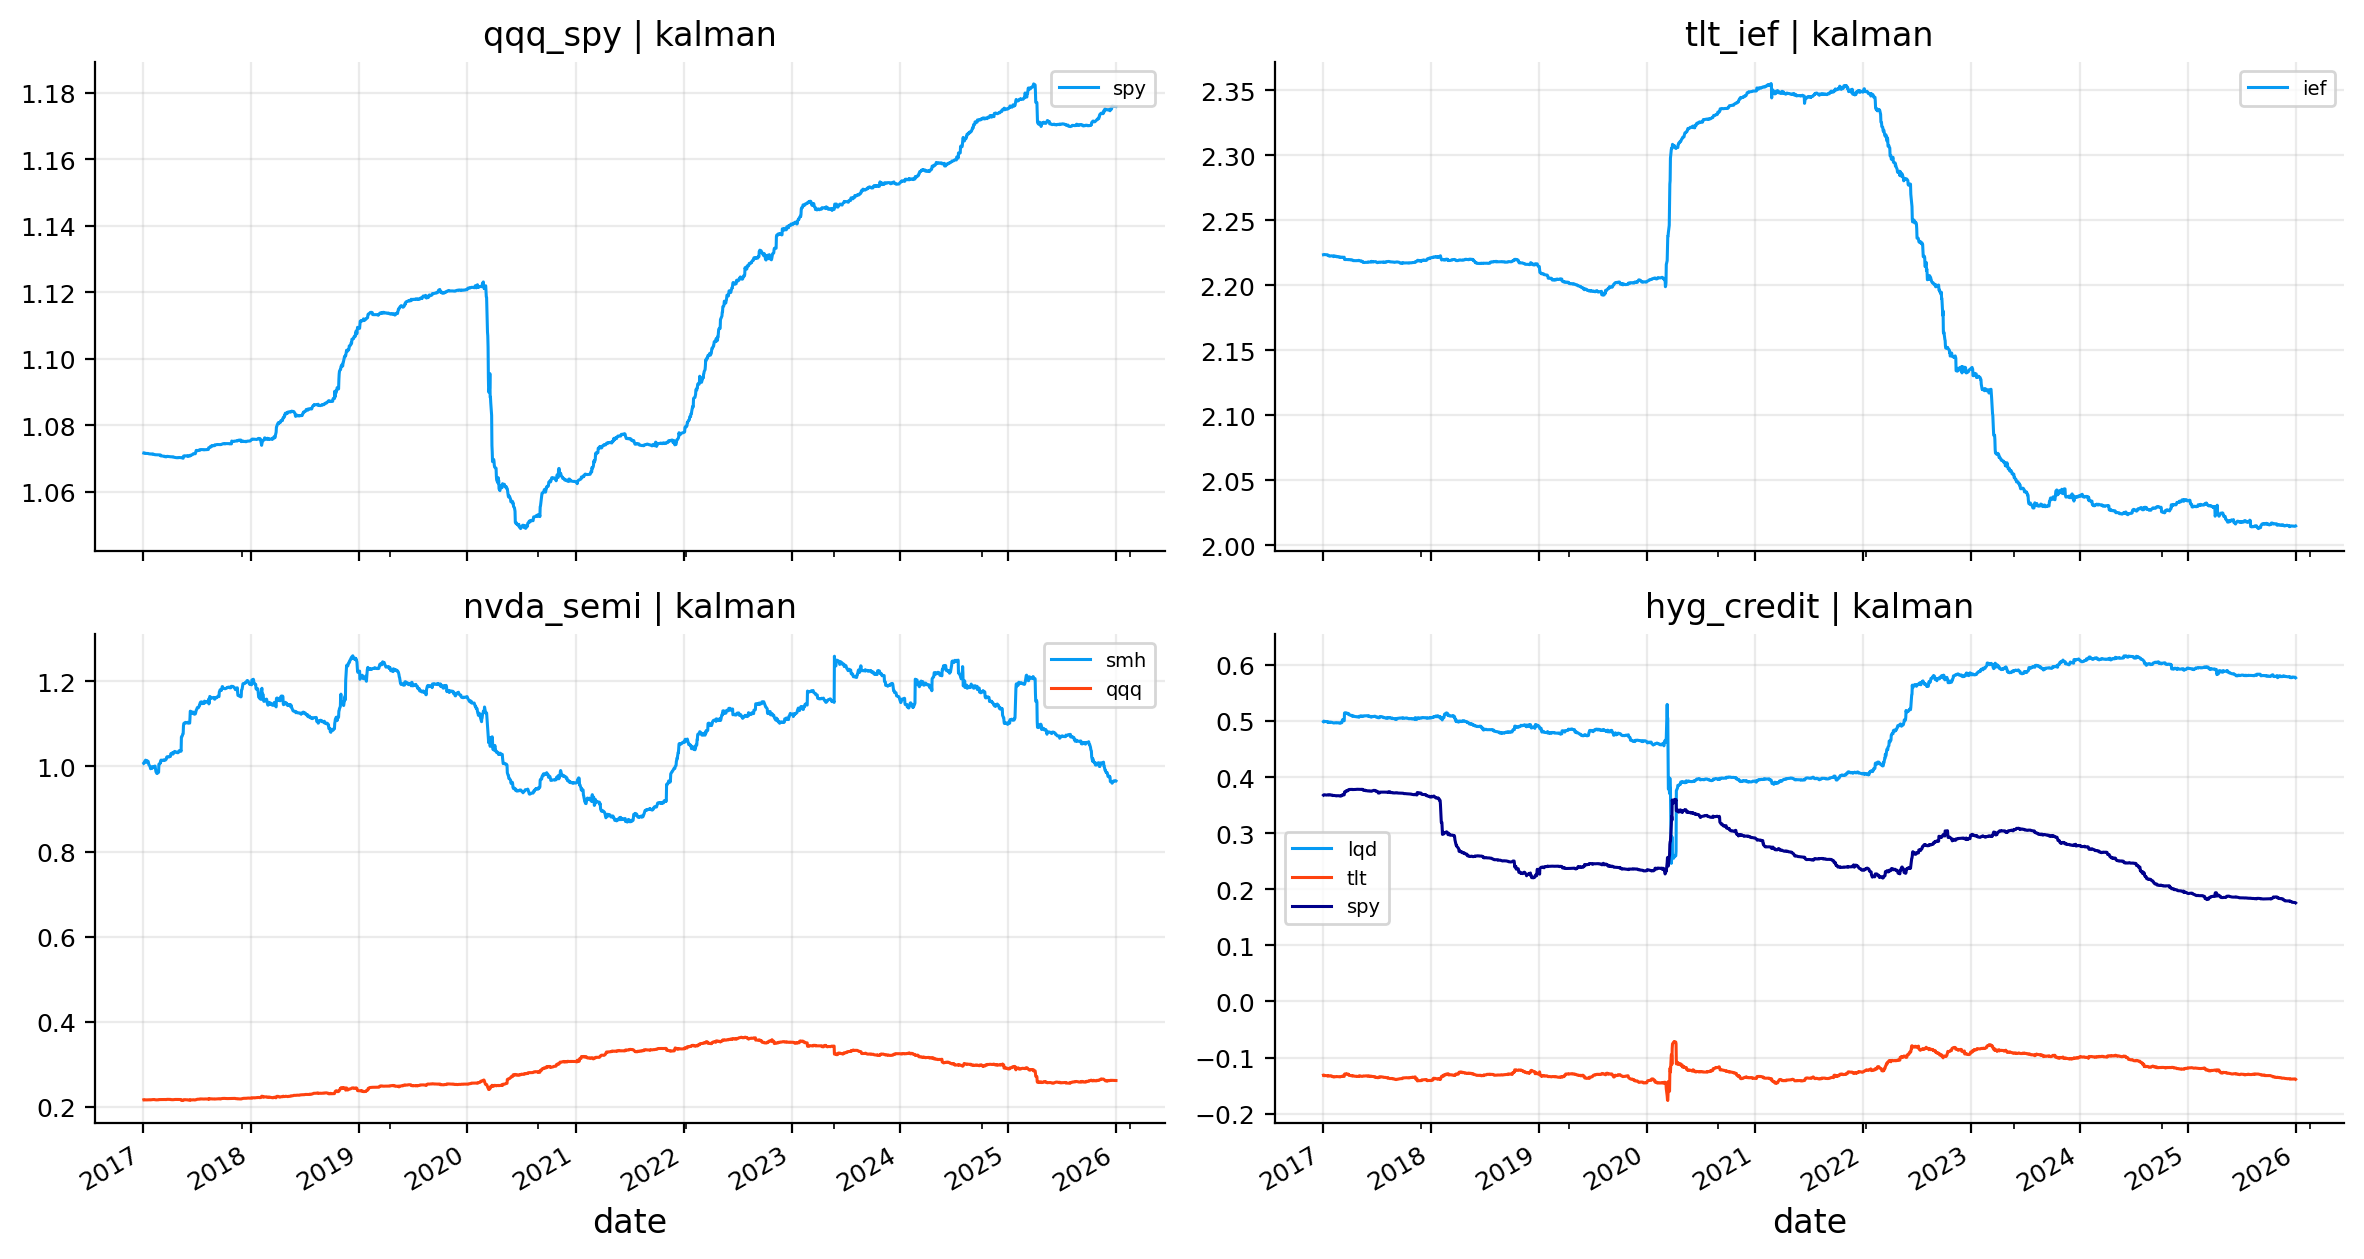

In [12]:
def kf_run(y, x, state0, pcov0, qdiag, obs_var):
    state = state0.copy()
    pcov = pcov0.copy()
    qcov = np.diag(qdiag)
    states, loglik = [], 0.0
    for yy, xx in zip(y, x):
        h = np.r_[1.0, xx]
        pcov = pcov + qcov
        pred = float(h @ state)
        s = float(h @ pcov @ h.T + obs_var)
        if s > 1e-12 and np.isfinite(s):
            err = float(yy - pred)
            loglik += -0.5 * (np.log(2 * np.pi * s) + err * err / s)
            k = (pcov @ h.T) / s
            state = state + k * err
            pcov = (np.eye(len(state)) - np.outer(k, h)) @ pcov
        states.append(state.copy())
    return np.asarray(states), loglik


def kf_beta(ret, r):
    z = ret[r.assets].dropna()
    out = pd.DataFrame(np.nan, index=ret.index, columns=r.hedges)
    if len(z) < n_train:
        return out

    train = z.iloc[:n_train]
    y_train = train[r.target].to_numpy(float)
    x_train = train[r.hedges].to_numpy(float)
    init_n = max(min(n_train // 4, 126), 30)
    a0, b0 = ols_fit(y_train[:init_n], x_train[:init_n])
    state0 = np.r_[a0, b0]
    resid = y_train - np.column_stack([np.ones(len(train)), x_train]) @ state0
    resid_var = max(np.nanvar(resid, ddof=1), 1e-8)
    pcov0 = np.eye(len(state0)) * max(resid_var, 1e-6)

    scale = np.r_[0.05, np.maximum(np.abs(b0), 0.25)]
    best_ll, best_q, best_r = -np.inf, np.r_[1e-7, np.repeat(1e-5, len(b0))], resid_var
    for q0 in [1e-7, 3e-7, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4]:
        qdiag = np.maximum(q0 * scale**2, 1e-12)
        for r0 in [0.5, 1.0, 2.0, 4.0]:
            obs_var = max(resid_var * r0, 1e-10)
            _, ll = kf_run(y_train, x_train, state0, pcov0, qdiag, obs_var)
            ll -= 0.5 * qdiag[1:].sum() / obs_var
            if ll > best_ll:
                best_ll, best_q, best_r = ll, qdiag, obs_var

    y_all = z[r.target].to_numpy(float)
    x_all = z[r.hedges].to_numpy(float)
    states, _ = kf_run(y_all, x_all, state0, pcov0, best_q, best_r)
    out.loc[z.index, r.hedges] = states[:, 1:]
    out.loc[z.index[:n_train - 1], r.hedges] = np.nan
    return out


books_kalman = {}
for r in rel_main:
    b0 = kf_beta(ret_m_main, r)
    b1 = rebalance_beta(b0, ret_b_main.index)
    b2 = band_beta(b1, band=band)
    beta_daily[(r.name, "kalman")] = b0
    books_kalman[f"{r.name} | kalman"] = book_result(hedge_book(ret_b_main, r, b2))
    blog[f"{r.name} | kalman"] = {"rel": r.name, "model": "kalman", "desired": b0, "traded": b2}

bt_kalman = {**books_target, **books_kalman}
tab_kalman = model_table(bt_kalman, rel_main, ret_m_main)
display(tab_kalman[model_cols].round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
for ax, name in zip(axes.ravel(), ["qqq_spy", "tlt_ief", "nvda_semi", "hyg_credit"]):
    key = f"{name} | kalman"
    if key in blog:
        blog[key]["desired"].dropna(how="all").plot(ax=ax, lw=1.1)
        ax.set_title(key)
        ax.grid(True, alpha=0.25)
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

The Kalman results show exactly that smoother behavior.

Risk reduction is strong across most relationships, but turnover is much lower than rolling OLS and ridge in many of the noisy stock relationships. For example:

- **NVDA/SMH+QQQ** gets about **45.6% volatility reduction** with annualized turnover around **0.33**, compared with ridge turnover around **1.59** and rolling turnover above **2.22**.
- **AMD/SMH+QQQ** has turnover around **0.33**, much lower than ridge and rolling, while keeping similar volatility reduction.
- **HYG credit** gets nearly the same ES reduction as rolling OLS, but with much lower turnover.
- **QQQ/SPY** is stable under all methods, so Kalman doesn't need to win there. Its advantage is more about smooth implementation than maximum score.

The Kalman beta plots show smooth paths. QQQ/SPY gradually rises through the sample. TLT/IEF shifts sharply around the rate shock period and then compresses. HYG credit shows changing weights across LQD, TLT, and SPY, which fits the economics of credit: high yield alternates between behaving like credit carry, duration exposure, and equity risk.

Kalman isn't automatically best. In some cases it may be too smooth, especially when a relationship changes quickly. But it's the cleanest statistical answer to dynamic hedge-ratio estimation because it explicitly models beta as an evolving latent state.

## 9) No-trade band sensitivity

After estimating a desired beta path, we decide how aggressively to trade it. The no-trade band controls this. If the band is zero, every weekly beta change is traded. If the band is wider, small beta changes are ignored.

We test:

$$
b \in \{0.00, 0.025, 0.05, 0.075, 0.10\}
$$

For each band, we recompute the hedge books for rolling, ridge, and Kalman models, then evaluate average risk reduction, turnover, cost, and a composite score.

The composite score is intentionally multi-objective. It rewards:

- higher volatility reduction,
- higher ES reduction,
- better drawdown improvement,
- stronger beta reduction,
- more stable beta paths,

and penalizes:

- turnover,
- cost drag,
- negative drawdown effects.

A pure volatility score would be too narrow. A hedge model can reduce variance by taking an unstable residual exposure that creates drawdown or trading costs. The score tries to avoid that.

,model,band,avg_vol_red,avg_es_red,avg_turnover_ann,avg_cost_drag_ann,avg_score
0,kalman,0.000,0.4501,0.4719,0.5335,0.0003,0.3277
1,ridge,0.000,0.4568,0.4816,1.8476,0.0009,0.5336
2,rolling,0.000,0.4566,0.4812,2.5414,0.0013,0.3320
3,kalman,0.025,0.4481,0.4700,0.3931,0.0002,0.3118
4,ridge,0.025,0.4563,0.4807,1.4766,0.0007,0.5592
5,rolling,0.025,0.4562,0.4807,2.1618,0.0011,0.3695
6,kalman,0.050,0.4460,0.4680,0.3508,0.0002,0.2542
7,ridge,0.050,0.4548,0.4796,1.2358,0.0006,0.5659
8,rolling,0.050,0.4559,0.4799,1.8619,0.0009,0.4351
9,kalman,0.075,0.4454,0.4677,0.3155,0.0002,0.2837


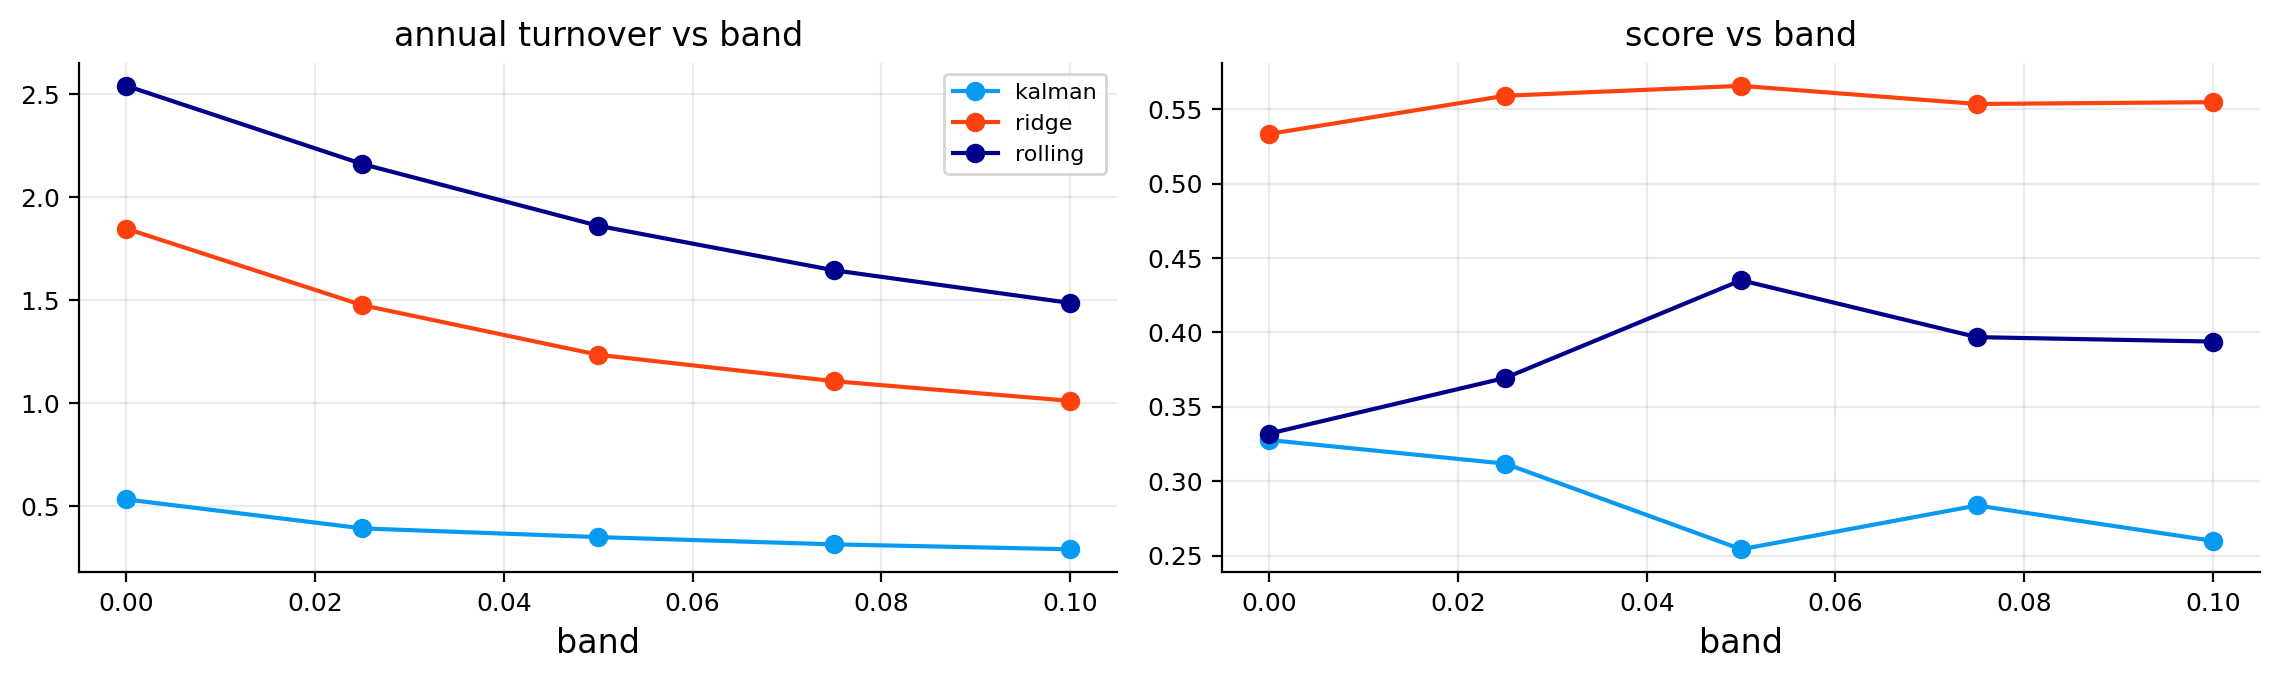

In [13]:
def band_norm(s, lower=False):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.notna().sum() <= 1:
        out = pd.Series(0.5, index=s.index)
    else:
        lo, hi = x.quantile(0.05), x.quantile(0.95)
        xc = x.clip(lo, hi)
        span = xc.max() - xc.min()
        out = pd.Series(0.5, index=s.index) if span <= 1e-12 else (xc - xc.min()) / span
    return (1 - out if lower else out).fillna(0.5)


def band_score(tab):
    parts = []
    for _, g in tab.groupby("relationship", sort=False):
        h = g.copy()
        vol_s = band_norm(h["vol_red"])
        dd_bad = (-pd.to_numeric(h["maxdd_diff"], errors="coerce")).clip(lower=0.0).div(0.10).clip(upper=1.0).fillna(0.0)
        vol_s = vol_s.mask(h["maxdd_diff"] < -0.05, np.minimum(vol_s, 0.50))
        h["score"] = (
            0.30 * vol_s
            + 0.20 * band_norm(h["es_red"])
            + 0.15 * band_norm(h["maxdd_diff"])
            + 0.15 * band_norm(h["beta_red"])
            + 0.10 * band_norm(h["beta_stability"])
            - 0.05 * (1 - band_norm(h["turnover_ann"], lower=True))
            - 0.05 * (1 - band_norm(h["cost_drag_ann"], lower=True))
            - 0.10 * dd_bad
        )
        parts.append(h)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


band_grid = [0.00, 0.025, 0.05, 0.075, 0.10]
dyn_models = ["rolling", "ridge", "kalman"]
sens_rows = []

for bnd in band_grid:
    books_sens = dict(books_target)
    for r in rel_main:
        for m in dyn_models:
            b1 = rebalance_beta(beta_daily[(r.name, m)], ret_b_main.index)
            b2 = band_beta(b1, band=bnd)
            books_sens[f"{r.name} | {m}"] = book_result(hedge_book(ret_b_main, r, b2))
    tab_sens = model_table(books_sens, rel_main, ret_m_main)
    for m, g in band_score(tab_sens).groupby("model"):
        sens_rows.append({"model": m, "band": bnd, "avg_vol_red": g["vol_red"].mean(),
                          "avg_es_red": g["es_red"].mean(), "avg_turnover_ann": g["turnover_ann"].mean(),
                          "avg_cost_drag_ann": g["cost_drag_ann"].mean(), "avg_score": g["score"].mean()})

tab_band = pd.DataFrame(sens_rows)
display(tab_band.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.5), sharex=True)
for m, g in tab_band.groupby("model"):
    axes[0].plot(g["band"], g["avg_turnover_ann"], marker="o", label=m)
    axes[1].plot(g["band"], g["avg_score"], marker="o", label=m)
axes[0].set_title("annual turnover vs band")
axes[1].set_title("score vs band")
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("band")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

The band sensitivity table gives a clean implementation lesson.

Kalman has the lowest turnover at every band. At band zero, its average annual turnover is only about **0.53**, while ridge is around **1.85** and rolling is around **2.54**. This confirms the state-space model is already smoothing the beta path before the no-trade band is applied.

Ridge has the highest average score across the tested bands. At the 5% band, ridge reaches the best average score, around **0.566**, with average volatility reduction around **45.5%** and average ES reduction around **48.0%**. Rolling OLS has similar risk reduction but higher turnover, so its score is lower.

The plots show the tradeoff visually:

- turnover falls as the band gets wider,
- score for ridge improves up to about the 5% band and then stays near the top,
- rolling benefits from a band because raw rolling beta is too jumpy,
- Kalman doesn't benefit much from wider bands because it already trades slowly.

So the 5% band is a reasonable choice. It removes many small noisy updates without freezing the hedge ratio too much.

## 10) Model scoring and best hedge selection

Now we combine the static, rolling, ridge, and Kalman results into one comparison table. The scoring is done **within each relationship**, not globally. That detail matters.

A 40% volatility reduction in TSLA isn't the same difficulty as a 40% reduction in AGG. AGG/BND is a clean ETF replication problem. TSLA/XLY+QQQ is a much harder idiosyncratic stock problem. Scoring within each relationship avoids unfairly rewarding easy pairs only because they are easy.

For relationship $i$ and model $m$, the score has the structure:

$$
\text{score}_{i,m} = 0.30S_{vol} + 0.20S_{ES} + 0.15S_{DD} + 0.15S_{\beta} + 0.10S_{stable} - 0.05P_{turnover} - 0.05P_{cost} - 0.10P_{badDD}
$$

The score isn't a universal truth. It's a practical ranking rule that reflects the project's goal: **risk reduction with stable, tradable hedge ratios**.

The two most important additional diagnostics are:

$$
\text{beta stability} = \frac{1}{1 + \text{IQR}(\beta) + 5\cdot \text{mean}|\Delta \beta|}
$$

and:

$$
\text{score gap} = \text{best score} - \text{second best score}
$$

A large score gap means one model clearly dominates for that relationship. A small score gap means the choice is less certain.

In [14]:
def norm_group(s, lower=False):
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if x.notna().sum() == 0:
        out = pd.Series(0.5, index=s.index)
    else:
        xc = x.clip(x.quantile(0.05), x.quantile(0.95))
        span = xc.max() - xc.min()
        out = pd.Series(0.5, index=s.index) if span <= 1e-12 else (xc - xc.min()) / span
    return (1 - out if lower else out).fillna(0.5)


def score_table(tab):
    parts = []
    for _, g in tab.groupby("relationship", sort=False):
        h = g.copy()
        vol_s = norm_group(h["vol_red"])
        dd_bad = (-pd.to_numeric(h["maxdd_diff"], errors="coerce")).clip(lower=0.0).div(0.10).clip(upper=1.0).fillna(0.0)
        vol_s = vol_s.mask(h["maxdd_diff"] < -0.05, np.minimum(vol_s, 0.50))
        h["score"] = (
            0.30 * vol_s
            + 0.20 * norm_group(h["es_red"])
            + 0.15 * norm_group(h["maxdd_diff"])
            + 0.15 * norm_group(h["beta_red"])
            + 0.10 * norm_group(h["beta_stability"])
            - 0.05 * (1 - norm_group(h["turnover_ann"], lower=True))
            - 0.05 * (1 - norm_group(h["cost_drag_ann"], lower=True))
            - 0.10 * dd_bad
        )
        parts.append(h)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def best_table(tab):
    idx = tab.groupby("relationship")["score"].idxmax()
    cols = ["relationship", "model", "score", "vol_red", "es_red", "maxdd_diff", "cost_drag_ann"]
    return tab.loc[idx, cols].rename(columns={"model": "best_model"}).reset_index(drop=True)


def robust_table(tab):
    wins = best_table(tab)["best_model"].value_counts() if len(tab) else pd.Series(dtype=int)
    rows = []
    for m, g in tab.groupby("model"):
        rows.append({"model": m, "median_score": g["score"].median(),
                     "median_vol_red": g["vol_red"].median(), "median_es_red": g["es_red"].median(),
                     "median_cost_drag_ann": g["cost_drag_ann"].median(), "win_count": int(wins.get(m, 0)),
                     "failure_count": int(((g["vol_red"] <= 0) | (g["score"] <= 0)).sum())})
    return pd.DataFrame(rows).sort_values(["median_score", "win_count"], ascending=False)

,relationship,model,vol_red,es_red,maxdd_diff,beta_red,turnover_ann,cost_drag_ann,beta_stability,rebalance_count
0,qqq_spy,static,0.6417,0.6509,0.1496,0.9547,0.1236,0.0001,1.0000,1
1,qqq_spy,rolling,0.6488,0.6592,0.1628,0.9773,0.2895,0.0001,0.9133,25
2,qqq_spy,ridge,0.6491,0.6586,0.1652,0.9835,0.2597,0.0001,0.9156,21
3,qqq_spy,kalman,0.6392,0.6480,0.1560,0.9537,0.1424,0.0001,0.9531,5
4,tlt_ief,static,0.5837,0.5382,0.1944,0.9163,0.2484,0.0001,1.0000,1
5,tlt_ief,rolling,0.6078,0.5837,0.2272,0.9963,0.6379,0.0003,0.7848,54
6,tlt_ief,ridge,0.6066,0.5834,0.2291,0.9657,0.6048,0.0003,0.7909,53
7,tlt_ief,kalman,0.5902,0.5486,0.2172,0.9354,0.2941,0.0001,0.8085,8
8,agg_bnd,static,0.7153,0.8112,0.1456,0.9857,0.1061,0.0001,1.0000,1
9,agg_bnd,rolling,0.7013,0.8079,0.1379,0.9974,0.1774,0.0001,0.9476,8


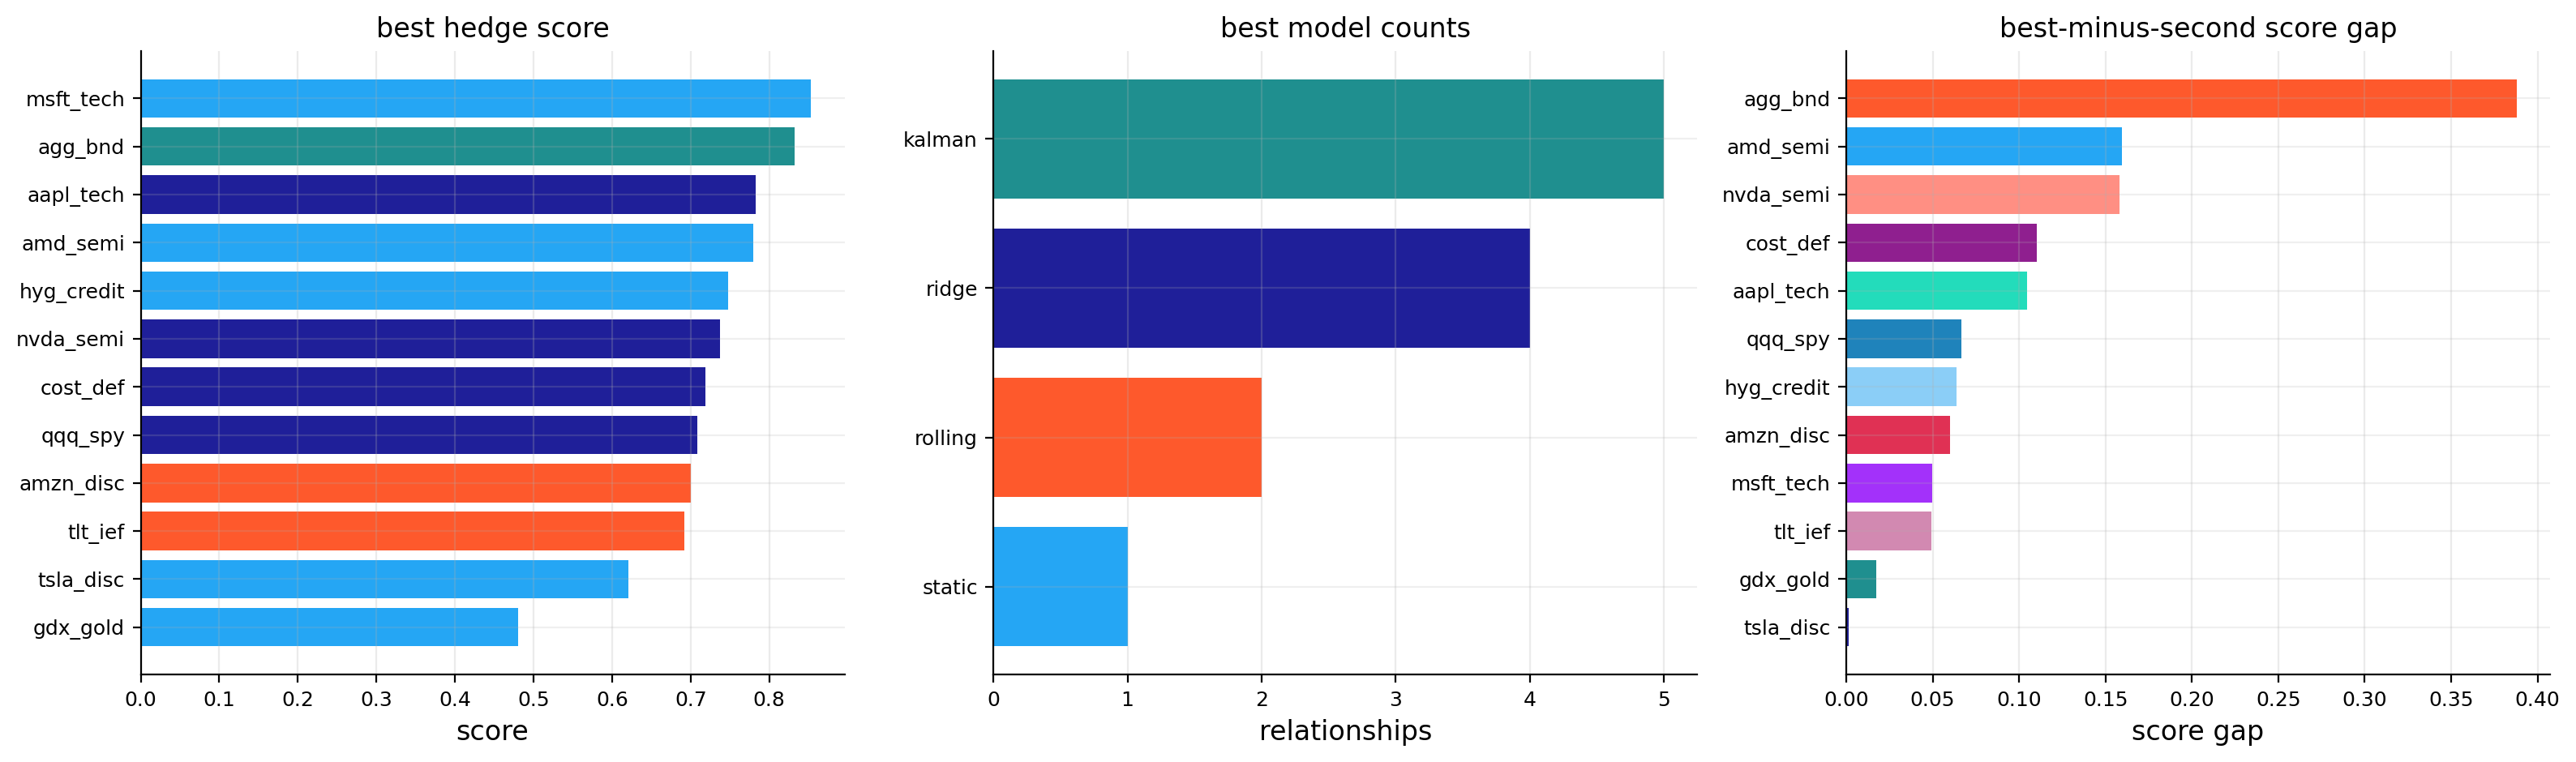

,relationship,best_model,score,vol_red,es_red,maxdd_diff,cost_drag_ann
0,aapl_tech,ridge,0.7829,0.4397,0.4676,0.0575,0.0006
1,agg_bnd,static,0.8328,0.7153,0.8112,0.1456,0.0001
2,amd_semi,kalman,0.7801,0.2970,0.3185,-0.0112,0.0002
3,amzn_disc,rolling,0.7000,0.4059,0.4538,0.1401,0.0009
4,cost_def,ridge,0.7187,0.2857,0.2854,0.0843,0.0004
5,gdx_gold,kalman,0.4807,0.3685,0.3884,-0.2578,0.0006
6,hyg_credit,kalman,0.7479,0.4866,0.5234,0.0531,0.0001
7,msft_tech,kalman,0.8533,0.5283,0.5442,0.1731,0.0002
8,nvda_semi,ridge,0.7379,0.4613,0.4859,0.1700,0.0008
9,qqq_spy,ridge,0.7087,0.6491,0.6586,0.1652,0.0001


,model,median_score,median_vol_red,median_es_red,median_cost_drag_ann,win_count,failure_count
1,ridge,0.6413,0.4505,0.4767,0.0005,4,0
2,rolling,0.6252,0.4513,0.4753,0.0008,2,0
0,kalman,0.4382,0.4294,0.4576,0.0001,5,0
3,static,0.1168,0.4084,0.4394,0.0001,1,1


,relationship,best_vol_red,median_vol_red,best_es_red,best_maxdd_diff,median_cost_drag_ann
0,aapl_tech,0.4416,0.4213,0.4681,0.0575,0.0004
1,agg_bnd,0.7153,0.6962,0.8112,0.1456,0.0001
2,amd_semi,0.2970,0.2948,0.3219,0.0050,0.0007
3,amzn_disc,0.4059,0.3955,0.4538,0.1401,0.0004
4,cost_def,0.2857,0.2813,0.2854,0.0843,0.0002
5,gdx_gold,0.3689,0.3679,0.3923,-0.2578,0.0006
6,hyg_credit,0.4942,0.4868,0.5236,0.0798,0.0002
7,msft_tech,0.5283,0.5264,0.5473,0.1770,0.0002
8,nvda_semi,0.4613,0.4584,0.4859,0.1705,0.0005
9,qqq_spy,0.6491,0.6452,0.6592,0.1652,0.0001


In [15]:
books_all = {}
books_all.update(books_target)
books_all.update(books_static)
books_all.update(books_roll)
books_all.update(books_ridge)
books_all.update(books_kalman)

bt_all = books_all
tab_model = model_table(bt_all, rel_main, ret_m_main)
tab_score = score_table(tab_model)
tab_best = best_table(tab_score)
tab_robust = robust_table(tab_score)

score_cols = ["relationship", "model", "vol_red", "es_red", "maxdd_diff", "beta_red",
              "turnover_ann", "cost_drag_ann", "beta_stability", "rebalance_count"]
display(tab_score[score_cols].round(4).head(20))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
best_plot = tab_best.sort_values("score").copy()
model_order = list(best_plot["best_model"].dropna().unique())
model_colors = {m: colors[i % len(colors)] for i, m in enumerate(model_order)}
axes[0].barh(best_plot["relationship"], best_plot["score"], color=[model_colors[m] for m in best_plot["best_model"]], alpha=0.88)
axes[0].set_title("best hedge score")
axes[0].set_xlabel("score")
axes[0].grid(True, axis="x", alpha=0.25)

counts = tab_best["best_model"].value_counts().sort_values()
axes[1].barh(counts.index, counts.values, color=[colors[i % len(colors)] for i in range(len(counts))], alpha=0.88)
axes[1].set_title("best model counts")
axes[1].set_xlabel("relationships")
axes[1].grid(True, axis="x", alpha=0.25)

gaps = {}
for name, g in tab_score.groupby("relationship"):
    vals = g["score"].dropna().sort_values(ascending=False).values
    gaps[name] = vals[0] - vals[1] if len(vals) > 1 else np.nan
gap_series = pd.Series(gaps).sort_values()
axes[2].barh(gap_series.index, gap_series.values, color=[colors[(i + 2) % len(colors)] for i in range(len(gap_series))], alpha=0.88)
axes[2].set_title("best-minus-second score gap")
axes[2].set_xlabel("score gap")
axes[2].grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

tab_quality = tab_model.groupby("relationship").agg(
    best_vol_red=("vol_red", "max"), median_vol_red=("vol_red", "median"),
    best_es_red=("es_red", "max"), best_maxdd_diff=("maxdd_diff", "max"),
    median_cost_drag_ann=("cost_drag_ann", "median")).reset_index()
display(tab_best.round(4))
display(tab_robust.round(4))
display(tab_quality.round(4))


The best-model table gives a balanced picture rather than one universal winner.

**Ridge** has the strongest median score, around **0.641**, and wins four relationships: AAPL, COST, NVDA, and QQQ. This fits the theory. Ridge is especially useful when hedge variables are correlated and the target has a meaningful but noisy factor structure.

**Kalman** wins the most relationships, with five wins: AMD, GDX, HYG, MSFT, and TSLA. This doesn't mean Kalman has the highest median score. It means it's very useful in specific cases where smoother time variation beats rolling-window instability. Kalman also has the lowest median cost drag, which is economically important.

**Rolling OLS** wins AMZN and TLT. These are cases where more responsiveness helps enough to overcome higher turnover.

**Static OLS** only wins AGG/BND. That's exactly the relationship where static OLS should win. AGG and BND are so structurally close that a dynamic model adds unnecessary movement.

The weakest relationship remains **GDX/gold**, even though Kalman wins it. The best score is only about **0.481**, and the best max-drawdown difference is still negative. That's a warning that the relationship is only partially hedgeable. We can reduce volatility, but we don't fully control the worst path.

The best-minus-second score gap plot is useful because some wins are probably not robust. If the best model barely beats the second-best model, the choice is more about implementation preference. If the gap is large, the model choice is more meaningful.

### 10.1 Why the best model can differ by relationship

There's no reason to expect one estimator to dominate every hedge problem. The underlying economics decide what kind of estimator is appropriate.

For **replication relationships**, like AGG/BND, the true beta is stable. Static OLS can win because dynamic models only add noise.

For **factor-overlap relationships**, like QQQ/SPY or NVDA/SMH+QQQ, ridge can work well because the hedge assets explain real common factors but can be correlated with each other.

For **regime-sensitive relationships**, like HYG credit or GDX gold miners, Kalman can help because exposures change across stress, recovery, inflation, and liquidity regimes.

For **fast-changing relationships**, rolling OLS can win because it responds faster than a conservative Kalman filter. That responsiveness costs more turnover, but sometimes the risk reduction is worth it.

This relationship-specific logic is why the scoring table is more useful than a single average metric. The goal isn't to crown one method as universally best. The goal is to match the estimator to the hedge problem.

## 11) Residual spreads and econometric testing

The first part of we use hedge ratios for **risk reduction**. Now we use hedge ratios for **residual trading**.

The logic changes. For hedging, a residual can be useful simply because it has lower volatility than the target. For residual trading, the residual needs a stronger property: it should be mean-reverting. A low-volatility residual that trends away for years can still create a terrible trade.

For residual trading we switch from returns to log prices. For a target price $P^y_t$ and hedge price $P^x_t$, the price relationship is:

$$
\log P^y_t = \alpha_t + \beta_t \log P^x_t + s_t
$$

where:

- $\log P^y_t$ is the target log price,
- $\log P^x_t$ is the hedge log price,
- $\beta_t$ is the price hedge ratio or cointegrating slope,
- $\alpha_t$ is the intercept,
- $s_t$ is the residual spread.

Rearranging gives the spread directly:

$$
s_t = \log P^y_t - \alpha_t - \beta_t\log P^x_t
$$

If $s_t$ is stationary, deviations from its mean are temporary. A high $s_t$ means the target is expensive relative to the hedge after adjusting for the estimated long-run relationship. A low $s_t$ means the target is cheap relative to the hedge. This creates the logic for a mean-reversion trade.

If $s_t$ has a unit root, the situation is different. A high spread can stay high, move higher, or reflect a permanent economic break. In that case, z-score trading becomes dangerous because the model keeps expecting a reversal that may never arrive.

So the tests in this section aren't decorative. They decide whether a residual is even allowed to become a trading signal.

### 11.1 ADF, Engle-Granger, and half-life

The Augmented Dickey-Fuller test checks whether the spread behaves like a stationary process or like a drifting process with a unit root. A simple version of the test regression is:

$$
\Delta s_t = a + \gamma s_{t-1} + \sum_{j=1}^{p}\phi_j\Delta s_{t-j} + u_t
$$

Here:

- $\Delta s_t = s_t - s_{t-1}$ is the daily change in the spread,
- $s_{t-1}$ is yesterday's spread level,
- $a$ is a constant drift term,
- the lagged differences $\Delta s_{t-j}$ control for autocorrelation in spread changes,
- $u_t$ is the remaining error term,
- $\gamma$ is the key coefficient.

The hypotheses are:

$$
H_0: \gamma = 0 \quad \text{unit root, non-stationary spread}
$$

$$
H_1: \gamma < 0 \quad \text{stationary, mean-reverting spread}
$$

The sign of $\gamma$ matters. If $s_{t-1}$ is high and $\gamma < 0$, then the expected change $\Delta s_t$ is negative, pulling the spread back down. If $s_{t-1}$ is low, the same negative $\gamma$ implies a positive expected move. This is mean reversion in regression form.

Engle-Granger cointegration is related, but the starting question is slightly different. It asks whether two non-stationary price series share a stable long-run relationship. First we estimate:

$$
y_t = \alpha + \beta x_t + s_t
$$

Then we test whether $s_t$ is stationary. If $y_t$ and $x_t$ individually wander through time but their residual $s_t$ mean-reverts, the pair is cointegrated. Financially, this means the two assets can drift, trend, and compound, but their relative valuation has an equilibrium pull.

Half-life translates the strength of mean reversion into trading language. We estimate:

$$
\Delta s_t = a + b s_{t-1} + e_t
$$

and approximate:

$$
\text{half-life} = -\frac{\ln 2}{b}, \quad b < 0
$$

If the half-life is 10 trading days, a spread shock is expected to decay by about half in roughly two weeks. If the half-life is 60 trading days, the same trade may require three months of patience. If the half-life is infinite or negative in the wrong way, the spread isn't mean-reverting enough for this setup.

Here we require a half-life between **2 and 63 trading days**. Very fast spreads are hard to trade after costs. Very slow spreads can trap capital and generate painful drawdowns before the expected reversion happens.

In [16]:
def statsmodels_tools():
    from statsmodels.tsa.stattools import adfuller, coint
    return adfuller, coint


def price_ols_beta(px, target, hedge):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0]).dropna()
    out = pd.DataFrame(np.nan, index=px.index, columns=["alpha", "beta"])
    if len(lp) < n_train:
        return out
    a, b = ols_fit(lp[target].iloc[:n_train], lp[[hedge]].iloc[:n_train])
    out.loc[lp.index[n_train - 1]:, ["alpha", "beta"]] = [a, b[0]]
    return out


def roll_price_beta(px, target, hedge):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0]).dropna()
    out = pd.DataFrame(np.nan, index=px.index, columns=["alpha", "beta"])
    for i in range(max(win, n_train) - 1, len(lp)):
        sample = lp.iloc[i - win + 1:i + 1]
        a, b = ols_fit(sample[target], sample[[hedge]])
        out.loc[lp.index[i], ["alpha", "beta"]] = [a, b[0]]
    return out


def kf_price_beta(px, target, hedge):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0]).dropna()
    out = pd.DataFrame(np.nan, index=px.index, columns=["alpha", "beta"])
    if len(lp) < n_train:
        return out
    a, b = ols_fit(lp[target].iloc[:n_train], lp[[hedge]].iloc[:n_train])
    state = np.array([a, b[0]], dtype=float)
    h0 = np.column_stack([np.ones(n_train), lp[hedge].iloc[:n_train].to_numpy(float)])
    resid = lp[target].iloc[:n_train].to_numpy(float) - h0 @ state
    obs_var = max(np.nanvar(resid, ddof=1), 1e-8)
    pcov = np.eye(2) * 0.10
    qcov = np.diag([1e-7, 1e-5])
    out.loc[lp.index[n_train - 1], ["alpha", "beta"]] = state
    for i in range(n_train, len(lp)):
        h = np.array([1.0, lp[hedge].iloc[i]])
        pcov = pcov + qcov
        s = float(h @ pcov @ h.T + obs_var)
        if s > 1e-12:
            k = (pcov @ h.T) / s
            state = state + k * (lp[target].iloc[i] - h @ state)
            pcov = (np.eye(2) - np.outer(k, h)) @ pcov
        out.loc[lp.index[i], ["alpha", "beta"]] = state
    return out


def log_spread(px, target, hedge, beta):
    lp = np.log(px[[target, hedge]][px[[target, hedge]] > 0])
    b = beta.reindex(lp.index).ffill()
    return (lp[target] - b["alpha"] - b["beta"] * lp[hedge]).replace([np.inf, -np.inf], np.nan)


def eg_test(y, x):
    _, coint = statsmodels_tools()
    z = pd.concat([y, x], axis=1).dropna()
    return float(coint(z.iloc[:, 0], z.iloc[:, 1])[1]) if len(z) >= 30 else np.nan


def adf_test(s):
    adfuller, _ = statsmodels_tools()
    x = pd.Series(s).dropna()
    try:
        return float(adfuller(x, autolag="AIC")[1]) if len(x) >= 30 else np.nan
    except Exception:
        return np.nan


def half_life(s):
    x = pd.Series(s).dropna()
    z = pd.concat([x.diff(), x.shift(1)], axis=1).dropna()
    if len(z) < 30:
        return np.nan
    _, b = ols_fit(z.iloc[:, 0], z.iloc[:, [1]])
    return -np.log(2) / b[0] if b[0] < 0 else np.inf


### 11.2 Z-score trading rule

After a spread passes the econometric gate, we still need a trading rule. We use a rolling z-score:

$$
z_t = \frac{s_t - \bar{s}_{t,126}}{\sigma_{s,t,126}}
$$

where:

- $s_t$ is today's residual spread,
- $\bar{s}_{t,126}$ is the 126-day rolling mean of the spread,
- $\sigma_{s,t,126}$ is the 126-day rolling standard deviation,
- $z_t$ measures how many recent standard deviations the spread is away from its local mean.

The rule is simple:

| Condition | Position logic |
|,-|,-|
| $z_t > 2$ | target is rich relative to hedge, short the spread |
| $z_t < -2$ | target is cheap relative to hedge, long the spread |
| $|z_t| < 0.5$ | spread has mostly normalized, exit |
| $|z_t| > 3.5$ | move is too extreme, stop and cool down |

The stop rule is important. A very large z-score can mean opportunity, but it can also mean the relationship has broken. The cool-down period prevents the strategy from immediately re-entering after a large adverse move.

The signal is lagged by one day before trading, so we don't use same-day information incorrectly. If the spread position is $q_t \in \{-1,0,+1\}$, the daily strategy return is:

$$
r^{strat}_t = q_{t-1}\left(r^y_t - \beta_{t-1}r^x_t\right) - \text{cost}_t
$$

The term inside parentheses is the hedged residual return. The lagged $q_{t-1}$ means the position was decided before today's return was known. The cost term subtracts trading costs from position changes.

This is a residual mean-reversion trade, not a directional investment in the target. We're betting on the relative relationship returning toward its recent equilibrium.

In [17]:
def z_signal(spread):
    z = (spread - spread.rolling(z_win).mean()) / spread.rolling(z_win).std()
    pos, cool, state = 0.0, 0, []
    for val in z:
        if not np.isfinite(val):
            state.append(pos)
        elif abs(val) > z_stop:
            pos = 0.0
            cool = z_cool
            state.append(pos)
        elif cool > 0:
            pos = 0.0
            cool -= 1
            state.append(pos)
        elif pos == 0 and val > z_in:
            pos = -1.0
            state.append(pos)
        elif pos == 0 and val < -z_in:
            pos = 1.0
            state.append(pos)
        elif abs(val) < z_out:
            pos = 0.0
            state.append(pos)
        else:
            state.append(pos)
    return pd.DataFrame({"z": z, "signal": pd.Series(state, index=z.index).shift(1).fillna(0.0)})


def spread_book(ret, target, hedge, beta, signal, cost_bps=cost_bps):
    panel = ret[[target, hedge]].dropna()
    b = beta["beta"].reindex(panel.index).ffill().shift(1)
    sig = signal.reindex(panel.index).fillna(0.0)
    data = pd.concat([panel, b.rename("beta"), sig.rename("signal")], axis=1).dropna()
    spread_ret = data[target] - data["beta"] * data[hedge]
    gross = data["signal"] * spread_ret
    weights = pd.DataFrame({target: data["signal"], hedge: -data["signal"] * data["beta"]})
    turnover = weights.diff().abs().sum(axis=1)
    if len(turnover):
        turnover.iloc[0] = weights.iloc[0].abs().sum()
    cost = turnover * cost_bps / 10000.0
    net = gross - cost
    return {
        "target_return": spread_ret,
        "gross_return": gross,
        "net_return": net,
        "turnover": turnover,
        "cost": cost,
        "beta": beta[["beta"]].rename(columns={"beta": hedge}).reindex(data.index).ffill(),
        "gross_values": (1 + gross).cumprod(),
        "net_values": (1 + net).cumprod(),
        "target_values": (1 + spread_ret).cumprod(),
    }

### 11.3 Dynamic residuals and a subtle econometric caveat

Dynamic hedge ratios make spreads more stationary, but this has to be interpreted carefully. If $\beta_t$ changes through time, the spread is no longer the residual of one fixed long-run relationship. It's the residual after allowing the relationship itself to move.

That can be useful for trading because markets aren't static. Currency regimes, duration relationships, and sector betas change. But it also means an ADF test on a dynamic residual isn't the same as proving classical cointegration under a fixed beta.

This is why the gate treats static and dynamic sources differently. Static spreads are expected to pass a stricter long-run relation test. Dynamic spreads are allowed if the resulting residual is stationary, tradable, and not created by excessive beta turnover.

The beta-turnover filter is important:

$$
\overline{|\Delta \beta|} \le 0.25
$$

Without this filter, a hyperactive beta could force almost any spread to look stationary by chasing the target too closely. We want adaptive residuals, not overfit residuals.

In [18]:
pairs = [
    ("agg_bnd", "agg", "bnd"),
    ("gdx_gld", "gdx", "gld"),
    ("tlt_ief", "tlt", "ief"),
    ("hyg_lqd", "hyg", "lqd"),
    ("xlk_qqq", "xlk", "qqq"),
    ("qqq_spy", "qqq", "spy"),
]
pairs = [p for p in pairs if p[1] in px.columns and p[2] in px.columns]
source_fns = {
    "static_log_ols": lambda t, h: price_ols_beta(px, t, h),
    "rolling_log_ols": lambda t, h: roll_price_beta(px, t, h),
    "kalman_log": lambda t, h: kf_price_beta(px, t, h),
}

gate_rows, resid_bt, resid_z, resid_meta = [], {}, {}, {}
for pair_name, target, hedge in pairs:
    lp = np.log(px[[target, hedge]].dropna())
    eg_p = eg_test(lp[target], lp[hedge])
    for beta_source, fn in source_fns.items():
        params = fn(target, hedge)
        spread = log_spread(px, target, hedge, params)
        sig = z_signal(spread)
        key = f"{pair_name} | {beta_source}"
        res = book_result(spread_book(ret_b, target, hedge, params, sig["signal"]))
        sdrop = spread.dropna()
        split = max(len(sdrop) // 2, 30)
        first, second = sdrop.iloc[:split], sdrop.iloc[split:]
        trades = int((sig["signal"].ne(0) & sig["signal"].shift(1).fillna(0).eq(0)).sum())
        cost_drag = max(total_return(res.gross_values) - total_return(res.net_values), 0.0)
        beta_turnover = params["beta"].dropna().diff().abs().mean()
        gate_rows.append({"pair": pair_name, "beta_source": beta_source, "eg_p": eg_p,
                          "adf_p": adf_test(spread), "half_life": half_life(spread),
                          "spread_vol": spread.diff().std() * np.sqrt(ann), "trades": trades,
                          "cost_drag": cost_drag, "cost_drag_ann": res.cost.mean() * ann if len(res.cost) else 0.0,
                          "break_p": max(adf_test(first), adf_test(second)) if len(second) >= 30 else np.nan,
                          "beta_turnover": beta_turnover, "key": key})
        resid_bt[key], resid_z[key] = res, sig
        resid_meta[key] = {"pair": pair_name, "beta_source": beta_source}

tab_gate = pd.DataFrame(gate_rows)
static_ok = tab_gate["beta_source"].str.contains("static")
tab_gate["eligible"] = (
    ((~static_ok) | (tab_gate["eg_p"] <= 0.10))
    & (tab_gate["adf_p"] <= 0.10)
    & (tab_gate["half_life"].between(2, 63))
    & (tab_gate["spread_vol"] >= 0.005)
    & (tab_gate["trades"] >= 3)
    & (tab_gate["cost_drag_ann"] <= 0.10)
    & (tab_gate["break_p"].fillna(1.0) <= 0.20)
    & (tab_gate["beta_turnover"].fillna(0.0) <= 0.25)
)
display(tab_gate[["pair", "beta_source", "eg_p", "adf_p", "half_life", "spread_vol", "trades", "cost_drag_ann", "beta_turnover", "eligible"]].round(4))

,pair,beta_source,eg_p,adf_p,half_life,spread_vol,trades,cost_drag_ann,beta_turnover,eligible
0,agg_bnd,static_log_ols,0.2615,0.0457,4.3384,0.0159,44,0.0097,0.0000,False
1,agg_bnd,rolling_log_ols,0.2615,0.0000,1.6903,0.0158,52,0.0115,0.0004,False
2,agg_bnd,kalman_log,0.2615,0.0000,0.6732,0.0001,70,0.0152,0.0001,False
3,gdx_gld,static_log_ols,0.1076,0.9985,inf,0.3423,22,0.0109,0.0000,False
4,gdx_gld,rolling_log_ols,0.1076,0.0000,18.7606,0.2400,28,0.0086,0.0074,True
5,gdx_gld,kalman_log,0.1076,0.0000,2.5041,0.2760,41,0.0194,0.0008,True
6,tlt_ief,static_log_ols,1.0000,0.9979,inf,0.0625,26,0.0084,0.0000,False
7,tlt_ief,rolling_log_ols,1.0000,0.0028,37.0943,0.0667,26,0.0083,0.0057,True
8,tlt_ief,kalman_log,1.0000,0.0000,1.2118,0.0357,66,0.0217,0.0004,False
9,hyg_lqd,static_log_ols,0.9235,0.9566,562.7608,0.0715,28,0.0054,0.0000,False


The residual gate table is strict, and that's good. We don't want every visually correlated pair to become a trading signal.

The static log-OLS spreads mostly fail because they don't produce stationary residuals. For example, **GDX/GLD static** has ADF p-value around **0.9985** and infinite half-life, so it clearly fails. The spread can drift, and a z-score strategy would be dangerous.

The dynamic log-OLS spreads often pass because the changing beta absorbs slow structural drift. Eligible rolling spreads include:

- **GDX/GLD**, with ADF p-value near zero and half-life around **18.8 days**,
- **TLT/IEF**, with ADF p-value around **0.0028** and half-life around **37.1 days**,
- **HYG/LQD**, with ADF p-value around **0.0028** and half-life around **42.5 days**,
- **XLK/QQQ**, with ADF p-value near zero and half-life around **30.4 days**.

The Kalman log spreads often have very small half-lives, sometimes near 1 day. That sounds attractive at first, but it can be a warning. A very adaptive beta can absorb too much of the spread movement, leaving a residual that looks statistically stationary but has too little economically tradable structure. This is why the gate includes half-life, spread volatility, trades, cost, and beta turnover, not just ADF p-values.

,pair,beta_source,trades,avg_hold,net_return,ann_vol,sharpe,maxdd,cost_drag,cost_drag_ann
4,gdx_gld,rolling_log_ols,28,25.1429,0.8787,0.1181,0.6535,-0.1395,0.1518,0.0086
7,tlt_ief,rolling_log_ols,26,32.1538,-0.0721,0.0469,-0.1545,-0.1949,0.0718,0.0083
10,hyg_lqd,rolling_log_ols,28,27.9643,0.0917,0.0408,0.2597,-0.0610,0.0520,0.0052
13,xlk_qqq,rolling_log_ols,30,24.6000,0.0582,0.0336,0.2045,-0.0893,0.0677,0.0069


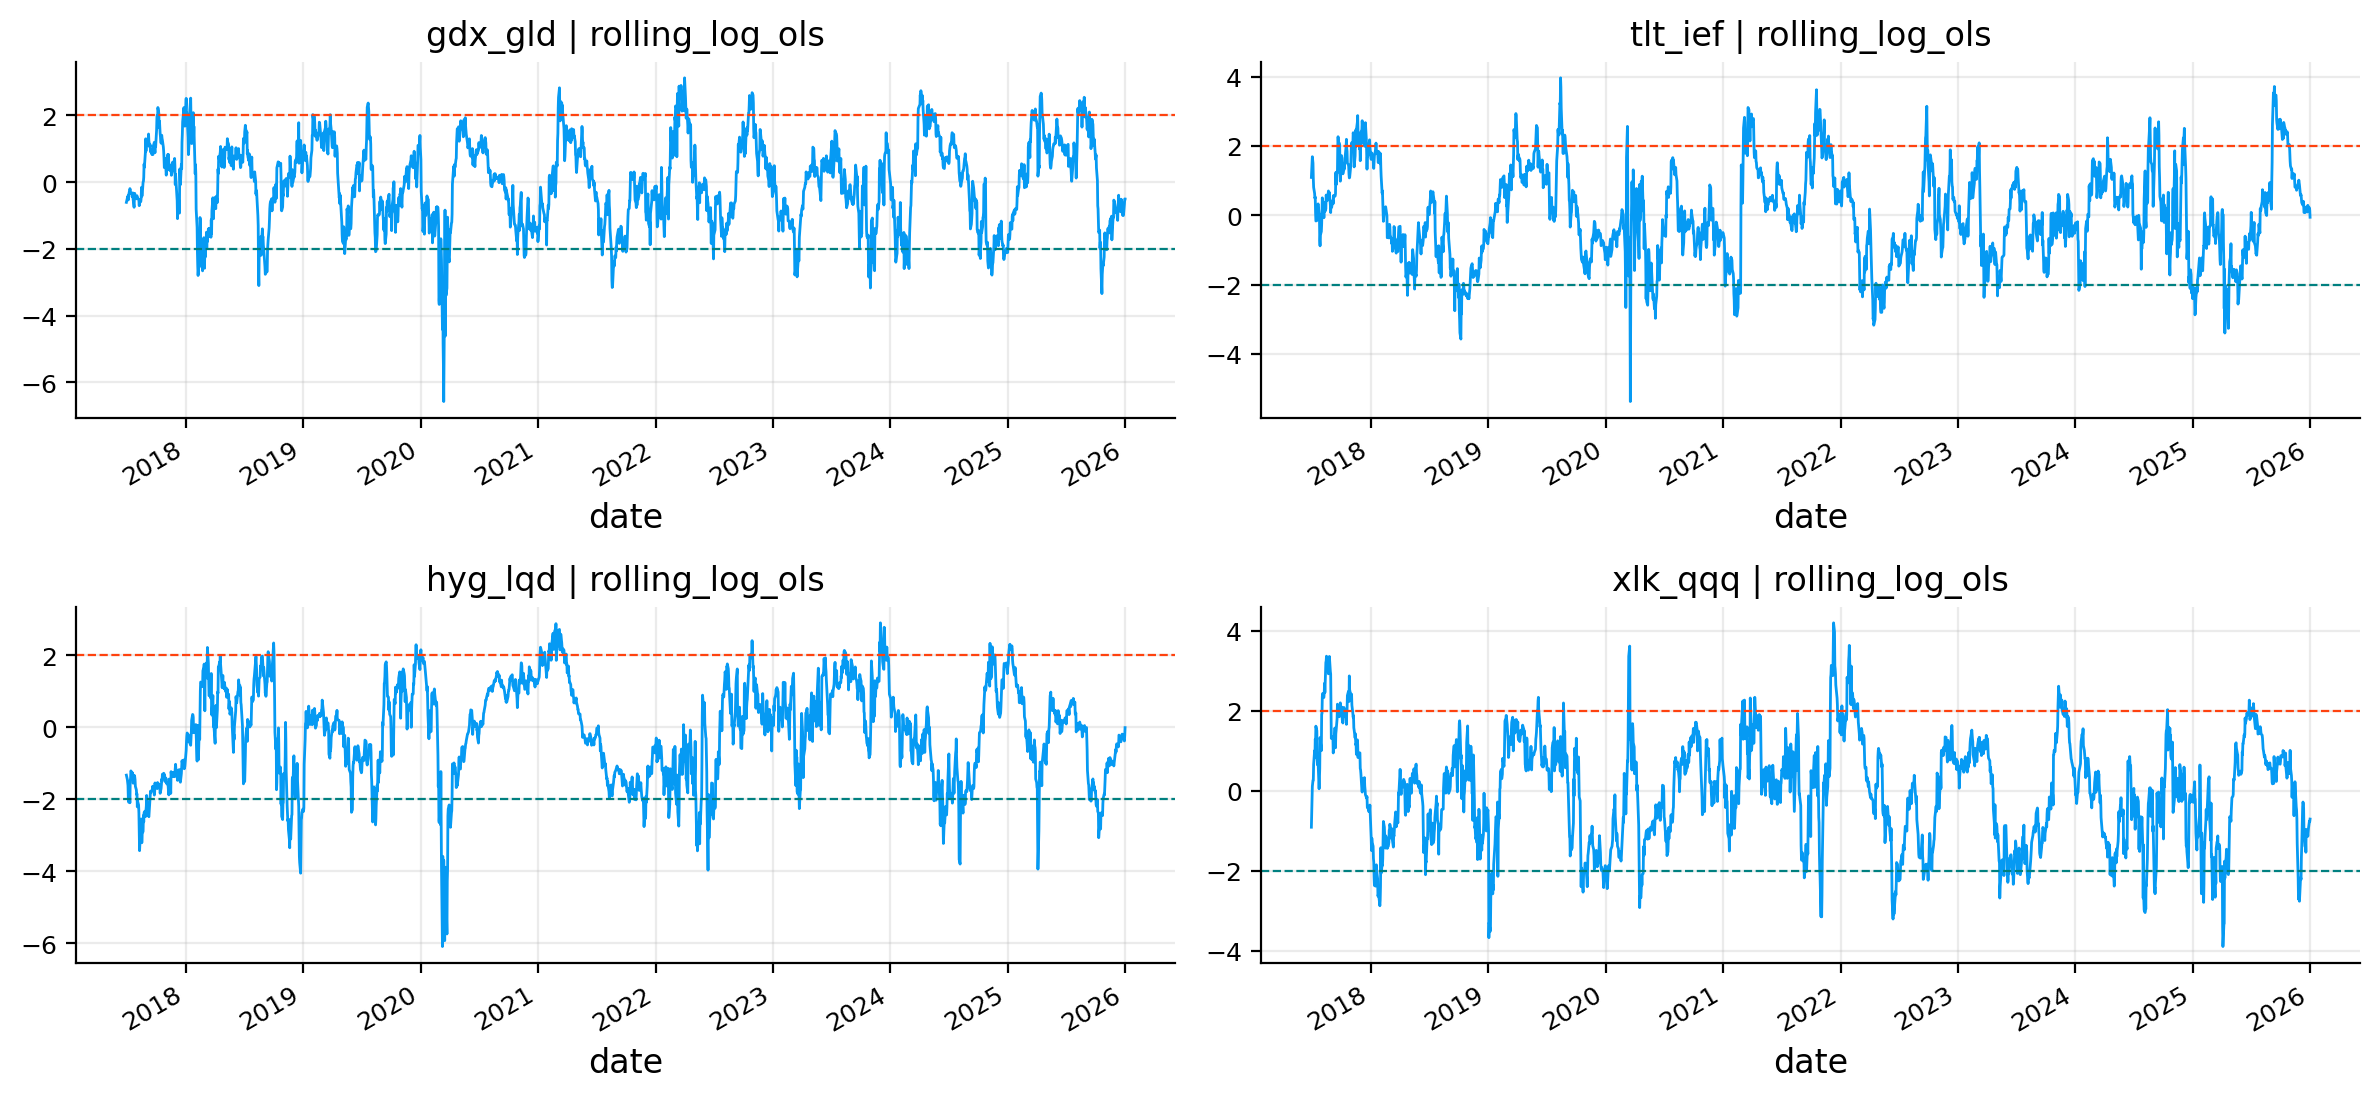

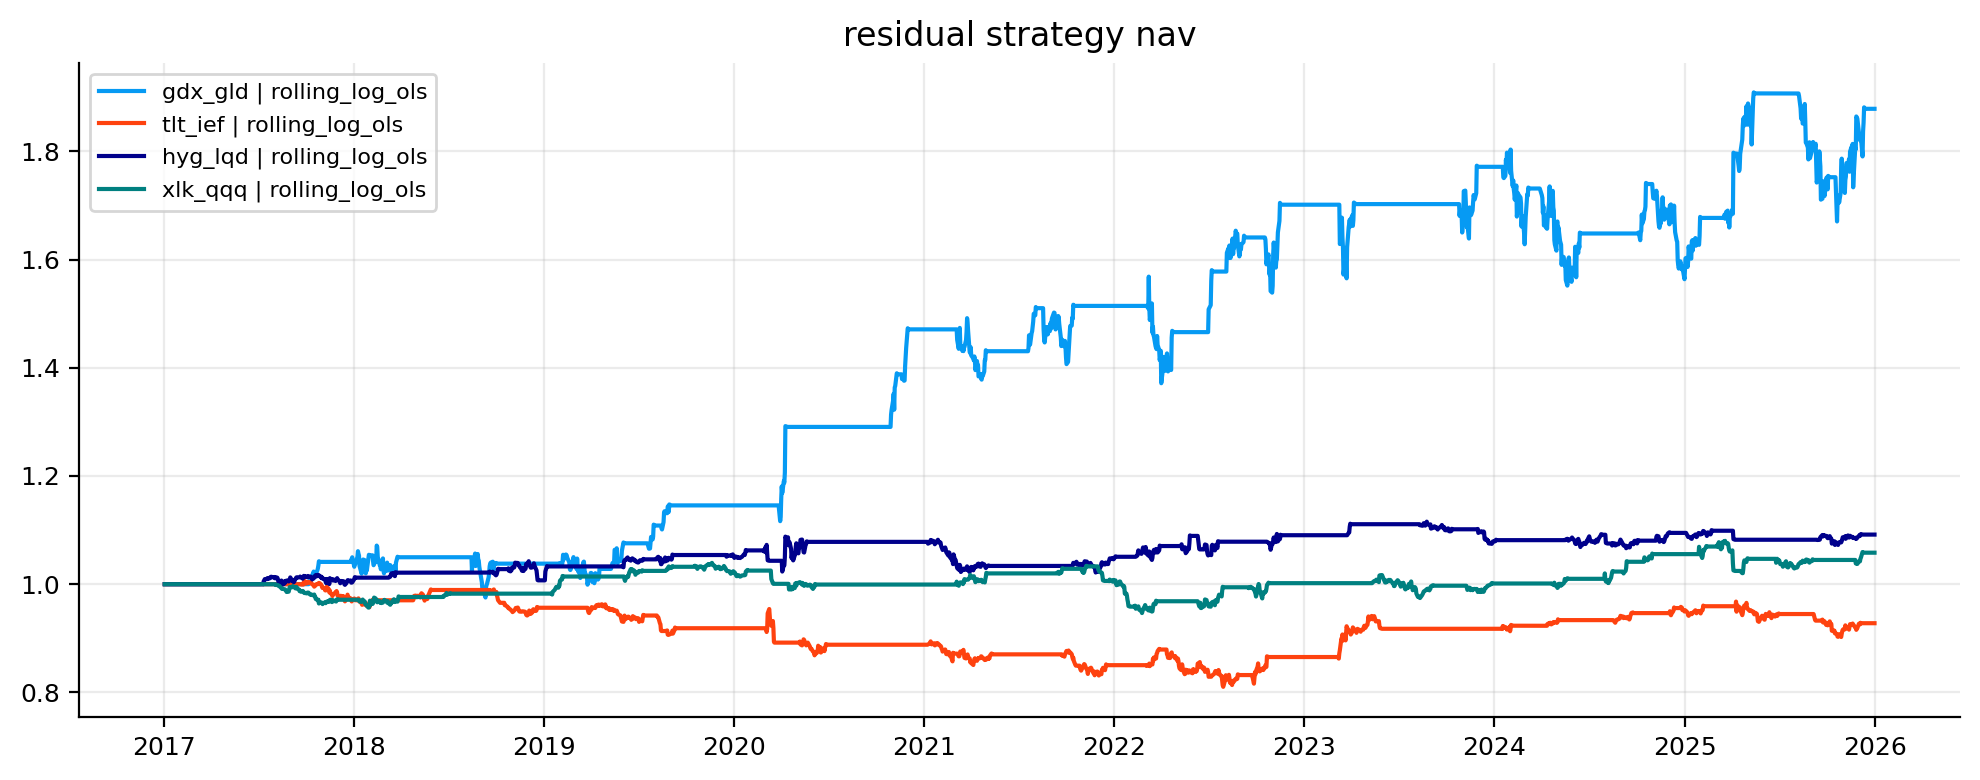

In [19]:
tab_resid = residual_trade_table(resid_bt, resid_z, resid_meta, ann=ann)
pick_gate = tab_gate[tab_gate["eligible"] & ~tab_gate["beta_source"].eq("kalman_log")]
rolling_keys = pick_gate.loc[pick_gate["beta_source"].eq("rolling_log_ols"), "key"].tolist()
keep_keys = rolling_keys or pick_gate["key"].tolist()
if not keep_keys:
    keep_keys = tab_resid[~tab_resid["beta_source"].eq("kalman_log")].sort_values("trades", ascending=False)["key"].head(6).tolist()

display(tab_resid[tab_resid["key"].isin(keep_keys)].drop(columns="key").round(4))

fig, axes = plt.subplots(math.ceil(len(keep_keys[:6]) / 2), 2, figsize=(12, 2.8 * math.ceil(len(keep_keys[:6]) / 2)), squeeze=False)
for ax, key in zip(axes.ravel(), keep_keys[:6]):
    resid_z[key]["z"].dropna().plot(ax=ax, lw=1.0)
    ax.axhline(z_in, ls="--", lw=0.8, c=colors[1])
    ax.axhline(-z_in, ls="--", lw=0.8, c=colors[3])
    ax.set_title(key)
    ax.grid(True, alpha=0.25)
for ax in axes.ravel()[len(keep_keys[:6]):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for key in keep_keys[:6]:
    nav = resid_bt[key].net_values
    ax.plot(nav.index, nav / nav.iloc[0], label=key)
ax.set_title("residual strategy nav")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 12) Residual trading results

After the gates, we focus on selected rolling log-OLS residual strategies. The performance table reports trades, average holding period, net return, annualized volatility, Sharpe, max drawdown, and cost drag.

The strongest result is **GDX/GLD rolling log-OLS**. It has **28 trades**, average holding period around **25 days**, net return around **87.9%**, annualized volatility around **11.8%**, and Sharpe around **0.65**. This is economically plausible. Gold miners versus gold often produce wide deviations because miners behave partly like equities and partly like leveraged gold exposure. When the spread is estimated dynamically, some deviations appear tradable.

**HYG/LQD** is modest but positive, with net return around **9.2%** and Sharpe around **0.26**. That fits the credit-spread intuition. High yield and investment-grade credit are related, but HYG has equity and default-risk components that can overshoot.

**XLK/QQQ** is also positive but small. That makes sense because XLK and QQQ overlap heavily. The spread is cleaner, but the opportunity set is narrower.

**TLT/IEF** passes the statistical gate but loses money, with net return around **-7.2%** and Sharpe around **-0.15**. This is a very useful failure. A spread can look statistically stationary and still be weak as a trading strategy. The residual might revert, but not fast enough after costs and signal timing, or the rate-regime shifts may create losses during the holding period.

The z-score plots show why residual trading needs discipline. The spread often spends long periods near zero, then moves sharply through entry levels. The strategy only trades when the deviation is large enough, and exits when the residual normalizes.

The residual NAV plot is even more informative. GDX/GLD dominates the selected residual strategies. It has step-like gains, which means the strategy earns most of its return during specific episodes rather than smoothly every month. HYG/LQD and XLK/QQQ grow slowly. TLT/IEF drifts below 1 and stays weak.

That pattern is realistic. Residual trading isn't a stable coupon. It depends on episodic mispricing or temporary dislocation. The econometric tests help avoid terrible candidates, but they don't guarantee positive P&L. The final test is still the backtested trade path after costs.

,relationship,best_model,score,vol_red,es_red,maxdd_diff,cost_drag_ann
0,aapl_tech,ridge,0.7829,0.4397,0.4676,0.0575,0.0006
1,agg_bnd,static,0.8328,0.7153,0.8112,0.1456,0.0001
2,amd_semi,kalman,0.7801,0.2970,0.3185,-0.0112,0.0002
3,amzn_disc,rolling,0.7000,0.4059,0.4538,0.1401,0.0009
4,cost_def,ridge,0.7187,0.2857,0.2854,0.0843,0.0004
5,gdx_gold,kalman,0.4807,0.3685,0.3884,-0.2578,0.0006
6,hyg_credit,kalman,0.7479,0.4866,0.5234,0.0531,0.0001
7,msft_tech,kalman,0.8533,0.5283,0.5442,0.1731,0.0002
8,nvda_semi,ridge,0.7379,0.4613,0.4859,0.1700,0.0008
9,qqq_spy,ridge,0.7087,0.6491,0.6586,0.1652,0.0001


,pair,beta_source,trades,avg_hold,net_return,ann_vol,sharpe,maxdd,cost_drag,cost_drag_ann
4,gdx_gld,rolling_log_ols,28,25.1429,0.8787,0.1181,0.6535,-0.1395,0.1518,0.0086
7,tlt_ief,rolling_log_ols,26,32.1538,-0.0721,0.0469,-0.1545,-0.1949,0.0718,0.0083
10,hyg_lqd,rolling_log_ols,28,27.9643,0.0917,0.0408,0.2597,-0.0610,0.0520,0.0052
13,xlk_qqq,rolling_log_ols,30,24.6000,0.0582,0.0336,0.2045,-0.0893,0.0677,0.0069


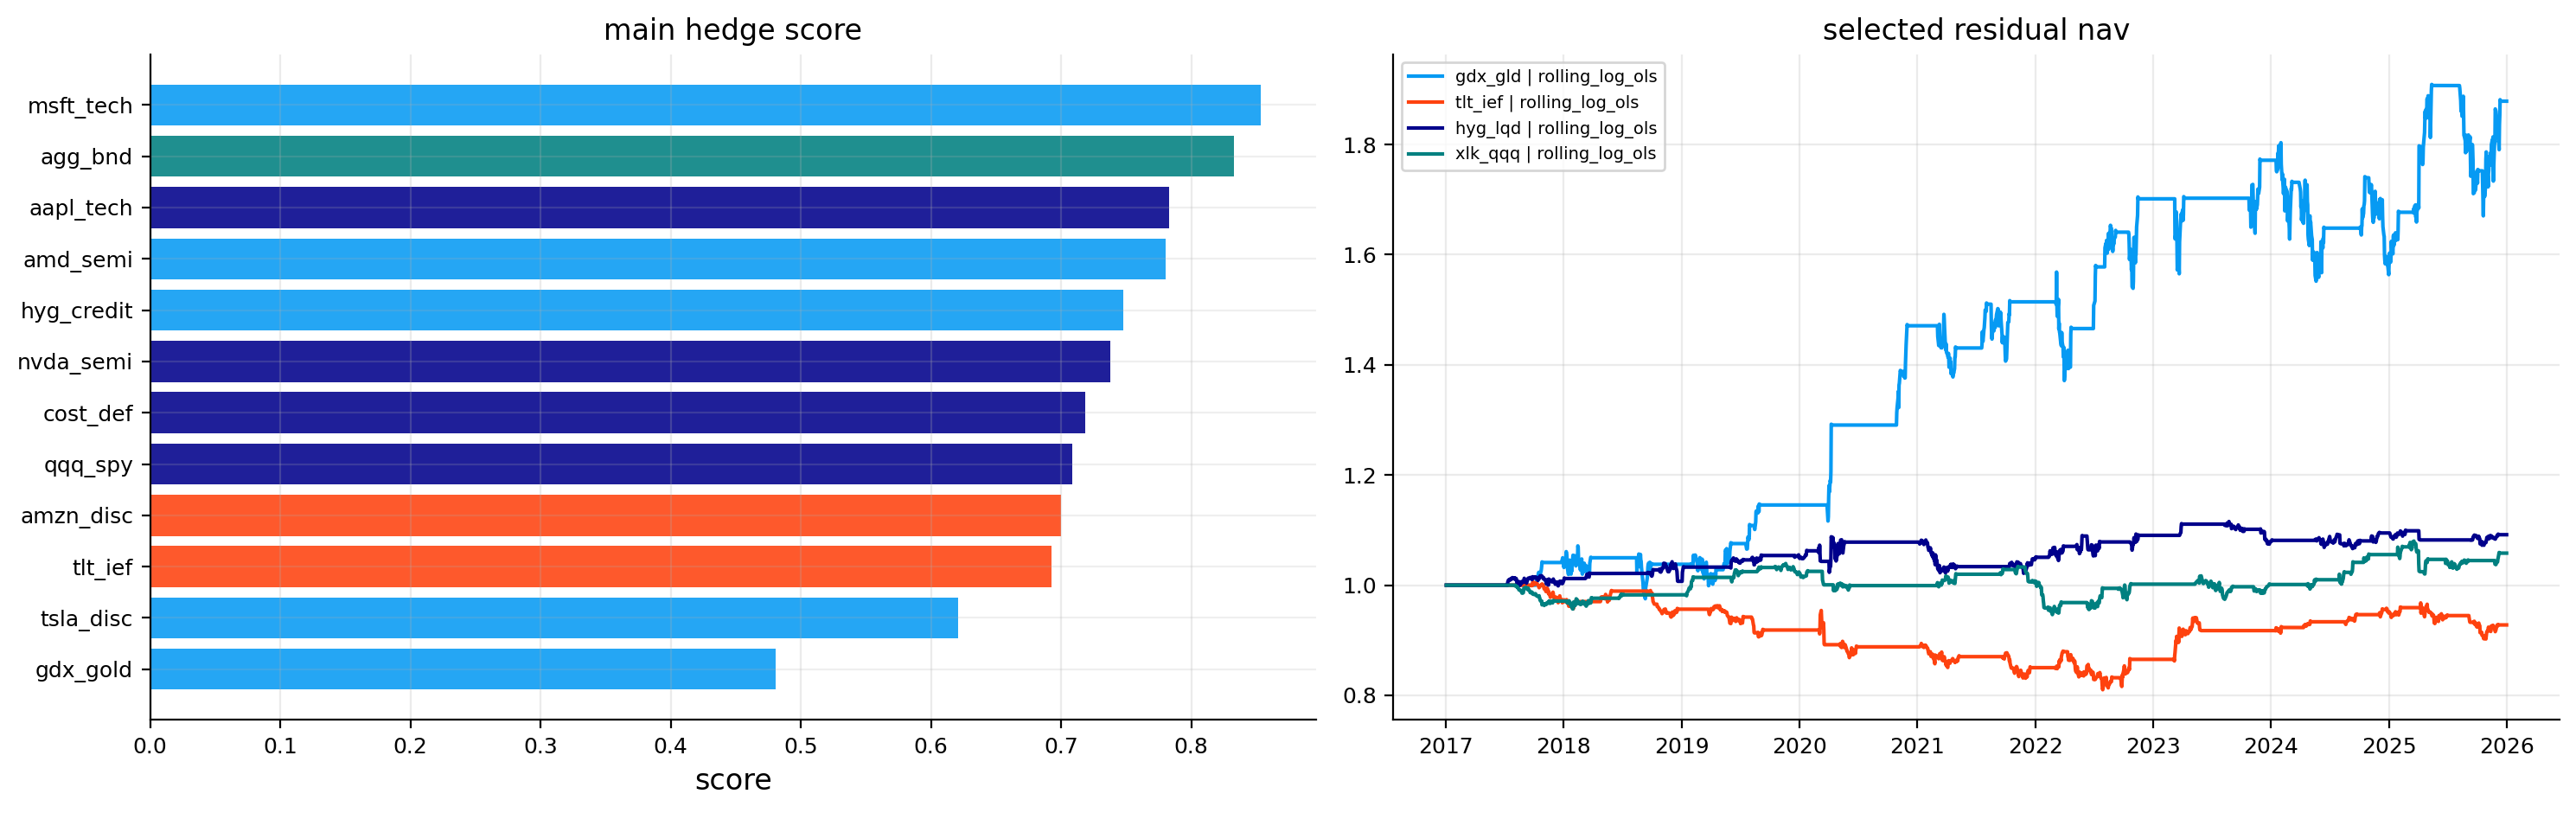

In [20]:
display(tab_best.round(4))
display(tab_resid[tab_resid["key"].isin(keep_keys)].drop(columns="key").round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
best_plot = tab_best.sort_values("score").copy()
model_order = list(best_plot["best_model"].dropna().unique())
model_colors = {m: colors[i % len(colors)] for i, m in enumerate(model_order)}
axes[0].barh(best_plot["relationship"], best_plot["score"], color=[model_colors[m] for m in best_plot["best_model"]], alpha=0.88)
axes[0].set_title("main hedge score")
axes[0].set_xlabel("score")
axes[0].grid(True, axis="x", alpha=0.25)
for key in keep_keys[:6]:
    nav = resid_bt[key].net_values
    axes[1].plot(nav.index, nav / nav.iloc[0], label=key)
axes[1].set_title("selected residual nav")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 13) Final applied output for the main universe

The final main-universe output puts the two sides of the project together:

1. the best hedge model for each target relationship,
2. the selected residual strategies that passed the trading gate.

The best hedge table confirms the model mix:

- **Kalman** is selected for AMD, GDX, HYG, MSFT, and TSLA.
- **Ridge** is selected for AAPL, COST, NVDA, and QQQ.
- **Rolling OLS** is selected for AMZN and TLT.
- **Static OLS** is selected only for AGG/BND.

This division is exactly what we want to see. Clean replication gets static. Correlated multi-hedge stock exposures often get ridge. Noisy or changing relationships often get Kalman. A few cases need rolling responsiveness.

The best scores are highest for **MSFT**, **AGG/BND**, **AAPL**, **AMD**, and **HYG**. GDX has the lowest best score because miners are only partially hedgeable. TSLA also has a lower score because it carries large company-specific risk that sector and growth hedges can't fully remove.

The selected residual NAV panel repeats the earlier message: GDX/GLD is the standout residual trade, while the others are modest or weak. So the main project has two separate conclusions. Dynamic hedge ratios are broadly useful for risk reduction, but residual trading is selective. We shouldn't trade a residual just because we can estimate a beta.

## 14) International ETF transfer with the library

The secondary application transfers the same workflow to international ETFs using the packaged `quantfinlab` hedging tools. This part is especially important because international ETFs contain richer economic structure than the main single-stock examples.

For reproduction, check the [international_hedging_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/international_hedging_etfs) folder in the data directory. The local code reads the generated international ETF panel, while the folder explains how that panel is created. This section also uses the same supporting ETF sources from the core cross-asset and sector ETF data folders.

International equity ETFs combine several overlapping risk layers:

- **local equity market beta**, such as Japan, Europe, China, Brazil, India, Taiwan, or Korea,
- **currency translation**, because unhedged country ETFs are priced in USD even when the local market moves in another currency,
- **global equity beta**, because most country ETFs still sell off when global risk appetite collapses,
- **commodity sensitivity**, especially for Canada, Australia, and Brazil,
- **regional supply-chain exposure**, especially Taiwan and Korea through semiconductors,
- **dollar liquidity pressure**, because a strong US dollar often tightens financial conditions for emerging markets.

So the hedge baskets aren't arbitrary. They are economic decompositions of country ETF returns. This is why the final section has more interpretation than a normal secondary implementation.

### 14.0 International hedging as economic decomposition

The international application tests whether hedge ratios can separate a country ETF into recognizable macro components.

For US single stocks, the hedge problem is usually sector and market beta. For international ETFs, the target return can be decomposed more like:

$$
r^{country}_t \approx \beta_1 r^{local\ equity}_t + \beta_2 r^{FX}_t + \beta_3 r^{global\ risk}_t + \beta_4 r^{commodity}_t + \varepsilon_t
$$

This equation isn't one universal model for every country. It's a template for thinking. The relevant components differ by market:

- Japan needs yen exposure and a currency-hedged Japan ETF.
- Europe needs euro exposure and a currency-hedged eurozone ETF.
- Canada and Australia need commodity and local currency exposure.
- Taiwan and Korea need semiconductor and global technology exposure.
- Brazil and India need EM beta and dollar-pressure controls.
- China needs China-specific proxies rather than only broad EM.

A strong result here means the hedge model is capturing real economic structure. If EFA can be hedged by HEFA and UUP, we're separating developed international equity from currency translation. If Canada can be hedged by SPY, XLE, DBC, and FXC, we're decomposing Canada into US/global equity linkage, energy/commodity exposure, and Canadian-dollar movement.

This is exactly why international ETFs are a good stress test for the framework. The relationships are still statistical, but the hedge baskets have economic meaning.

### 14.1 International relationships and economic design

The secondary relationship list is one of the strongest parts of the project because each hedge basket has a real macro story:

| Target relationship | Hedge assets | Economic interpretation |
|-|-|-|
| EFA/HEFA | HEFA, UUP | developed ex-US equity with currency-hedged EAFE and dollar exposure |
| EWJ/DXJ | DXJ, FXY, SPY | Japan equity after yen exposure and global equity beta |
| EZU/HEZU | HEZU, FXE, SPY | eurozone equity after euro movement and global risk beta |
| EWC macro | SPY, XLE, DBC, FXC | Canada through US linkage, energy/commodity exposure, and CAD |
| EWA macro | EFA, DBC, FXA | Australia through developed ex-US beta, commodities, and AUD |
| EWH macro | FXI, MCHI, VNQ, UUP | Hong Kong through China exposure, property sensitivity, and dollar liquidity |
| EWT macro | EEM, SMH, QQQ, UUP | Taiwan through EM, semiconductors, global tech, and dollar pressure |
| EWY macro | EEM, SMH, EWT, UUP | Korea through EM, semiconductors, Taiwan linkage, and dollar pressure |
| INDA macro | EEM, QQQ, UUP | India as EM growth with global tech/style and dollar sensitivity |
| EWZ macro | EEM, DBC, UUP | Brazil as EM plus commodities and dollar exposure |
| EWW macro | SPY, EEM, UUP | Mexico through US economic linkage, EM beta, and dollar exposure |
| FXI macro | MCHI, KWEB, ASHR, UUP | China large caps through broad China, internet, A-shares, and dollar exposure |

The important point isn't just whether $R^2$ is high. The important point is whether the residual that remains after hedging has a meaningful interpretation. If a country ETF remains hard to hedge after using sensible macro proxies, that residual may represent local political risk, local earnings composition, sector weights, index construction, or market-specific investor flows.

available secondary tickers: 30
missing secondary tickers: {}


,relationship,target,hedges,residual_pair,included
0,efa_hefa,efa,"hefa, uup",,True
1,ewj_dxj,ewj,"dxj, fxy, spy",,True
2,ezu_hezu,ezu,"hezu, fxe, spy",,True
3,ewc_macro,ewc,"spy, xle, dbc, fxc",,True
4,ewa_macro,ewa,"efa, dbc, fxa",,True
5,ewh_macro,ewh,"fxi, mchi, vnq, uup",,True
6,ewt_macro,ewt,"eem, smh, qqq, uup",,True
7,ewy_macro,ewy,"eem, smh, ewt, uup",,True
8,inda_macro,inda,"eem, qqq, uup",,True
9,ewz_macro,ewz,"eem, dbc, uup",,True


,relationship,target,hedges,start,end,obs,missing_pct,included
0,efa_hefa,efa,"hefa, uup",2015-01-02,2025-12-31,2766,0.0,True
1,ewj_dxj,ewj,"dxj, fxy, spy",2015-01-02,2025-12-31,2766,0.0,True
2,ezu_hezu,ezu,"hezu, fxe, spy",2015-01-02,2025-12-31,2766,0.0,True
3,ewc_macro,ewc,"spy, xle, dbc, fxc",2015-01-02,2025-12-31,2766,0.0,True
4,ewa_macro,ewa,"efa, dbc, fxa",2015-01-02,2025-12-31,2766,0.0,True
5,ewh_macro,ewh,"fxi, mchi, vnq, uup",2015-01-02,2025-12-31,2766,0.0,True
6,ewt_macro,ewt,"eem, smh, qqq, uup",2015-01-02,2025-12-31,2766,0.0,True
7,ewy_macro,ewy,"eem, smh, ewt, uup",2015-01-02,2025-12-31,2766,0.0,True
8,inda_macro,inda,"eem, qqq, uup",2015-01-02,2025-12-31,2766,0.0,True
9,ewz_macro,ewz,"eem, dbc, uup",2015-01-02,2025-12-31,2766,0.0,True


,relationship,target_vol,hedge_vol,corr,r2,beta_iqr,obs
0,efa_hefa,0.1730,0.0920,0.6964,0.4849,0.0588,2765
1,ewj_dxj,0.1743,0.1119,0.9253,0.8562,0.0380,2765
2,ezu_hezu,0.2056,0.1212,0.9524,0.9071,0.0152,2765
3,ewc_macro,0.1918,0.1483,0.8479,0.7190,0.0699,2765
4,ewa_macro,0.2308,0.1200,0.8128,0.6606,0.1231,2765
5,ewh_macro,0.1983,0.1618,0.8140,0.6625,0.1575,2765
6,ewt_macro,0.2113,0.1690,0.8065,0.6504,0.0919,2765
7,ewy_macro,0.2468,0.1647,0.8023,0.6437,0.1115,2765
8,inda_macro,0.2151,0.1301,0.6796,0.4618,0.1448,2765
9,ewz_macro,0.3537,0.1037,0.6446,0.4155,0.2010,2765


,relationship,best_model,score,vol_red,es_red,maxdd_diff,cost_drag_ann
0,efa_hefa,static,0.8057,0.8543,0.8717,0.2745,0.0001
1,ewa_macro,kalman,0.5651,0.5561,0.5659,0.2174,0.0002
2,ewc_macro,ridge,0.7109,0.5648,0.5636,0.2279,0.0004
3,ewh_macro,ridge,0.6132,0.4344,0.4368,-0.0001,0.0004
4,ewj_dxj,kalman,0.7336,0.7899,0.7939,0.0412,0.0001
5,ewt_macro,rolling,0.7000,0.5082,0.5353,0.2079,0.0006
6,eww_macro,kalman,0.6352,0.2886,0.3101,0.0280,0.0003
7,ewy_macro,kalman,0.7313,0.4957,0.5081,0.0647,0.0002
8,ewz_macro,ridge,0.6035,0.2770,0.2739,0.0255,0.0012
9,ezu_hezu,kalman,0.8573,0.9132,0.9137,0.2433,0.0001


,model,median_score,median_vol_red,median_es_red,median_cost_drag_ann,win_count,failure_count
0,rolling,0.5840,0.5334,0.5465,0.0005,2,0
1,kalman,0.5780,0.5269,0.5397,0.0001,6,0
2,ridge,0.5253,0.5337,0.5486,0.0004,3,2
3,static,0.2530,0.5048,0.5325,0.0001,1,0


,relationship,best_vol_red,median_vol_red,best_es_red,median_es_red,best_maxdd_diff,median_cost_drag_ann,median_turnover_ann,model_count
0,ezu_hezu,0.9132,0.9092,0.9137,0.9099,0.2592,0.0001,0.2628,4
1,efa_hefa,0.8552,0.8541,0.8722,0.8712,0.2797,0.0001,0.2811,4
2,fxi_macro,0.7983,0.7893,0.8023,0.7917,0.3446,0.0002,0.4449,4
3,ewj_dxj,0.7899,0.7857,0.7985,0.7905,0.0425,0.0002,0.3148,4
4,ewc_macro,0.5648,0.5559,0.5636,0.5583,0.2279,0.0002,0.4939,4
5,ewa_macro,0.5621,0.5581,0.5676,0.5660,0.2860,0.0003,0.6328,4
6,ewt_macro,0.5082,0.5039,0.5353,0.5283,0.2079,0.0003,0.6044,4
7,ewy_macro,0.4957,0.4927,0.5081,0.5041,0.1922,0.0004,0.8608,4
8,ewh_macro,0.4401,0.4224,0.4368,0.4287,0.1059,0.0003,0.6525,4
9,inda_macro,0.3294,0.3167,0.3193,0.3071,0.1680,0.0004,0.7361,4


,pair,beta_source,eg_p,adf_p,half_life,spread_vol,trades,cost_drag_ann,beta_turnover,eligible
0,efa_hefa,static_log_ols,0.2285,0.6914,466.7303,0.0685,20,0.0042,0.0000,False
1,efa_hefa,rolling_log_ols,0.2285,0.0028,54.4932,0.0759,26,0.0062,0.0046,True
2,efa_hefa,kalman_log,0.2285,0.0000,3.8359,0.0597,46,0.0096,0.0003,True
3,ewj_dxj,static_log_ols,0.3112,0.1142,138.5739,0.1215,22,0.0032,0.0000,False
4,ewj_dxj,rolling_log_ols,0.3112,0.0025,44.3013,0.1282,24,0.0049,0.0046,True
5,ewj_dxj,kalman_log,0.3112,0.0000,4.7397,0.0996,44,0.0069,0.0003,True
6,ezu_hezu,static_log_ols,0.3742,0.4043,218.5846,0.0825,21,0.0043,0.0000,False
7,ezu_hezu,rolling_log_ols,0.3742,0.0022,52.5013,0.0862,24,0.0057,0.0043,True
8,ezu_hezu,kalman_log,0.3742,0.0000,2.8434,0.0666,54,0.0111,0.0005,True
9,fxi_mchi,static_log_ols,0.5376,0.1176,242.2865,0.0661,19,0.0044,0.0000,False


,pair,beta_source,trades,avg_hold,net_return,ann_vol,sharpe,maxdd,cost_drag,cost_drag_ann
1,efa_hefa,rolling_log_ols,26,30.6923,-0.0155,0.0441,-0.0174,-0.1160,0.0561,0.0062
4,ewj_dxj,rolling_log_ols,24,43.0833,-0.0257,0.0833,0.0065,-0.2879,0.0438,0.0049
7,ezu_hezu,rolling_log_ols,24,32.0833,0.0647,0.0489,0.1671,-0.1329,0.0557,0.0057
10,fxi_mchi,rolling_log_ols,30,22.5000,0.1537,0.0469,0.3631,-0.1054,0.0654,0.0061
13,ewt_ewy,rolling_log_ols,25,31.2800,-0.3628,0.1147,-0.3805,-0.4856,0.0280,0.0048


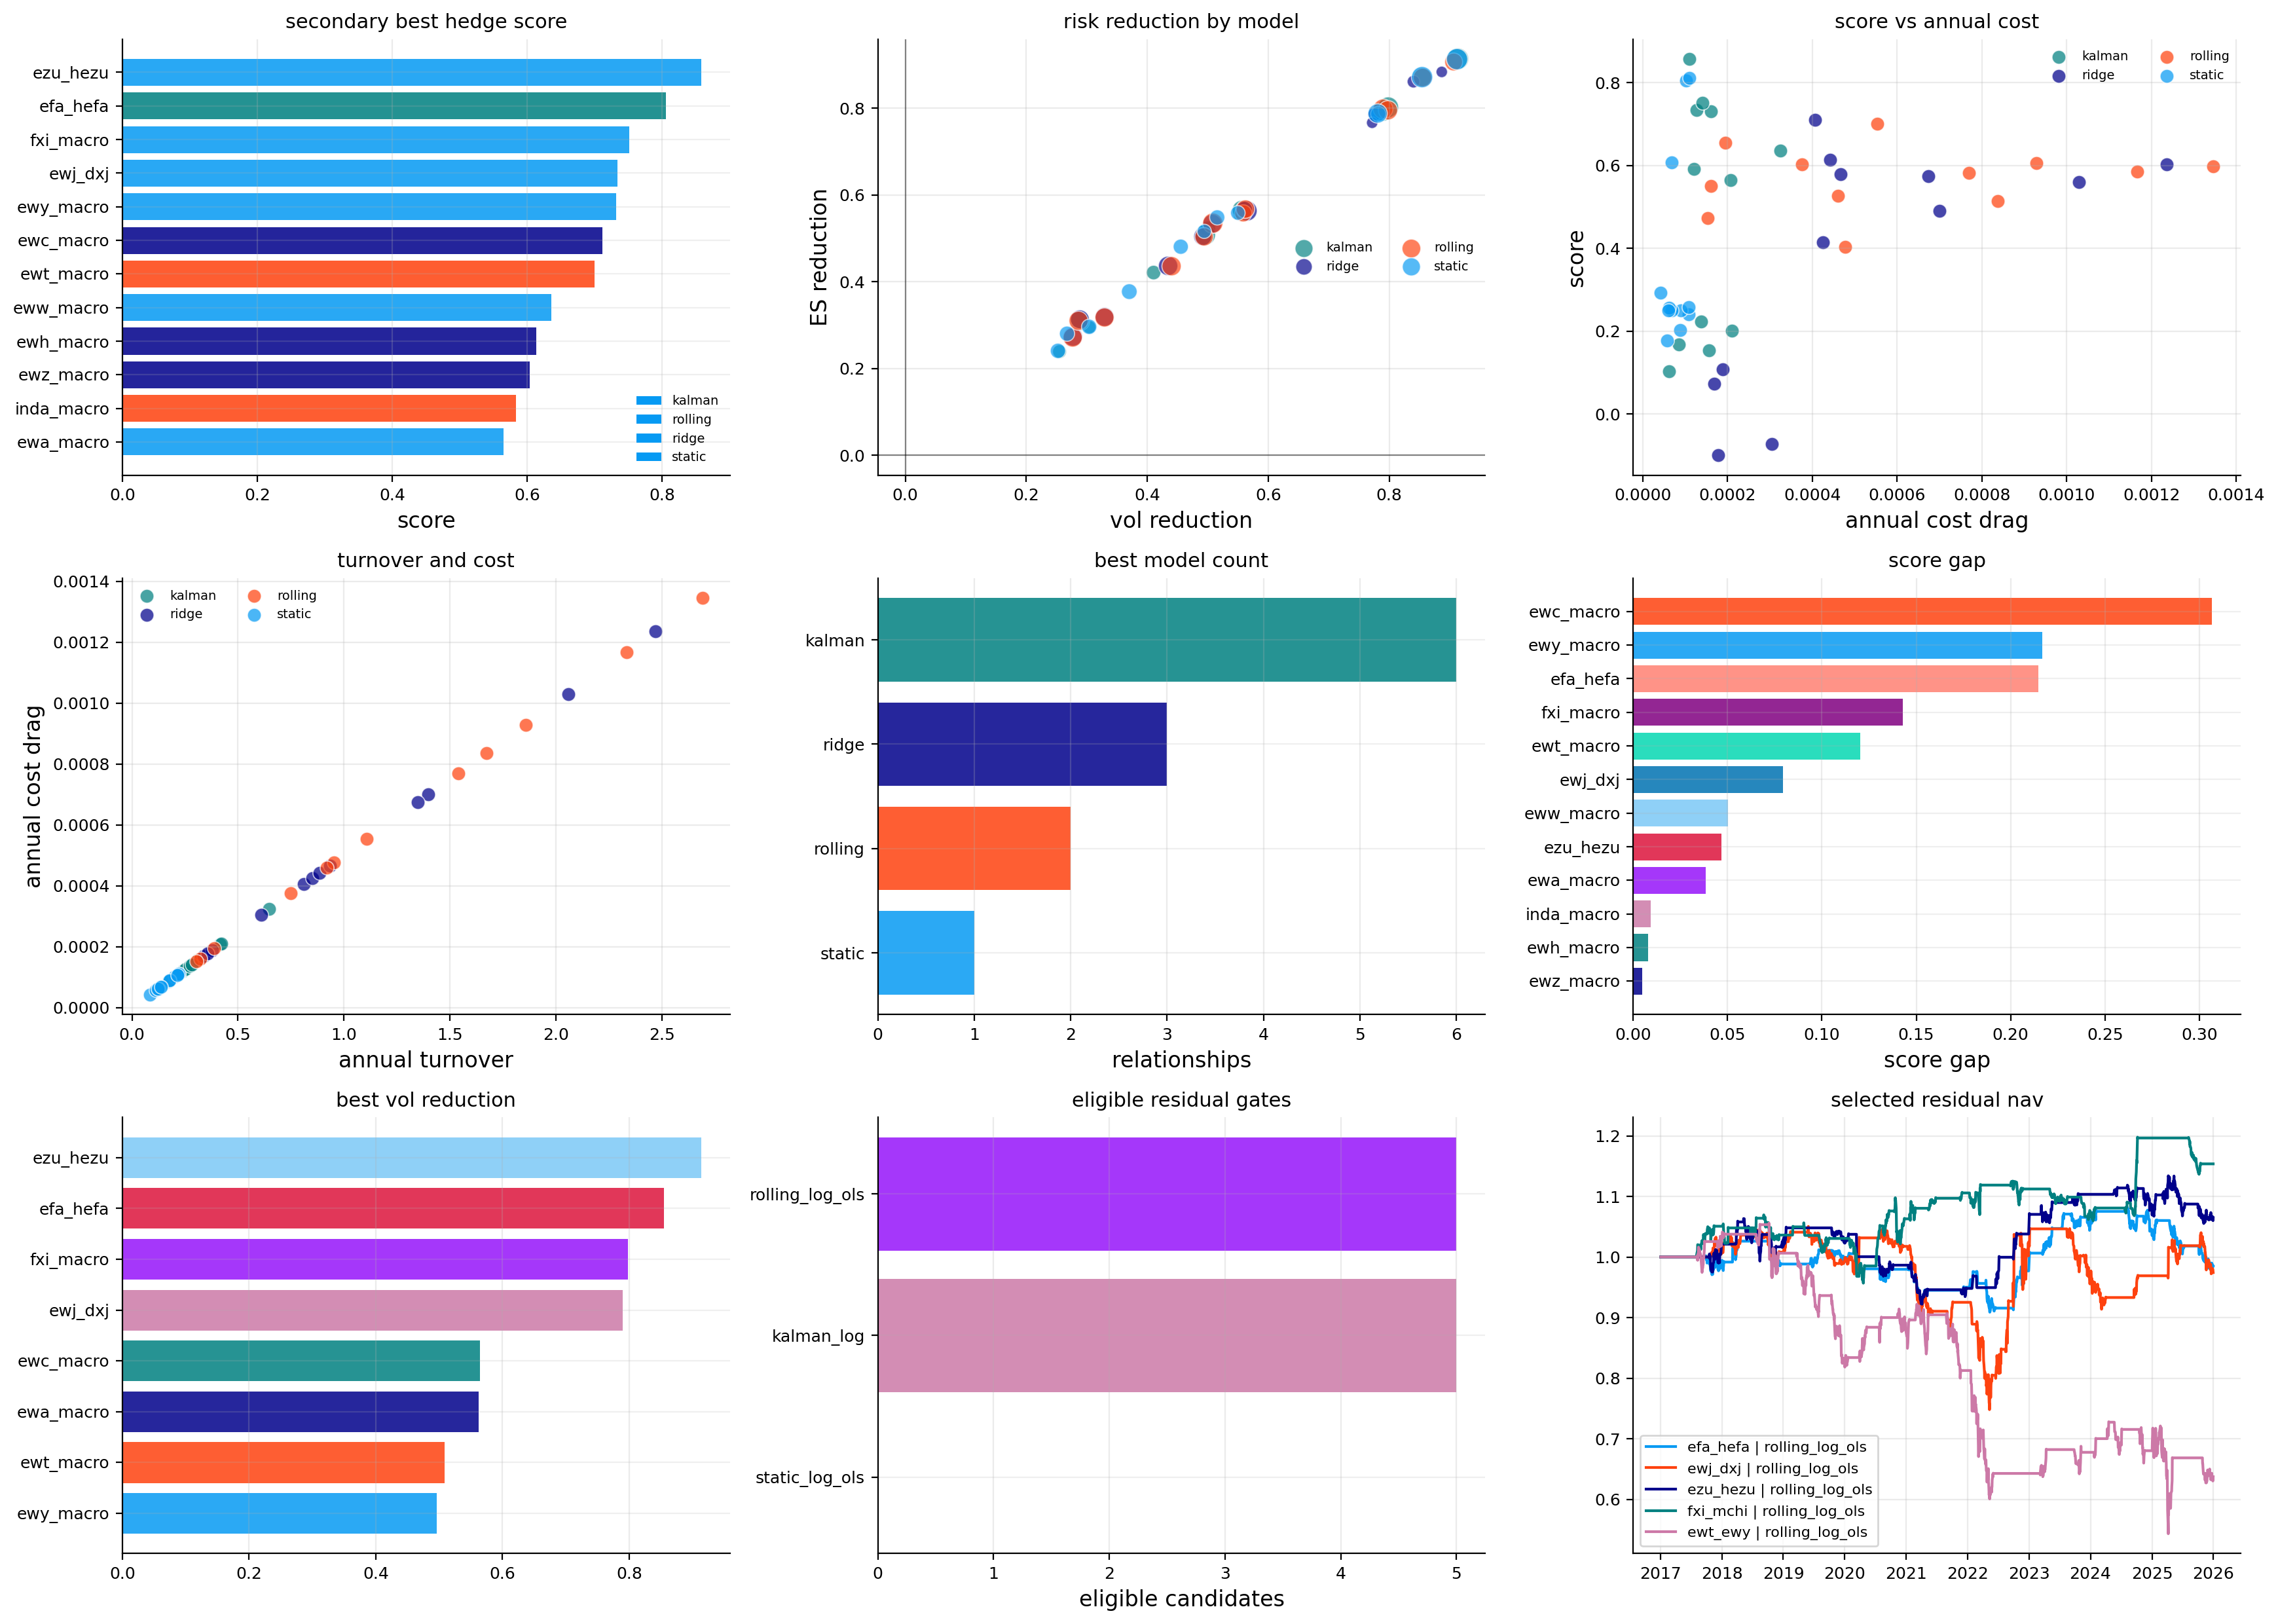

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from IPython.display import display

from quantfinlab.backtest.hedging import run_many_hedge_backtests
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.hedging import (
    band_beta, best_table, coverage_table, diag_table, filter_rels,
    kf_beta, kf_price_beta, model_table, ols_beta, price_ols_beta,
    quality_table, rebalance_beta, rel, rel_table, rel_tickers,
    residual_backtest_grid, residual_trade_table, ridge_beta, robust_table,
    roll_beta, roll_price_beta, score_table)
from quantfinlab.plotting.hedging import (
    plot_best_score_bar, plot_model_counts, plot_quality_bar,
    plot_resid_gate_counts, plot_resid_nav, plot_risk_reduction_scatter,
    plot_score_cost_scatter, plot_score_gap, plot_turnover_cost_scatter)
from quantfinlab.portfolio.universe import prices_to_returns

start = "2015-01-01"
end = "2026-01-01"
ann = 252
n_train = 504
win = 252
alpha = 10.0
freq = "w-fri"
band = 0.05
cost_bps = 5.0
z_win = 126
z_in = 2.0
z_out = 0.5
z_stop = 3.5
z_cool = 5

palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2", "#800080", "#FF8072"]
colors = palette
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7})

etf_path = [Path("../data/international_hedging_etfs.csv"), Path("../data/core_cross_asset_etfs.csv"), Path("../data/sector_etfs.csv")]
nasdaq_path = Path("../data/nasdaq_close_volume.parquet")
etf_px_sec = load_yfinance_panel(etf_path, fields=("close",), start=start, end=end, lowercase=True)["close"]
stock_px_sec = load_yfinance_panel(nasdaq_path, fields=("close",), start=start, end=end, lowercase=True)["close"]

px_sec_all = pd.concat([stock_px_sec, etf_px_sec], axis=1)
px_sec_all = px_sec_all.loc[:, ~px_sec_all.columns.duplicated(keep="last")]
px_sec_all = px_sec_all.loc[(px_sec_all.index >= start) & (px_sec_all.index <= end)].sort_index()
ret_m_all = prices_to_returns(px_sec_all, kind="log")
ret_b_all = prices_to_returns(px_sec_all, kind="simple")

rel_sec = [
    rel("efa_hefa", "efa", ["hefa", "uup"]),
    rel("ewj_dxj", "ewj", ["dxj", "fxy", "spy"]),
    rel("ezu_hezu", "ezu", ["hezu", "fxe", "spy"]),
    rel("ewc_macro", "ewc", ["spy", "xle", "dbc", "fxc"]),
    rel("ewa_macro", "ewa", ["efa", "dbc", "fxa"]),
    rel("ewh_macro", "ewh", ["fxi", "mchi", "vnq", "uup"]),
    rel("ewt_macro", "ewt", ["eem", "smh", "qqq", "uup"]),
    rel("ewy_macro", "ewy", ["eem", "smh", "ewt", "uup"]),
    rel("inda_macro", "inda", ["eem", "qqq", "uup"]),
    rel("ewz_macro", "ewz", ["eem", "dbc", "uup"]),
    rel("eww_macro", "eww", ["spy", "eem", "uup"]),
    rel("fxi_macro", "fxi", ["mchi", "kweb", "ashr", "uup"])]

sec_view = rel_table(rel_sec, px_sec_all.columns)
rel_sec, missing_sec = filter_rels(rel_sec, px_sec_all.columns)
tickers_sec = rel_tickers(rel_sec)
print(f"available secondary tickers: {len(tickers_sec)}")
print("missing secondary tickers:", missing_sec)
display(sec_view)

px_sec = px_sec_all[tickers_sec]
ret_m_sec = ret_m_all[tickers_sec]
ret_b_sec = ret_b_all[tickers_sec]
display(coverage_table(px_sec, rel_sec).round(4))

betas, books_sec, blog_sec = {}, {}, {}
for r in rel_sec:
    betas[(r.name, "static")] = ols_beta(ret_m_sec, r, n_train=n_train)
    betas[(r.name, "rolling")] = roll_beta(ret_m_sec, r, win=win, n_train=n_train)
    betas[(r.name, "ridge")] = ridge_beta(ret_m_sec, r, win=win, alpha=alpha, n_train=n_train)
    betas[(r.name, "kalman")] = kf_beta(ret_m_sec, r, n_train=n_train)
    books_sec[f"{r.name} | target"] = {"target": r.target, "hedges": r.hedges, "beta": None}
    for m in ["static", "rolling", "ridge", "kalman"]:
        b1 = rebalance_beta(betas[(r.name, m)], ret_b_sec.index, freq=freq)
        b2 = b1.ffill() if m == "static" else band_beta(b1, band=band)
        books_sec[f"{r.name} | {m}"] = {"target": r.target, "hedges": r.hedges, "beta": b2}
        blog_sec[f"{r.name} | {m}"] = {"rel": r.name, "model": m, "desired": betas[(r.name, m)], "traded": b2}

bt_sec = run_many_hedge_backtests(books_sec, returns=ret_b_sec[tickers_sec], cost_bps=cost_bps)
tab_diag_sec = diag_table(ret_m_sec, rel_sec, beta_log=blog_sec, ann=ann)
tab_model_sec = model_table(bt_sec, rel_sec, ret_m_sec, ann=ann)
tab_score_sec = score_table(tab_model_sec)
tab_best_sec = best_table(tab_score_sec)
tab_robust_sec = robust_table(tab_score_sec)
tab_quality_sec = quality_table(tab_model_sec)

display(tab_diag_sec.round(4))
display(tab_best_sec.round(4))
display(tab_robust_sec.round(4))
display(tab_quality_sec.round(4))

pairs_sec = [("efa_hefa", "efa", "hefa"), ("ewj_dxj", "ewj", "dxj"), ("ezu_hezu", "ezu", "hezu"),
             ("fxi_mchi", "fxi", "mchi"), ("ewt_ewy", "ewt", "ewy")]
pairs_sec = [p for p in pairs_sec if p[1] in px_sec_all.columns and p[2] in px_sec_all.columns]
source_fns_sec = {
    "static_log_ols": lambda t, h: price_ols_beta(px_sec_all, t, h, n_train=n_train),
    "rolling_log_ols": lambda t, h: roll_price_beta(px_sec_all, t, h, win=win, n_train=n_train),
    "kalman_log": lambda t, h: kf_price_beta(px_sec_all, t, h, n_train=n_train)}

tab_gate_sec, resid_sec, z_sec, meta_sec = residual_backtest_grid(
    px_sec_all, ret_b_all, pairs_sec, source_fns_sec, ann=ann, cost_bps=cost_bps,
    z_win=z_win, z_in=z_in, z_out=z_out, z_stop=z_stop, z_cool=z_cool)

gate_cols = ["pair", "beta_source", "eg_p", "adf_p", "half_life", "spread_vol", "trades", "cost_drag_ann", "beta_turnover", "eligible"]
display(tab_gate_sec[gate_cols].round(4))

tab_resid_sec = residual_trade_table(resid_sec, z_sec, meta_sec, ann=ann)
pick_sec = tab_gate_sec[tab_gate_sec["eligible"] & ~tab_gate_sec["beta_source"].eq("kalman_log")]
rolling_sec = pick_sec.loc[pick_sec["beta_source"].eq("rolling_log_ols"), "key"].tolist()
keep_sec = rolling_sec or pick_sec["key"].tolist()
if not keep_sec and not tab_resid_sec.empty:
    keep_sec = tab_resid_sec[~tab_resid_sec["beta_source"].eq("kalman_log")].sort_values("trades", ascending=False)["key"].head(5).tolist()
show_resid_sec = tab_resid_sec[tab_resid_sec["key"].isin(keep_sec)].copy()
display(show_resid_sec.drop(columns="key").round(4))

fig, axes = plt.subplots(3, 3, figsize=(17.5, 12.5))
axes = axes.ravel()
plot_best_score_bar(tab_best_sec, ax=axes[0], title="secondary best hedge score", colors=colors)
plot_risk_reduction_scatter(tab_score_sec, ax=axes[1], title="risk reduction by model", colors=colors)
plot_score_cost_scatter(tab_score_sec, ax=axes[2], title="score vs annual cost", colors=colors)
plot_turnover_cost_scatter(tab_score_sec, ax=axes[3], title="turnover and cost", colors=colors)
plot_model_counts(tab_best_sec, ax=axes[4], title="best model count", colors=colors)
plot_score_gap(tab_score_sec, ax=axes[5], title="score gap", colors=colors)
plot_quality_bar(tab_quality_sec, ax=axes[6], title="best vol reduction", colors=colors)
plot_resid_gate_counts(tab_gate_sec, ax=axes[7], title="eligible residual gates", colors=colors)
plot_resid_nav(resid_sec, keep_sec[:5], ax=axes[8], title="selected residual nav")
plt.tight_layout()
plt.show()


All secondary tickers are available. The coverage table again shows **2766 observations** from 2015 to the end of 2025 with no missing values. This makes the transfer test clean: the same hedge methodology is applied to a new economic universe without fighting data gaps.

The diagnostic table is very informative:

- **EZU/HEZU** has correlation around **0.952** and $R^2$ around **0.907**. The hedged eurozone ETF explains most of the unhedged eurozone ETF after adding FXE and SPY. This is exactly what we would expect from a currency-hedged/unhedged structure.
- **EWJ/DXJ** has correlation around **0.925** and $R^2$ around **0.856**. Japan is also very hedgeable because DXJ and FXY directly capture the equity and yen components.
- **FXI macro** has correlation around **0.937** and $R^2$ around **0.878**, because MCHI, KWEB, and ASHR are very close China-related proxies.
- **EWZ macro** has much lower $R^2$, around **0.416**, and very high target volatility around **35.4%**. Brazil is hard to hedge because it combines EM beta, commodity sensitivity, local political risk, currency shocks, and global dollar pressure.
- **EWW** and **INDA** also have lower explanatory power. Mexico and India can't be fully replicated by broad EM, US beta, and dollar exposure.

So before any backtest, the diagnostics already tell us which country ETFs are structurally hedgeable and which ones have more local residual risk.

### 14.5 Currency-hedged ETFs as natural controls

The cleanest international hedge relationships use currency-hedged ETFs as controls. HEFA, HEZU, and DXJ aren't generic hedge assets. They are designed to hold similar local equity exposure while reducing foreign-exchange exposure.

A simplified unhedged USD return can be written as:

$$
r^{USD}_{country} \approx r^{local}_{equity} + r^{FX}
$$

A currency-hedged version tries to isolate:

$$
r^{hedged}_{country} \approx r^{local}_{equity}
$$

So the difference between unhedged and hedged ETF returns is strongly connected to currency movement:

$$
r^{USD}_{country} - r^{hedged}_{country} \approx r^{FX}
$$

That's why EFA/HEFA and EZU/HEZU have such high hedge quality. The hedge basket is economically matched to the target. We aren't asking a random ETF to explain country returns. We're using an instrument built to remove exactly one major component of the target's return: currency translation.

### 14.2 International hedge model results

The international best-model table is stronger than the main single-stock table in several places, and the strongest results are economically easy to understand.

**EZU/HEZU** is the standout. Kalman is selected, with about **91.3% volatility reduction** and **91.4% ES reduction**. This is an extremely high hedge-quality result. The reason is that unhedged eurozone equity can be decomposed into hedged eurozone equity, euro exposure, and global equity risk. Once HEZU, FXE, and SPY are in the hedge basket, little unexplained broad risk remains.

**EFA/HEFA** is also very strong, with static selected and about **85.4% volatility reduction** and **87.2% ES reduction**. Static working here is meaningful. It means the relationship between unhedged developed ex-US equity, currency-hedged developed ex-US equity, and dollar exposure is stable enough that a fixed beta already performs well.

**EWJ/DXJ** reaches about **79.0% volatility reduction** with Kalman selected. Japan has a clean currency-hedged/unhedged structure, and the yen ETF helps absorb the currency component. The Kalman selection suggests the currency and equity-beta relationship isn't constant through time, which makes sense because yen behavior changes across risk-off, low-rate, and policy-divergence regimes.

**FXI macro** is also strong, with Kalman selected and around **79.8% volatility reduction**. This isn't a simple currency hedge. It's a China exposure decomposition. MCHI, KWEB, ASHR, and UUP together explain a large amount of FXI's movement because they capture broad China, internet/ADR-heavy China exposure, A-share exposure, and dollar pressure.

The weaker relationships are economically interesting:

- **EWZ Brazil** has only about **27.7% volatility reduction**, even with ridge selected.
- **EWW Mexico** has about **28.9% volatility reduction**, with Kalman selected.
- **INDA India** is around **32.9%**, with rolling selected.

These markets contain local risk that broad proxies don't fully capture. Brazil has commodity exposure, EM beta, currency pressure, local politics, and fiscal risk all mixed together. Mexico has strong US linkage but also local policy and currency behavior. India often has strong domestic growth and flow dynamics that don't map cleanly to EEM, QQQ, and UUP.

So the weaker scores aren't failures only. They tell us the residual is economically real. A hedge basket can explain global factors, but it can't fully erase local market identity.

The robust table shows a different ranking from the main universe. Rolling has the highest median score, around **0.584**, and Kalman is extremely close at **0.578**. Kalman wins the most relationships, with **6 wins**, while rolling wins 2 and ridge wins 3.

This is an important transfer result. In the main universe, ridge had the highest median score. In the international universe, Kalman becomes more competitive because country exposures and currency components evolve through time. Exchange-rate regimes, commodity cycles, and regional equity betas don't stay fixed.

The quality table gives the clean economic hierarchy:

- **currency-hedged/unhedged relationships** are highly hedgeable: EZU/HEZU, EFA/HEFA, EWJ/DXJ,
- **close China proxy relationships** are highly hedgeable: FXI macro,
- **commodity-linked developed markets** are moderately hedgeable: Canada and Australia,
- **emerging markets with local/political/currency residuals** are harder: Brazil, Mexico, India.

This is exactly why the secondary analysis is valuable. The same dynamic hedge machinery becomes a tool for understanding global ETF structure.

### 14.6 Country residuals as economic signals

The lower-quality international hedges aren't failures in a simple sense. They tell us that some country ETFs contain local residual risk that can't be explained by broad proxies.

Brazil is a good example. EWZ is linked to EM beta, commodities, rates, the dollar, local politics, fiscal risk, and the Brazilian real. DBC and UUP help, but they don't fully capture Petrobras, Vale, local policy, and idiosyncratic country cycles. A low hedge score here is economically believable.

Mexico is also distinct. EWW has US supply-chain and nearshoring exposure, but it also has local currency, rates, financials, and political risk. SPY, EEM, and UUP explain part of it but leave meaningful residual structure.

India is another special case. INDA has EM and growth exposure, but India's domestic earnings cycle, policy environment, and foreign-flow dynamics often behave differently from broad EM. So a moderate hedge result is more realistic than an artificially high one.

This is the type of interpretation we want from dynamic hedging. It doesn't only say which model scored best. It tells us which markets are structurally replicable and which markets carry true local risk.

### 14.3 International residual gates

The international residual gate tests five close economic pairs:

$$
\text{EFA/HEFA},\quad \text{EWJ/DXJ},\quad \text{EZU/HEZU},\quad \text{FXI/MCHI},\quad \text{EWT/EWY}
$$

These aren't random pairs. They are chosen because each has a plausible equilibrium relation:

- EFA and HEFA are unhedged and currency-hedged versions of developed ex-US equity.
- EWJ and DXJ are unhedged and currency-hedged Japan equity structures.
- EZU and HEZU are unhedged and currency-hedged eurozone equity structures.
- FXI and MCHI are close China equity proxies with different index composition.
- EWT and EWY represent Taiwan and Korea, two semiconductor-heavy Asian equity markets.

Static log-OLS fails for all of them. That means a fixed price spread isn't stationary enough over the full sample. This is common for international ETFs because currencies, country leadership, and regional growth stories can drift for years.

Rolling log-OLS and Kalman log versions pass the stationarity-style gates in several cases. For example:

- EFA/HEFA rolling has ADF p-value around **0.0028** and half-life around **54.5 days**,
- EWJ/DXJ rolling has ADF p-value around **0.0025** and half-life around **44.3 days**,
- EZU/HEZU rolling has ADF p-value around **0.0022** and half-life around **52.5 days**,
- FXI/MCHI rolling has ADF p-value around **0.0001** and half-life around **30.3 days**,
- EWT/EWY rolling has ADF p-value around **0.0010** and half-life around **46.6 days**.

These half-lives are plausible for swing-style residual trades. But passing the gate still doesn't guarantee a profitable strategy. The test says the spread has mean-reverting structure in the sample. It doesn't say the entry/exit levels, costs, and structural breaks are favorable enough to make money.

### 14.4 International residual trading and final plot

The selected international residual strategies are mixed, and that's exactly the right result for this kind of section. If every statistically eligible spread made money, the gate would be too loose or the backtest would be suspicious.

**FXI/MCHI rolling log-OLS** is the best secondary residual trade. It has about **15.4% net return**, annualized volatility around **4.7%**, Sharpe around **0.36**, and max drawdown around **-10.5%**. The economic story is reasonable. FXI and MCHI are both China equity exposures, but they differ in holdings, offshore/onshore composition, index construction, and sensitivity to internet/platform names. Those differences can create temporary deviations without becoming totally unrelated assets.

**EZU/HEZU** is modestly positive, with net return around **6.5%** and Sharpe around **0.17**. The result fits the logic: eurozone unhedged versus hedged exposure plus euro movement can create mean-reverting residuals, but the edge isn't large after costs.

**EFA/HEFA** and **EWJ/DXJ** are roughly flat to slightly negative. These are excellent hedging relationships, but that doesn't make them strong trading relationships. This distinction is one of the most useful lessons in the project. A pair can be stable enough to hedge and still too efficient, too cost-sensitive, or too slowly mean-reverting to trade profitably.

**EWT/EWY** is the clear failure, with net return around **-36.3%**, Sharpe around **-0.38**, and max drawdown near **-48.6%**. Taiwan and Korea share semiconductor and EM exposure, but their residual spread can trend when one market structurally outperforms the other. In the recent AI and semiconductor cycle, Taiwan-related exposure could dominate Korea for reasons a simple mean-reversion rule doesn't capture.

The final 3-by-3 plot summarizes the transfer clearly:

- high hedge scores appear in currency-hedged and close-proxy relationships,
- the risk-reduction scatter confirms that most international hedges reduce volatility and ES substantially,
- the residual NAV panel shows that residual trading is much more selective than hedging,
- FXI/MCHI works reasonably, EZU/HEZU is mild, and EWT/EWY is a warning that statistical eligibility isn't enough when the economic spread can trend.